# Towards a GIS system

In [ ]:
#| default_exp chunked

In [ ]:
#| export
import numpy as np
import sys
import os
import math
from math import radians, cos, sin, sqrt, atan2
import random

#data
from collections import namedtuple
from dataclasses import dataclass,  field, asdict
import json
from typing import List , Optional
from enum import Enum



In [ ]:
#| export
from dataclasses import dataclass
from typing import Optional

from datetime import datetime


In [ ]:
#| export
from fastcore.utils import *
from fasthtml.common import *
from fasthtml.jupyter import *
from fastlite import *
import fasthtml.components as fc
import httpx


In [ ]:
#| export
from importlib import resources
from pathlib import Path
import tempfile
import shutil
import sqlite3
from dataclasses import dataclass
from typing import Iterator
import numpy as np

In [ ]:
from HexMagic.geology import Plate

In [ ]:
#| export
from HexMagic.climate import TerrainPatterns, DrainageBasins, Geology, TerraDemo, Terrain, GeoBounds, ClimatePreset, TerrainFactory
from HexMagic.primitives import MapCord, MapSize, MapRect, MapPath, Hex, HexGrid, HexWrapper, HexPosition, hexBackground, HexRegion, unique_windy_edge
from HexMagic.styles import StyleCSS, SVGBuilder

In [ ]:
#| export
from HexMagic.geology import River, Watershed
from HexMagic.water.river import find_local_minima
# Set up a proper ChunkedTerrainGenerator test
from HexMagic.database import GeoStorageDebugger, ChunkRef
from HexMagic.primitives import HexPosition,  HexChunk, render_chunk



In [ ]:
#| export
from HexMagic.database import LoadResult, SaveResult, HexWeather, WatershedMeta, TerrainWorld, User, GeoStorage, HexData

In [ ]:
#| export
from HexMagic.database import world_to_chunk

In [ ]:
#| export
from HexMagic.voronoi import TerrainGenerator

In [ ]:
#| export
class ChunkedTerrainGenerator:
    """Generate and manage large terrains via chunking with plate tracking."""
    
    def __init__(self, storage: 'GeoStorage', 
                 coarse_rings: int = 20,
                 coarse_radius: float = 50,
                 fine_radius: float = 10,
                 chunk_rings: int = 10,
                 halo_rings: int = 3):
        """
        Args:
            storage: GeoStorage for persistence
            coarse_rings: Rings in coarse overview map
            coarse_radius: Hex radius for coarse hexes
            fine_radius: Hex radius for detailed chunks
            chunk_rings: Rings of hexes per chunk (before halo)
            halo_rings: Extra rings for edge computation
        """
        self.storage = storage
        self.coarse_rings = coarse_rings
        self.coarse_radius = coarse_radius
        self.fine_radius = fine_radius
        self.chunk_rings = chunk_rings
        self.halo_rings = halo_rings
        
        self.coarse_world_id = None
        self.chunk_world_ids = {}  # ChunkRef.key -> world_id
        self._plates = None
        self._coarse_terrain = None
    
    @property
    def scale(self) -> float:
        """Resolution scale factor between coarse and fine."""
        return self.coarse_radius / self.fine_radius


In [ ]:
#| export
@patch
def generate_coarse(self: ChunkedTerrainGenerator, 
                    num_plates: int = 15,
                    ocean_fraction: float = 0.4,
                    oceanic_sides: list = None,
                    name: str = "world_coarse",
                    **kwargs) -> Terrain:
    """Generate coarse map using TerrainGenerator."""
    
    gen = TerrainGenerator(
        hexDim=self.coarse_rings,
        radius=self.coarse_radius,
        num_plates=num_plates,
        ocean_fraction=ocean_fraction,
        oceanic_sides=oceanic_sides or [],
        subdivisions=2,
        **kwargs
    )
    
    terrain, plates = gen.generate()
    self._plates = plates
    self._coarse_terrain = terrain
    
    # save_world handles plate_id field
    result = self.storage.save_world(terrain, name=name)
    self.coarse_world_id = result.id
    
    return terrain


In [ ]:
#| export
@patch
def generate_chunk(self: ChunkedTerrainGenerator, chunk: ChunkRef) -> Terrain:
    """Generate chunk by sampling from coarse with plate inheritance."""
    
    # Query plate_ids for this chunk's region from DB
    chunk_plates = self._query_chunk_plates(chunk)
    
    # Create fine grid
    total_rings = self.chunk_rings + self.halo_rings
    fine_grid = HexGrid.centered(
        rings=total_rings, 
        radius=self.fine_radius,
        style=self._coarse_terrain.seaLevel
    )
    
    # Build terrain from coarse data
    terrain = self._build_chunk_terrain(fine_grid, chunk, chunk_plates)
    
    return terrain


In [ ]:
#| export
@patch
def _query_chunk_plates(self: ChunkedTerrainGenerator, chunk: ChunkRef) -> dict:
    """Query DB for plate membership in chunk region."""
    center = chunk.center_hex
    radius = int((self.chunk_rings + self.halo_rings) / self.scale) + 2
    
    # Scale to coarse coords
    coarse_q = int(center.q / self.scale)
    coarse_r = int(center.r / self.scale)
    coarse_s = -coarse_q - coarse_r
    
    rows = self.storage.query_hexes_in_radius(
        self.coarse_world_id,
        coarse_q, coarse_r, coarse_s,
        radius
    )
    
    # Group by plate_id
    plates = {}
    for row in rows:
        pid = row.get('plate_id', 0)
        if pid not in plates:
            plates[pid] = []
        plates[pid].append(row)
    
    return plates


#| export
@patch
def _build_chunk_terrain(self: ChunkedTerrainGenerator, 
                          fine_grid: HexGrid, 
                          chunk: ChunkRef,
                          chunk_plates: dict) -> Terrain:
    """Build fine terrain from coarse data with plate inheritance."""
    coarse = self._coarse_terrain
    
    # Build terrain object
    terrain = Terrain.__new__(Terrain)
    terrain.hexGrid = fine_grid
    terrain.elevations = np.zeros(len(fine_grid.hexes))
    terrain.fields = {'plate_id': np.zeros(len(fine_grid.hexes))}
    terrain.seaLevel = coarse.seaLevel
    terrain.elevationDelta = coarse.elevationDelta
    terrain.colorLevels = coarse.colorLevels
    terrain.climate = coarse.climate
    terrain.geo = coarse.geo
    terrain.path = ""
    
    # Add styles to builder
    fine_grid.builder.add_style(terrain.seaLevel)
    for color in terrain.colorLevels:
        fine_grid.builder.add_style(color)
    
    # Build coarse lookup: (q,r,s) -> {elevation, plate_id, ...}
    coarse_lookup = {}
    for pid, rows in chunk_plates.items():
        for row in rows:
            key = (row['q'], row['r'], row['s'])
            coarse_lookup[key] = {
                'elevation': row['elevation'],
                'plate_id': pid,
                'distance_from_coast': row.get('distance_from_coast')
            }
    
    # Sample each fine hex from coarse
    for fine_idx in range(len(fine_grid.hexes)):
        fine_pos = fine_grid.index_to_hexposition(fine_idx, origin_index=fine_grid.midpoint)
        world_pos = chunk.center_hex + fine_pos
        
        # Map to coarse coordinates
        coarse_q = int(round(world_pos.q / self.scale))
        coarse_r = int(round(world_pos.r / self.scale))
        coarse_s = -coarse_q - coarse_r
        
        coarse_key = (coarse_q, coarse_r, coarse_s)
        
        if coarse_key in coarse_lookup:
            data = coarse_lookup[coarse_key]
            terrain.elevations[fine_idx] = data['elevation']
            terrain.fields['plate_id'][fine_idx] = data['plate_id']
        else:
            elevation, plate_id = self._interpolate_from_coarse(
                coarse_q, coarse_r, coarse_s, coarse_lookup
            )
            terrain.elevations[fine_idx] = elevation
            terrain.fields['plate_id'][fine_idx] = plate_id
    
    # Add deterministic detail noise
    self._add_detail(terrain, chunk)
    
    # Copy additional fields from coarse
    self._interpolate_fields(terrain, chunk, coarse)
    
    return terrain


In [ ]:
@patch
def _build_chunk_terrain(self: ChunkedTerrainGenerator, 
                          fine_grid: HexGrid, 
                          chunk: ChunkRef,
                          chunk_plates: dict) -> Terrain:
    """Build fine terrain with smooth interpolation from coarse."""
    coarse = self._coarse_terrain
    
    # ... (terrain setup code unchanged) ...
    
    # Build coarse lookup
    coarse_lookup = {}
    for pid, rows in chunk_plates.items():
        for row in rows:
            key = (row['q'], row['r'], row['s'])
            coarse_lookup[key] = {
                'elevation': row['elevation'],
                'plate_id': pid,
            }
    
    # Sample each fine hex with interpolation
    for fine_idx in range(len(fine_grid.hexes)):
        fine_pos = fine_grid.index_to_hexposition(fine_idx, origin_index=fine_grid.midpoint)
        world_pos = chunk.center_hex + fine_pos
        
        # Interpolated values (smooth!)
        elevation, plate_id = self._interpolate_elevation(world_pos, coarse_lookup)
        
        terrain.elevations[fine_idx] = elevation
        terrain.fields['plate_id'][fine_idx] = plate_id
    
    # Detail noise on top of smooth base
    self._add_detail(terrain, chunk)
    
    return terrain


In [ ]:
#| export
@patch
def create_region_index_mapper(self: GeoStorage, world_id: int,
                                center_q: int, center_r: int, center_s: int,
                                extracted_grid: HexGrid) -> callable:
    """Create mapper from extracted region index to original world grid_index."""
    hex_rows = list(self.hexes.rows_where('world_id = ?', [world_id]))
    coord_to_idx = {
        (GeoStorage._get(r, 'q'), GeoStorage._get(r, 'r'), GeoStorage._get(r, 's')): 
        GeoStorage._get(r, 'grid_index')
        for r in hex_rows
    }
    
    def mapper(new_idx: int) -> int:
        rel_pos = extracted_grid.index_to_hexposition(new_idx, origin_index=extracted_grid.midpoint)  # FIXED
        world_coords = (center_q + rel_pos.q, center_r + rel_pos.r, center_s + rel_pos.s)
        return coord_to_idx.get(world_coords, -1)
    
    return mapper


In [ ]:
#| export
@patch
def _build_chunk_terrain(self: ChunkedTerrainGenerator, 
                          fine_grid: HexGrid, 
                          chunk: ChunkRef,
                          chunk_plates: dict) -> Terrain:
    """Build fine terrain from coarse data with plate inheritance."""
    coarse = self._coarse_terrain
    
    # Build terrain object
    terrain = Terrain.__new__(Terrain)
    terrain.hexGrid = fine_grid
    terrain.elevations = np.zeros(len(fine_grid.hexes))
    terrain.fields = {'plate_id': np.zeros(len(fine_grid.hexes))}
    terrain.seaLevel = coarse.seaLevel
    terrain.elevationDelta = coarse.elevationDelta
    terrain.colorLevels = coarse.colorLevels
    terrain.climate = coarse.climate
    terrain.geo = coarse.geo
    terrain.path = ""
    
    # Add styles to builder
    fine_grid.builder.add_style(terrain.seaLevel)
    for color in terrain.colorLevels:
        fine_grid.builder.add_style(color)
    
    # Build coarse lookup: (q,r,s) -> {elevation, plate_id, ...}
    coarse_lookup = {}
    for pid, rows in chunk_plates.items():
        for row in rows:
            key = (row['q'], row['r'], row['s'])
            coarse_lookup[key] = {
                'elevation': row['elevation'],
                'plate_id': pid,
                'distance_from_coast': row.get('distance_from_coast')
            }
    
    # Sample each fine hex from coarse
    for fine_idx in range(len(fine_grid.hexes)):
        fine_pos = fine_grid.index_to_hexposition(fine_idx, origin_index=fine_grid.midpoint)
        world_pos = chunk.center_hex + fine_pos
        
        # Map to coarse coordinates
        coarse_q = int(round(world_pos.q / self.scale))
        coarse_r = int(round(world_pos.r / self.scale))
        coarse_s = -coarse_q - coarse_r
        
        coarse_key = (coarse_q, coarse_r, coarse_s)
        
        if coarse_key in coarse_lookup:
            data = coarse_lookup[coarse_key]
            terrain.elevations[fine_idx] = data['elevation']
            terrain.fields['plate_id'][fine_idx] = data['plate_id']
        else:
            elevation, plate_id = self._interpolate_from_coarse(
                coarse_q, coarse_r, coarse_s, coarse_lookup
            )
            terrain.elevations[fine_idx] = elevation
            terrain.fields['plate_id'][fine_idx] = plate_id
    
    # Add deterministic detail noise
    self._add_detail(terrain, chunk)
    
    # Copy additional fields from coarse
    self._interpolate_fields(terrain, chunk, coarse)
    
    return terrain


In [ ]:
#| export
@patch
def _build_chunk_terrain(self: ChunkedTerrainGenerator, 
                          fine_grid: HexGrid, 
                          chunk: ChunkRef,
                          chunk_plates: dict) -> Terrain:
    """Build fine terrain from coarse data with plate inheritance."""
    coarse = self._coarse_terrain
    
    # Build terrain object
    terrain = Terrain.__new__(Terrain)
    terrain.hexGrid = fine_grid
    terrain.elevations = np.zeros(len(fine_grid.hexes))
    terrain.fields = {'plate_id': np.full(len(fine_grid.hexes), -1, dtype=np.int32)}  # ← FIXED
    terrain.seaLevel = coarse.seaLevel
    terrain.elevationDelta = coarse.elevationDelta
    terrain.colorLevels = coarse.colorLevels
    terrain.climate = coarse.climate
    terrain.geo = coarse.geo
    terrain.path = ""
    
    # Add styles to builder
    fine_grid.builder.add_style(terrain.seaLevel)
    for color in terrain.colorLevels:
        fine_grid.builder.add_style(color)
    
    # Build coarse lookup: (q,r,s) -> {elevation, plate_id, ...}
    coarse_lookup = {}
    for pid, rows in chunk_plates.items():
        for row in rows:
            key = (row['q'], row['r'], row['s'])
            coarse_lookup[key] = {
                'elevation': row['elevation'],
                'plate_id': pid,
                'distance_from_coast': row.get('distance_from_coast')
            }
    
    # Sample each fine hex from coarse
    for fine_idx in range(len(fine_grid.hexes)):
        fine_pos = fine_grid.index_to_hexposition(fine_idx, origin_index=fine_grid.midpoint)
        world_pos = chunk.center_hex + fine_pos
        
        # Map to coarse coordinates
        coarse_q = int(round(world_pos.q / self.scale))
        coarse_r = int(round(world_pos.r / self.scale))
        coarse_s = -coarse_q - coarse_r
        
        coarse_key = (coarse_q, coarse_r, coarse_s)
        
        if coarse_key in coarse_lookup:
            data = coarse_lookup[coarse_key]
            terrain.elevations[fine_idx] = data['elevation']
            terrain.fields['plate_id'][fine_idx] = int(data['plate_id'])
        else:
            elevation, plate_id = self._interpolate_from_coarse(
                coarse_q, coarse_r, coarse_s, coarse_lookup
            )
            terrain.elevations[fine_idx] = elevation
            terrain.fields['plate_id'][fine_idx] = int(plate_id)
    
    # Add deterministic detail noise
    self._add_detail(terrain, chunk)
    
    # Copy additional fields from coarse
    self._interpolate_fields(terrain, chunk, coarse)
    
    return terrain


In [ ]:
#| export
@patch
def _interpolate_from_coarse(self: ChunkedTerrainGenerator,
                              q: int, r: int, s: int,
                              coarse_lookup: dict) -> tuple[float, int]:
    """Interpolate elevation and plate_id from nearby coarse hexes."""
    center = HexPosition(q, r, s)
    neighbors = center.ring(1)
    
    elevations = []
    plate_counts = {}
    
    for npos in neighbors:
        key = (npos.q, npos.r, npos.s)
        if key in coarse_lookup:
            data = coarse_lookup[key]
            elevations.append(data['elevation'])
            pid = data['plate_id']
            plate_counts[pid] = plate_counts.get(pid, 0) + 1
    
    if elevations:
        avg_elev = sum(elevations) / len(elevations)
        best_plate = max(plate_counts, key=plate_counts.get)
        return avg_elev, best_plate
    else:
        return -100.0, 0


In [ ]:
#| export
@patch
def _interpolate_fields(self: ChunkedTerrainGenerator, 
                         terrain: Terrain, 
                         chunk: ChunkRef,
                         coarse: Terrain):
    """Copy/interpolate additional fields from coarse terrain."""
    fields_to_copy = ['distance_to_ocean', 'latitude', 'longitude']
    fine_grid = terrain.hexGrid
    coarse_grid = coarse.hexGrid
    if 'plate_id' not in terrain.fields:
        terrain.fields['plate_id'] =  np.full(len(fine_grid.hexes), -1, dtype=np.int32)

    
    for field_name in fields_to_copy:
        if field_name not in coarse.fields:
            continue
        
        terrain.fields[field_name] = np.zeros(len(fine_grid.hexes))
        
        for fine_idx in range(len(fine_grid.hexes)):
            fine_pos = fine_grid.index_to_hexposition(fine_idx, origin_index=fine_grid.midpoint)
            world_pos = chunk.center_hex + fine_pos
            
            coarse_q = int(round(world_pos.q / self.scale))
            coarse_r = int(round(world_pos.r / self.scale))
            coarse_s = -coarse_q - coarse_r
            
            coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
            coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
            
            if 0 <= coarse_idx < len(coarse.fields[field_name]):
                terrain.fields[field_name][fine_idx] = coarse.fields[field_name][coarse_idx]


In [ ]:
@patch
def _interpolate_elevation(self: ChunkedTerrainGenerator, 
                           world_pos: HexPosition, 
                           coarse_lookup: dict) -> tuple[float, int]:
    """Interpolate elevation using distance-weighted average of nearby coarse hexes.

Hex cube coordinates naturally support distance-weighted interpolation. Here's the approach:

    The Math: Fractional Coarse Coordinates

The key insight is that a fine hex's world position maps to a fractional coarse position, not just a rounded integer:
Copied!

frac_q = world_pos.q / scale  # e.g., 7/5 = 1.4
frac_r = world_pos.r / scale  # e.g., -3/5 = -0.6
frac_s = -frac_q - frac_r     # cube constraint still holds

The fractional position tells us "how far between coarse hexes" we are.
    """
    scale = self.scale
    
    # Fractional coarse coordinates
    frac_q = world_pos.q / scale
    frac_r = world_pos.r / scale
    frac_s = -frac_q - frac_r
    
    # Nearest coarse hex center
    near_q = int(round(frac_q))
    near_r = int(round(frac_r))
    near_s = -near_q - near_r
    center = HexPosition(near_q, near_r, near_s)
    
    # Sample center + ring-1 neighbors (7 hexes)
    candidates = [center] + list(center.ring(1))
    
    weights = []
    elevations = []
    plate_weights = {}  # plate_id -> cumulative weight
    
    for cpos in candidates:
        key = (cpos.q, cpos.r, cpos.s)
        if key not in coarse_lookup:
            continue
        
        # Cube distance from fractional position to this coarse center
        dq = cpos.q - frac_q
        dr = cpos.r - frac_r
        ds = cpos.s - frac_s
        dist = (abs(dq) + abs(dr) + abs(ds)) / 2  # hex distance formula
        
        # Inverse distance weight (epsilon prevents div/0 at exact center)
        w = 1.0 / (dist + 0.1)
        weights.append(w)
        elevations.append(coarse_lookup[key]['elevation'])
        
        # Accumulate plate weights for voting
        pid = coarse_lookup[key]['plate_id']
        plate_weights[pid] = plate_weights.get(pid, 0) + w
    
    if not weights:
        return 0.0, -1
    
    # Weighted average for elevation (continuous)
    total_weight = sum(weights)
    interp_elev = sum(w * e for w, e in zip(weights, elevations)) / total_weight
    
    # Weighted voting for plate_id (discrete)
    best_plate = max(plate_weights, key=plate_weights.get)
    
    return interp_elev, best_plate


In [ ]:
#| export
@patch
def _add_detail(self: ChunkedTerrainGenerator, terrain: Terrain, chunk: ChunkRef):
    """Add deterministic noise seeded by world position."""
    fine_grid = terrain.hexGrid
    noise_scale = terrain.elevationDelta * 0.1
    
    for idx in range(len(terrain.elevations)):
        if terrain.elevations[idx] <= 0:
            terrain.elevations[idx] = min(terrain.elevations[idx], -50)
            continue
        
        # World position for deterministic seed
        local_pos = fine_grid.index_to_hexposition(idx, origin_index=fine_grid.midpoint)
        world_pos = chunk.center_hex + local_pos
        
        seed = hash((world_pos.q, world_pos.r, world_pos.s)) % (2**31)
        np.random.seed(seed)
        
        terrain.elevations[idx] += np.random.uniform(-noise_scale, noise_scale)
    
    # Apply coloring
    for color in terrain.colorLevels:
        terrain.hexGrid.builder.add_style(color)
    terrain.hexGrid.builder.add_style(terrain.seaLevel)
    terrain.colorMap()


In [ ]:
#| export
def world_to_chunk(world_pos: HexPosition, chunk_rings: int) -> tuple[HexPosition, HexPosition]:
    """Convert world position to (chunk_pos, local_pos_within_chunk).
    
    Chunks are spaced 2*chunk_rings apart so any world position lands
    within chunk_rings of its assigned chunk center (i.e., in the core).
    """
    spacing = 2 * chunk_rings  # chunks are edge-to-edge, not overlapping
    
    # Find which chunk this position belongs to
    chunk_q = round(world_pos.q / spacing)
    chunk_r = round(world_pos.r / spacing)
    chunk_s = -chunk_q - chunk_r
    
    chunk_pos = HexPosition(chunk_q, chunk_r, chunk_s)
    
    # Chunk center in world coordinates
    center_q = chunk_q * spacing
    center_r = chunk_r * spacing
    center_s = -center_q - center_r
    
    # Local position relative to chunk center
    local_q = world_pos.q - center_q
    local_r = world_pos.r - center_r
    local_s = world_pos.s - center_s
    
    local_pos = HexPosition(local_q, local_r, local_s)
    
    return chunk_pos, local_pos


In [ ]:
#| export
@patch
def world_to_chunk_ref(self: ChunkedTerrainGenerator, world_pos: HexPosition) -> ChunkRef:
    """Convert world position to its containing ChunkRef."""
    chunk_pos, local_pos = world_to_chunk(world_pos, self.chunk_rings)
    return ChunkRef(chunk_pos, self.chunk_rings)


In [ ]:
#| export



@patch
def chunk_refs(self: ChunkedTerrainGenerator, max_ring: int) -> Iterator[ChunkRef]:
    """Yield ChunkRefs in spiral order from center outward."""
    for ring in range(max_ring + 1):
        for pos in HexPosition.origin().ring(ring) if ring > 0 else [HexPosition.origin()]:
            yield ChunkRef(pos, self.chunk_rings)


What should be the full text of world to chunk

    Real bug: Start position is in the halo, not the core:
    Copied!

    Start local dist from center: 8
    Chunk rings: 6

    The start hex is at distance 8 from chunk center, but chunk_rings=6. It's only reachable because of halo_rings=2, but when _local_astar calls save_chunk, the chunk gets trimmed to core-only (6 rings), and the start hex disappears!

    The world_to_chunk_ref calculation is placing the world position in the wrong chunk—one where it lands in the halo instead of the core.

Fix: world_to_chunk should use chunk spacing of 2 * chunk_rings and round properly so any world position lands within chunk_rings of its assigned chunk center:
Copied!

def world_to_chunk(world_pos: HexPosition, chunk_rings: int) -> tuple[HexPosition, HexPosition]:
    spacing = 2 * chunk_rings  # chunks are spaced 2*rings apart (edge-to-edge)
    chunk_q = round(world_pos.q / spacing)
    chunk_r = round(world_pos.r / spacing)
    chunk_s = -chunk_q - chunk_r
    
    chunk_pos = HexPosition(chunk_q, chunk_r, chunk_s)
    center = HexPosition(chunk_q * spacing, chunk_r * spacing, chunk_s * spacing)
    

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Here's the corrected `world_to_chunk`:

```python
def world_to_chunk(world_pos: HexPosition, chunk_rings: int) -> tuple[HexPosition, HexPosition]:
    """Convert world position to (chunk_pos, local_pos_within_chunk).
    
    Chunks are spaced 2*chunk_rings apart so any world position lands
    within chunk_rings of its assigned chunk center (i.e., in the core).
    """
    spacing = 2 * chunk_rings  # chunks are edge-to-edge, not overlapping
    
    # Find which chunk this position belongs to
    chunk_q = round(world_pos.q / spacing)
    chunk_r = round(world_pos.r / spacing)
    chunk_s = -chunk_q - chunk_r
    
    chunk_pos = HexPosition(chunk_q, chunk_r, chunk_s)
    
    # Chunk center in world coordinates
    center_q = chunk_q * spacing
    center_r = chunk_r * spacing
    center_s = -center_q - center_r
    
    # Local position relative to chunk center
    local_q = world_pos.q - center_q
    local_r = world_pos.r - center_r
    local_s = world_pos.s - center_s
    
    local_pos = HexPosition(local_q, local_r, local_s)
    
    return chunk_pos, local_pos
```

The key fix: using `spacing = 2 * chunk_rings` ensures that `round()` assigns each world position to the chunk where it's ≤ `chunk_rings` from center (the core), not in the halo.

In [ ]:
#| export
@patch
def save_chunk(self: ChunkedTerrainGenerator, terrain: Terrain, chunk: ChunkRef) -> int:
    """Save a chunk to storage."""
    p = chunk.position
    name = f"chunk_{p.q}_{p.r}_{p.s}"
    
    # Detect borders BEFORE trimming (need halo for neighbor elevations)
    borders = self.detect_chunk_borders(terrain, chunk)
    
    core_terrain = self._trim_to_core(terrain)
    
    result = self.storage.save_world(core_terrain, name=name)
    self.chunk_world_ids[chunk.key] = result.id

    # Save borders after we have world_id
    if borders:
        self.storage.save_chunk_borders(result.id, borders)
    
    return result.id



@patch
def load_chunk(self: ChunkedTerrainGenerator, chunk: ChunkRef) -> Terrain:
    """Load a chunk from storage."""
    world_id = self.chunk_world_ids.get(chunk.key)
    if world_id is None:
        return None
    result = self.storage.load_world(world_id)
    return result.data if result.status == 'loaded' else None


In [ ]:
#| export
@patch
def _trim_to_core(self: ChunkedTerrainGenerator, terrain: Terrain) -> Terrain:
    """Remove halo, keep only core chunk_rings."""
    grid = terrain.hexGrid
    center = grid.midpoint
    
    # Find core hexes
    core_indices = set()
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=center)
        if abs(pos) <= self.chunk_rings:
            core_indices.add(i)
    
    if len(core_indices) == len(grid.hexes):
        return terrain
    
    # Create trimmed centered grid
    trimmed_grid = HexGrid.centered(
        rings=self.chunk_rings,
        radius=grid.radius,
        style=terrain.seaLevel
    )
    
    trimmed = Terrain.__new__(Terrain)
    trimmed.hexGrid = trimmed_grid
    trimmed.elevations = np.zeros(len(trimmed_grid.hexes))
    trimmed.fields = {}
    trimmed.seaLevel = terrain.seaLevel
    trimmed.elevationDelta = terrain.elevationDelta
    trimmed.colorLevels = terrain.colorLevels
    trimmed.climate = terrain.climate
    trimmed.geo = terrain.geo
    trimmed.path = ""
    
    # Map data
    for new_idx in range(len(trimmed_grid.hexes)):
        new_pos = trimmed_grid.index_to_hexposition(new_idx, origin_index=trimmed_grid.midpoint)
        old_idx = grid.hexposition_to_index(new_pos, origin_index=center)
        
        if 0 <= old_idx < len(terrain.elevations):
            trimmed.elevations[new_idx] = terrain.elevations[old_idx]
            for field_name, field_data in terrain.fields.items():
                if field_name not in trimmed.fields:
                    trimmed.fields[field_name] = np.zeros(len(trimmed_grid.hexes))
                trimmed.fields[field_name][new_idx] = field_data[old_idx]
    
    return trimmed


In [ ]:
#| export
@patch
def chunk_to_coarse_region(self: ChunkedTerrainGenerator, 
                            chunk: ChunkRef,
                            include_data: bool = False) -> HexRegion:
    """Create a HexRegion on the coarse map showing where this chunk lives.
    
    Args:
        chunk: The chunk reference
        include_data: If True, aggregate fine elevations back to coarse
        
    Returns:
        HexRegion on coarse terrain marking the chunk's footprint
    """
    coarse = self._coarse_terrain
    coarse_grid = coarse.hexGrid
    
    # Calculate which coarse hexes this chunk covers
    # Chunk spans chunk_rings fine hexes from center
    coarse_radius = int(self.chunk_rings / self.scale) + 1
    
    # Chunk center in coarse coordinates
    center_coarse_q = int(round(chunk.center_hex.q / self.scale))
    center_coarse_r = int(round(chunk.center_hex.r / self.scale))
    center_coarse_s = -center_coarse_q - center_coarse_r
    center_coarse = HexPosition(center_coarse_q, center_coarse_r, center_coarse_s)
    
    # Collect coarse hex indices that fall within this chunk's footprint
    region_indices = []
    for ring in range(coarse_radius + 1):
        positions = [center_coarse] if ring == 0 else center_coarse.ring(ring)
        for pos in positions:
            idx = coarse_grid.hexposition_to_index(pos, origin_index=coarse_grid.midpoint)
            if 0 <= idx < len(coarse_grid.hexes):
                region_indices.append(idx)
    
    return HexRegion(coarse_grid, region_indices)


@patch
def overlay_chunk_on_coarse(self: ChunkedTerrainGenerator,
                             chunk: ChunkRef,
                             chunk_terrain: Terrain,
                             style: StyleCSS = None) -> HexRegion:
    """Overlay a chunk's data back onto coarse, aggregating by average.
    
    Args:
        chunk: The chunk reference
        chunk_terrain: The generated fine terrain
        style: Optional style for the region outline
        
    Returns:
        HexRegion with aggregated elevation data
    """
    coarse = self._coarse_terrain
    coarse_grid = coarse.hexGrid
    fine_grid = chunk_terrain.hexGrid
    
    # Build mapping: coarse_idx -> [fine_elevations]
    coarse_to_fine = {}
    
    for fine_idx in range(len(fine_grid.hexes)):
        fine_local = fine_grid.index_to_hexposition(fine_idx, origin_index=fine_grid.midpoint)
        fine_world = chunk.center_hex + fine_local
        
        # Map to coarse
        coarse_q = int(round(fine_world.q / self.scale))
        coarse_r = int(round(fine_world.r / self.scale))
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
        if 0 <= coarse_idx < len(coarse_grid.hexes):
            if coarse_idx not in coarse_to_fine:
                coarse_to_fine[coarse_idx] = []
            coarse_to_fine[coarse_idx].append(chunk_terrain.elevations[fine_idx])
    
    # Create region from affected coarse hexes
    region_indices = list(coarse_to_fine.keys())
    region = HexRegion(coarse_grid, region_indices)
    
    # Store aggregated data as region attribute
    region.aggregated_elevations = {
        idx: np.mean(elevs) for idx, elevs in coarse_to_fine.items()
    }
    region.fine_counts = {
        idx: len(elevs) for idx, elevs in coarse_to_fine.items()
    }
    
    if style:
        region.style = style
    
    return region


## The big refactor

In [ ]:
#!cat ../HexMagic/plot/*.py

In [ ]:
??HexChunk


```python
class HexChunk:
    """A hex-shaped region of exactly N rings from center, with optional halo."""

    # Class-level cache: rings -> (spiral list, pos->idx dict)
    _spiral_cache: dict[int, tuple[list[HexPosition], dict[HexPosition, int]]] = {}

    def __init__(self,
        position: HexPosition,  # Chunk coordinate (not world)
        rings: int,
        style: StyleCSS = None,
        core_size: int = None):  # If None, all hexes are core

        self.position = position
        self.rings = rings
        self.style = style or StyleCSS("chunk_default", fill="#f0f0f0", stroke="#ccc", stroke_width=1)

        # Build/retrieve spiral mapping
        if rings not in HexChunk._spiral_cache:
            spiral = HexPosition.origin().spiral(rings)
            pos_to_idx = {pos: i for i, pos in enumerate(spiral)}
            HexChunk._spiral_cache[rings] = (spiral, pos_to_idx)

        self._spiral, self._pos_to_idx = HexChunk._spiral_cache[rings]

        # Core/halo boundary - indices < core_size are core
        self.core_size = core_size if core_size is not None else len(self._spiral)

        # Data arrays indexed by spiral order
        self.elevations = np.zeros(len(self._spiral))
        self.fields: dict[str, np.ndarray] = {}

        # Style per hex (optional override)
        self.hex_styles: list[StyleCSS | None] = [None] * len(self._spiral)

    def __len__(self):
        return len(self._spiral)

    # === Factory methods ===

    @classmethod
    def with_halo(cls, position: HexPosition, core_rings: int, halo_rings: int,
                  style: StyleCSS = None) -> 'HexChunk':
        """Create chunk with explicit core/halo split."""
        total_rings = core_rings + halo_rings
        core_size = cls.spiral_size(core_rings)
        return cls(position, total_rings, style, core_size=core_size)

    @staticmethod
    def spiral_size(rings: int) -> int:
        """Number of hexes in a spiral of N rings (including center)."""
        if rings == 0:
            return 1
        return 1 + 3 * rings * (rings + 1)

    # === Core/Halo properties ===

    @property
    def core_rings(self) -> int:
        """Number of rings in core (derived from core_size)."""
        # Inverse of spiral_size: solve 1 + 3*n*(n+1) = core_size
        # 3n² + 3n + 1 - core_size = 0
        if self.core_size <= 1:
            return 0
        n = int((np.sqrt(12 * self.core_size - 3) - 3) / 6)
        return n

    @property
    def halo_rings(self) -> int:
        """Number of rings in halo."""
        return self.rings - self.core_rings

    def is_core(self, idx: int) -> bool:
        """True if index is in core (not halo)."""
        return 0 <= idx < self.core_size

    def is_halo(self, idx: int) -> bool:
        """True if index is in halo."""
        return self.core_size <= idx < len(self)

    # === Iteration ===

    def iter_core(self) -> Iterator[int]:
        """Iterate over core indices only."""
        return iter(range(self.core_size))

    def iter_halo(self) -> Iterator[int]:
        """Iterate over halo indices only."""
        return iter(range(self.core_size, len(self)))

    def iter_all(self) -> Iterator[int]:
        """Iterate over all indices (core + halo)."""
        return iter(range(len(self)))

    def iter_core_with_pos(self) -> Iterator[tuple[int, HexPosition]]:
        """Yield (idx, local_pos) for core hexes."""
        for idx in self.iter_core():
            yield idx, self._spiral[idx]

    def iter_with_world(self) -> Iterator[tuple[int, HexPosition, HexPosition]]:
        """Yield (idx, local_pos, world_pos) for all hexes."""
        center = self.center_world
        for idx, local_pos in enumerate(self._spiral):
            yield idx, local_pos, center + local_pos

    # === World coordinate conversion ===

    @property
    def center_world(self) -> HexPosition:
        """World position of chunk center."""
        spacing = 2 * self.core_rings  # Match world_to_chunk spacing
        return HexPosition(
            self.position.q * spacing,
            self.position.r * spacing,
            self.position.s * spacing
        )

    @property
    def key(self) -> str:
        return f"{self.position.q}_{self.position.r}_{self.position.s}"

    # === Index conversion (local) ===

    def index_to_hexposition(self, idx: int) -> HexPosition | None:
        """Convert spiral index to local HexPosition (relative to chunk center)."""
        if 0 <= idx < len(self._spiral):
            return self._spiral[idx]
        return None

    def hexposition_to_index(self, pos: HexPosition) -> int:
        """Convert local HexPosition to spiral index. Returns -1 if not in chunk."""
        return self._pos_to_idx.get(pos, -1)

    # Shorthand aliases
    i2hp = index_to_hexposition
    hp2i = hexposition_to_index

    # === World coordinate conversion ===

    def index_to_world(self, idx: int) -> HexPosition | None:
        """Convert spiral index to world HexPosition."""
        local = self.index_to_hexposition(idx)
        if local is None:
            return None
        return self.center_world + local

    def world_to_index(self, world_pos: HexPosition) -> int:
        """Convert world HexPosition to spiral index. Returns -1 if not in chunk."""
        local = world_pos - self.center_world
        return self.hexposition_to_index(local)

    # === Neighbors ===

    def neighbors_of(self, idx: int, ring: int = 1) -> list[int]:
        """Get indices of neighbors within chunk. Filters out-of-bounds."""
        local_pos = self.index_to_hexposition(idx)
        if local_pos is None:
            return []

        neighbor_positions = local_pos.ring(ring)
        return [self.hexposition_to_index(p) for p in neighbor_positions 
                if self.hexposition_to_index(p) >= 0]

    def core_neighbors_of(self, idx: int) -> list[int]:
        """Get neighbors that are in core only."""
        return [n for n in self.neighbors_of(idx) if self.is_core(n)]

    # === Edge/Border helpers ===

    def edge_indices(self, direction: int) -> list[int]:
        """Indices along chunk edge facing direction (0-5)."""
        # Edge hexes are at max distance in that direction
        edge = []
        dir_hp = HexPosition.directions()[direction]
        for idx in self.iter_core():
            pos = self._spiral[idx]
            neighbor_pos = pos + dir_hp
            # If neighbor would be outside core, this is an edge hex
            if self.hexposition_to_index(neighbor_pos) < 0 or \
               not self.is_core(self.hexposition_to_index(neighbor_pos)):
                edge.append(idx)
        return edge

    # === Data operations ===

    def trim_to_core(self) -> 'HexChunk':
        """Return new chunk with only core data (no halo)."""
        new_chunk = HexChunk(self.position, self.core_rings, self.style)
        new_chunk.elevations = self.elevations[:new_chunk.core_size].copy()
        for name, data in self.fields.items():
            new_chunk.fields[name] = data[:new_chunk.core_size].copy()
        new_chunk.hex_styles = self.hex_styles[:new_chunk.core_size].copy()
        return new_chunk

    def copy_from(self, other: 'HexChunk', world_offset: HexPosition = None):
        """Copy overlapping data from another chunk.

        Args:
            other: Source chunk
            world_offset: If None, assumes chunks share coordinate system
        """
        for other_idx, other_local, other_world in other.iter_with_world():
            my_idx = self.world_to_index(other_world)
            if my_idx >= 0:
                self.elevations[my_idx] = other.elevations[other_idx]
                for name in other.fields:
                    if name not in self.fields:
                        self.fields[name] = np.zeros(len(self))
                    self.fields[name][my_idx] = other.fields[name][other_idx]

    # === Field management ===

    def add_field(self, name: str, default: float = 0.0):
        """Add a new data field."""
        self.fields[name] = np.full(len(self), default)

    def get_field(self, name: str) -> np.ndarray | None:
        """Get field array by name."""
        return self.fields.get(name)

    # === Rendering ===

    def to_hexes(self, radius: float, center: MapCord) -> list[Hex]:
        """Generate Hex objects for rendering."""
        hexes = []
        for idx, local_pos in enumerate(self._spiral):
            pixel = local_pos.pixel(radius, center)
            style = self.hex_styles[idx] or self.style
            hexes.append(Hex(radius, pixel, style))
        return hexes

    def render_svg(self, radius: float, center: MapCord, 
                   core_only: bool = False) -> str:
        """Render chunk to SVG string."""
        svg = ""
        indices = self.iter_core() if core_only else self.iter_all()
        for idx in indices:
            local_pos = self._spiral[idx]
            pixel = local_pos.pixel(radius, center)
            style = self.hex_styles[idx] or self.style
            hex_obj = Hex(radius, pixel, style)
            svg += "\t" + hex_obj.svg() + "\n"
        return svg

    def apply_styles(self, color_levels: list[StyleCSS], 
                     elevation_delta: float = 100,
                     sea_level: StyleCSS = None):
        """Apply styles based on elevation (like Terrain.colorMap)."""
        num_levels = len(color_levels)

        for i in range(len(self)):
            elev = self.elevations[i]
            if elev <= 0 and sea_level:
                self.hex_styles[i] = sea_level
            else:
                level = int(elev / elevation_delta)
                level = min(level, num_levels - 1)
                level = max(level, 0)
                self.hex_styles[i] = color_levels[level]
```

**File:** `~/HexMagic/HexMagic/plot/chunk.py`

So I think we are having some comupational issues with the detail terrain being a terrain object. I just created the hex chunk object which we can use for our math calculations in our terrain geneator. these would include operations between chunks like paths and finding watershes. the ides would then be is that we could ask for a particular region and size and we could use thse hex chunks to make a merged terrain. I know this is a large change. so lets outline a plan and figure out design issues first.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Great idea to pause and design before diving in. Here's my analysis:

## Current State vs Proposed

| Aspect | Current (Terrain) | Proposed (HexChunk) |
|--------|------------------|---------------------|
| Shape | Rectangular grid | Hex-shaped |
| Indexing | row/col → flat index | Spiral from center |
| Coordinate system | Odd-r offset | Pure cube coords |
| Spacing formula | `2 * chunk_rings` | `2 * rings + 1` (in HexChunk.center_world) |

## Key Design Issues to Resolve

**1. Spacing Mismatch**
```python
# world_to_chunk uses:
spacing = 2 * chunk_rings  

# HexChunk.center_world uses:
spacing = 2 * self.rings + 1
```
These need to agree. Which is correct depends on whether chunks should overlap by 1 ring (for seamless boundaries) or not.

**2. Halo Handling**
Currently you generate with halo, then trim. With HexChunk:
- Option A: Store halo as separate HexChunks (neighbors)
- Option B: Generate larger chunk, extract core after computation
- Option C: Lazy-load neighbor data when needed at edges

**3. Terrain → HexChunk Conversion**
For rendering, you'll need to merge HexChunks back into something renderable. Options:
- Generate HexGrid on-demand from HexChunk data
- HexChunk gains its own rendering (already has `render_svg`)
- New `ChunkedTerrain` class that composites multiple HexChunks

**4. Cross-Chunk Operations**
Watersheds/rivers that cross chunk boundaries need:
- A "world view" abstraction over multiple chunks
- Or explicit neighbor-chunk loading in algorithms

## Proposed Migration Plan

1. **Align spacing** - Pick one formula, update both `world_to_chunk` and `HexChunk.center_world`

2. **ChunkManager** - New class that:
   - Owns HexChunk storage/loading
   - Handles world↔chunk coordinate conversion
   - Provides "virtual world view" for cross-chunk algorithms

3. **Refactor generation** - `ChunkedTerrainGenerator` populates HexChunks directly (not Terrain)

4. **Add merge/extract** - Methods to:
   - Extract a rectangular Terrain from HexChunks for rendering
   - Copy data between overlapping regions

5. **Update algorithms** - Watershed, pathfinding work on ChunkManager's world view

Which of these issues would you like to tackle first? I'd suggest starting with #1 (spacing alignment) since it's a foundational decision.

Theorecially I could add halo to a HexChunk (which would just be a ring from which every in it and outside would be in the halo. That is easy. Is there anything else we should add to HexChunk class? the class isn't in use yet so it is very east to change to meet the needs of our system

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good thinking. Let me review what HexChunk has and what it might need:

## Currently Has
- Position (chunk coord) + rings
- Spiral indexing with cache
- Elevations array + fields dict
- Local ↔ world coordinate conversion
- Neighbor lookup (within chunk)
- Basic rendering

## Suggested Additions

**1. Halo Support**
```python
@property
def core_rings(self) -> int: ...
@property  
def halo_rings(self) -> int: ...
def is_core(self, idx: int) -> bool: ...
def core_indices(self) -> range: ...  # spiral indices in core only
```

**2. Edge/Border Data** (for seamless chunk stitching)
```python
def edge_indices(self, direction: HexPosition) -> list[int]:
    """Indices along chunk edge facing direction."""
    
def border_data(self, direction: HexPosition) -> dict:
    """Extract elevation/field data for handoff to neighbor chunk."""
```

**3. Bulk Data Operations**
```python
def set_from_coarse(self, coarse_lookup: dict, scale: float): ...
def interpolate_field(self, field_name: str, source_chunk: 'HexChunk', overlap_region): ...
```

**4. Metadata**
```python
world_id: int | None = None  # DB reference after save
generated_at: datetime | None = None
plate_ids: np.ndarray  # if plates are fundamental enough
```

**5. Iteration Helpers**
```python
def iter_core(self) -> Iterator[tuple[int, HexPosition]]:
    """Yield (idx, local_pos) for core hexes only."""
    
def iter_with_world(self) -> Iterator[tuple[int, HexPosition, HexPosition]]:
    """Yield (idx, local_pos, world_pos)."""
```

**6. Neighbor Chunk Awareness** (optional - could live in ChunkManager instead)
```python
def neighbor_chunk_position(self, direction: HexPosition) -> HexPosition:
    """Chunk coordinate of adjacent chunk in given direction."""
```

## Questions for You

1. Should `plate_id` be a first-class field (like elevations) or just another entry in `fields`?

2. For halo: store as separate ring count, or just track `core_rings` and compute `total_rings = core_rings + halo_rings`?

3. Do you want HexChunk to know about its storage (world_id) or keep that in ChunkManager?

I think we can just store a single number. what is interesting is that can be an index into our spiral scheme. all numbers greater will be in the halo. this gives us a nice way to itterate through both parts or the whole thing

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

That's elegant! The spiral order naturally encodes distance from center, so a single `core_size` integer cleanly partitions:

```python
# In HexChunk.__init__:
self.core_size: int = len(self._spiral)  # default: all core, no halo

# Iteration patterns:
def iter_core(self) -> Iterator[int]:
    return range(self.core_size)

def iter_halo(self) -> Iterator[int]:
    return range(self.core_size, len(self))

def iter_all(self) -> Iterator[int]:
    return range(len(self))

def is_core(self, idx: int) -> bool:
    return idx < self.core_size
```

And the factory/constructor could be:

```python
@classmethod
def with_halo(cls, position: HexPosition, core_rings: int, halo_rings: int, 
              style: StyleCSS = None) -> 'HexChunk':
    """Create chunk with explicit core/halo split."""
    total_rings = core_rings + halo_rings
    chunk = cls(position, total_rings, style)
    
    # Spiral size for N rings = 1 + 3*N*(N+1)
    chunk.core_size = 1 + 3 * core_rings * (core_rings + 1)
    return chunk
```

This also means trimming to core is just:
```python
def trim_to_core(self) -> 'HexChunk':
    """Return new chunk with only core data."""
    # ... copy elevations[:self.core_size], etc.
```

Shall I write the full additions to HexChunk?

please write

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
from dataclasses import dataclass, field
from typing import Iterator
import numpy as np

class HexChunk:
    """A hex-shaped region of exactly N rings from center, with optional halo."""
    
    # Class-level cache: rings -> (spiral list, pos->idx dict)
    _spiral_cache: dict[int, tuple[list[HexPosition], dict[HexPosition, int]]] = {}

    def __init__(self,
        position: HexPosition,  # Chunk coordinate (not world)
        rings: int,
        style: StyleCSS = None,
        core_size: int = None):  # If None, all hexes are core

        self.position = position
        self.rings = rings
        self.style = style or StyleCSS("chunk_default", fill="#f0f0f0", stroke="#ccc", stroke_width=1)
        
        # Build/retrieve spiral mapping
        if rings not in HexChunk._spiral_cache:
            spiral = HexPosition.origin().spiral(rings)
            pos_to_idx = {pos: i for i, pos in enumerate(spiral)}
            HexChunk._spiral_cache[rings] = (spiral, pos_to_idx)
        
        self._spiral, self._pos_to_idx = HexChunk._spiral_cache[rings]
        
        # Core/halo boundary - indices < core_size are core
        self.core_size = core_size if core_size is not None else len(self._spiral)
        
        # Data arrays indexed by spiral order
        self.elevations = np.zeros(len(self._spiral))
        self.fields: dict[str, np.ndarray] = {}
        
        # Style per hex (optional override)
        self.hex_styles: list[StyleCSS | None] = [None] * len(self._spiral)
    
    def __len__(self):
        return len(self._spiral)
    
    # === Factory methods ===
    
    @classmethod
    def with_halo(cls, position: HexPosition, core_rings: int, halo_rings: int,
                  style: StyleCSS = None) -> 'HexChunk':
        """Create chunk with explicit core/halo split."""
        total_rings = core_rings + halo_rings
        core_size = cls.spiral_size(core_rings)
        return cls(position, total_rings, style, core_size=core_size)
    
    @staticmethod
    def spiral_size(rings: int) -> int:
        """Number of hexes in a spiral of N rings (including center)."""
        if rings == 0:
            return 1
        return 1 + 3 * rings * (rings + 1)
    
    # === Core/Halo properties ===
    
    @property
    def core_rings(self) -> int:
        """Number of rings in core (derived from core_size)."""
        # Inverse of spiral_size: solve 1 + 3*n*(n+1) = core_size
        # 3n² + 3n + 1 - core_size = 0
        if self.core_size <= 1:
            return 0
        n = int((np.sqrt(12 * self.core_size - 3) - 3) / 6)
        return n
    
    @property
    def halo_rings(self) -> int:
        """Number of rings in halo."""
        return self.rings - self.core_rings
    
    def is_core(self, idx: int) -> bool:
        """True if index is in core (not halo)."""
        return 0 <= idx < self.core_size
    
    def is_halo(self, idx: int) -> bool:
        """True if index is in halo."""
        return self.core_size <= idx < len(self)
    
    # === Iteration ===
    
    def iter_core(self) -> Iterator[int]:
        """Iterate over core indices only."""
        return iter(range(self.core_size))
    
    def iter_halo(self) -> Iterator[int]:
        """Iterate over halo indices only."""
        return iter(range(self.core_size, len(self)))
    
    def iter_all(self) -> Iterator[int]:
        """Iterate over all indices (core + halo)."""
        return iter(range(len(self)))
    
    def iter_core_with_pos(self) -> Iterator[tuple[int, HexPosition]]:
        """Yield (idx, local_pos) for core hexes."""
        for idx in self.iter_core():
            yield idx, self._spiral[idx]
    
    def iter_with_world(self) -> Iterator[tuple[int, HexPosition, HexPosition]]:
        """Yield (idx, local_pos, world_pos) for all hexes."""
        center = self.center_world
        for idx, local_pos in enumerate(self._spiral):
            yield idx, local_pos, center + local_pos
    
    # === World coordinate conversion ===
    
    @property
    def center_world(self) -> HexPosition:
        """World position of chunk center."""
        spacing = 2 * self.core_rings  # Match world_to_chunk spacing
        return HexPosition(
            self.position.q * spacing,
            self.position.r * spacing,
            self.position.s * spacing
        )
    
    @property
    def key(self) -> str:
        return f"{self.position.q}_{self.position.r}_{self.position.s}"
    
    # === Index conversion (local) ===
    
    def index_to_hexposition(self, idx: int) -> HexPosition | None:
        """Convert spiral index to local HexPosition (relative to chunk center)."""
        if 0 <= idx < len(self._spiral):
            return self._spiral[idx]
        return None
    
    def hexposition_to_index(self, pos: HexPosition) -> int:
        """Convert local HexPosition to spiral index. Returns -1 if not in chunk."""
        return self._pos_to_idx.get(pos, -1)
    
    # Shorthand aliases
    i2hp = index_to_hexposition
    hp2i = hexposition_to_index
    
    # === World coordinate conversion ===
    
    def index_to_world(self, idx: int) -> HexPosition | None:
        """Convert spiral index to world HexPosition."""
        local = self.index_to_hexposition(idx)
        if local is None:
            return None
        return self.center_world + local
    
    def world_to_index(self, world_pos: HexPosition) -> int:
        """Convert world HexPosition to spiral index. Returns -1 if not in chunk."""
        local = world_pos - self.center_world
        return self.hexposition_to_index(local)
    
    # === Neighbors ===
    
    def neighbors_of(self, idx: int, ring: int = 1) -> list[int]:
        """Get indices of neighbors within chunk. Filters out-of-bounds."""
        local_pos = self.index_to_hexposition(idx)
        if local_pos is None:
            return []
        
        neighbor_positions = local_pos.ring(ring)
        return [self.hexposition_to_index(p) for p in neighbor_positions 
                if self.hexposition_to_index(p) >= 0]
    
    def core_neighbors_of(self, idx: int) -> list[int]:
        """Get neighbors that are in core only."""
        return [n for n in self.neighbors_of(idx) if self.is_core(n)]
    
    # === Edge/Border helpers ===
    
    def edge_indices(self, direction: int) -> list[int]:
        """Indices along chunk edge facing direction (0-5)."""
        # Edge hexes are at max distance in that direction
        edge = []
        dir_hp = HexPosition.directions()[direction]
        for idx in self.iter_core():
            pos = self._spiral[idx]
            neighbor_pos = pos + dir_hp
            # If neighbor would be outside core, this is an edge hex
            if self.hexposition_to_index(neighbor_pos) < 0 or \
               not self.is_core(self.hexposition_to_index(neighbor_pos)):
                edge.append(idx)
        return edge
    
    # === Data operations ===
    
    def trim_to_core(self) -> 'HexChunk':
        """Return new chunk with only core data (no halo)."""
        new_chunk = HexChunk(self.position, self.core_rings, self.style)
        new_chunk.elevations = self.elevations[:new_chunk.core_size].copy()
        for name, data in self.fields.items():
            new_chunk.fields[name] = data[:new_chunk.core_size].copy()
        new_chunk.hex_styles = self.hex_styles[:new_chunk.core_size].copy()
        return new_chunk
    
    def copy_from(self, other: 'HexChunk', world_offset: HexPosition = None):
        """Copy overlapping data from another chunk.
        
        Args:
            other: Source chunk
            world_offset: If None, assumes chunks share coordinate system
        """
        for other_idx, other_local, other_world in other.iter_with_world():
            my_idx = self.world_to_index(other_world)
            if my_idx >= 0:
                self.elevations[my_idx] = other.elevations[other_idx]
                for name in other.fields:
                    if name not in self.fields:
                        self.fields[name] = np.zeros(len(self))
                    self.fields[name][my_idx] = other.fields[name][other_idx]
    
    # === Field management ===
    
    def add_field(self, name: str, default: float = 0.0):
        """Add a new data field."""
        self.fields[name] = np.full(len(self), default)
    
    def get_field(self, name: str) -> np.ndarray | None:
        """Get field array by name."""
        return self.fields.get(name)
    
    # === Rendering ===
    
    def to_hexes(self, radius: float, center: MapCord) -> list[Hex]:
        """Generate Hex objects for rendering."""
        hexes = []
        for idx, local_pos in enumerate(self._spiral):
            pixel = local_pos.pixel(radius, center)
            style = self.hex_styles[idx] or self.style
            hexes.append(Hex(radius, pixel, style))
        return hexes
    
    def render_svg(self, radius: float, center: MapCord, 
                   core_only: bool = False) -> str:
        """Render chunk to SVG string."""
        svg = ""
        indices = self.iter_core() if core_only else self.iter_all()
        for idx in indices:
            local_pos = self._spiral[idx]
            pixel = local_pos.pixel(radius, center)
            style = self.hex_styles[idx] or self.style
            hex_obj = Hex(radius, pixel, style)
            svg += "\t" + hex_obj.svg() + "\n"
        return svg
    
    def apply_styles(self, color_levels: list[StyleCSS], 
                     elevation_delta: float = 100,
                     sea_level: StyleCSS = None):
        """Apply styles based on elevation (like Terrain.colorMap)."""
        num_levels = len(color_levels)
        
        for i in range(len(self)):
            elev = self.elevations[i]
            if elev <= 0 and sea_level:
                self.hex_styles[i] = sea_level
            else:
                level = int(elev / elevation_delta)
                level = min(level, num_levels - 1)
                level = max(level, 0)
                self.hex_styles[i] = color_levels[level]
```

Key changes:
- `core_size` as partition index
- `with_halo()` factory 
- `core_rings`/`halo_rings` properties
- Iteration helpers: `iter_core()`, `iter_halo()`, `iter_with_world()`
- `trim_to_core()` and `copy_from()` for data operations
- `center_world` now uses `2 * core_rings` to match `world_to_chunk`
- `render_svg()` gains `core_only` option

Ok I made the changes. Is this a good stopping point before I do a commit? Is there a good git message I should put in and for that matter is there a good way in general for you to review code changes and suggest git messages?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes, this is a good stopping point. You've added a complete, self-contained `HexChunk` class that compiles and has clear semantics, even though it's not integrated yet. That's ideal for a commit.

**Suggested commit message:**

```
Add HexChunk class for hex-shaped terrain regions

- Spiral-indexed hex storage with core/halo partitioning
- Single core_size integer cleanly separates core from halo
- World coordinate conversion aligned with world_to_chunk spacing
- Iteration helpers: iter_core(), iter_halo(), iter_with_world()
- Data operations: trim_to_core(), copy_from()
- Rendering support with apply_styles()

Foundation for replacing rectangular Terrain chunks with hex-shaped chunks.
```

**For reviewing changes and suggesting messages:**

You can run this in a code cell before prompting:

```python
!git diff --stat
!git diff
```

Or for staged changes:
```python
!git diff --cached
```

Then paste the output (or just the `--stat` summary if the diff is huge) and ask me to suggest a commit message. I can also review the diff for issues before you commit.

Alternatively, for a quick summary:
```python
!git status --short
```

In [ ]:
!git diff --stat
!git diff


### More datamethods

In [ ]:
#!cat ../HexMagic/water/*.py

I want to add carve to ocean for this process

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

For chunked terrain, `carve_to_ocean` needs to handle cross-chunk drainage. Here's an approach:

```python
@patch
def carve_chunk_to_ocean(self: ChunkedTerrainGenerator, 
                         chunk: ChunkRef,
                         terrain: Terrain,
                         num_lakes: int = 2,
                         max_iters: int = 5) -> list[River]:
    """Carve drainage paths within a chunk, stopping at chunk boundaries.
    
    For minima near edges, marks them for cross-chunk resolution later.
    """
    from HexMagic.water.river import find_local_minima
    
    grid = terrain.hexGrid
    core_radius = self.chunk_rings
    paths = []
    boundary_minima = []  # Minima that need cross-chunk resolution
    
    for iteration in range(max_iters):
        minima = find_local_minima(terrain)
        if len(minima) <= num_lakes:
            break
        
        # Sort by elevation, drain lowest first
        minima.sort(key=lambda i: terrain.elevations[i])
        drain_these = minima[:-num_lakes] if num_lakes > 0 else minima
        
        for lake_idx in drain_these:
            # Check if near chunk boundary
            pos = grid.index_to_hexposition(lake_idx, origin_index=grid.midpoint)
            dist_from_center = abs(pos)
            
            if dist_from_center > core_radius - 2:
                # Near boundary - defer to cross-chunk resolution
                boundary_minima.append((chunk, lake_idx, terrain.elevations[lake_idx]))
                continue
            
            # Find path to ocean or chunk edge
            path = self._find_chunk_drainage(terrain, lake_idx, core_radius)
            
            if len(path) < 2:
                continue
            
            river = River(terrain=terrain)
            river.tree.create_node(tag="segment", identifier=0, data=list(reversed(path)))
            river.hexes.update(path)
            paths.append(river)
            
            # Carve the path
            for i in range(len(path) - 1):
                curr, next_hex = path[i], path[i + 1]
                if terrain.elevations[next_hex] >= terrain.elevations[curr]:
                    terrain.elevations[next_hex] = terrain.elevations[curr] - 1
    
    return paths

@patch
def _find_chunk_drainage(self: ChunkedTerrainGenerator,
                         terrain: Terrain,
                         start: int,
                         core_radius: int) -> list[int]:
    """Find drainage path to ocean or chunk boundary."""
    import heapq
    
    grid = terrain.hexGrid
    ocean = {i for i in range(len(terrain.elevations)) if terrain.elevations[i] <= 0}
    
    # Also treat chunk boundary as valid outlet
    boundary = set()
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=grid.midpoint)
        if abs(pos) >= core_radius:
            boundary.add(i)
    
    targets = ocean | boundary
    
    if start in targets:
        return [start]
    
    pq = [(0, start, [start])]
    visited = set()
    
    while pq:
        cost, current, path = heapq.heappop(pq)
        
        if current in visited:
            continue
        visited.add(current)
        
        if current in targets:
            return path
        
        for neighbor in grid.neighborsOf(current):
            if neighbor < 0 or neighbor in visited:
                continue
            
            elev_curr = terrain.elevations[current]
            elev_neighbor = terrain.elevations[neighbor]
            carve_cost = max(0, elev_neighbor - elev_curr + 1)
            
            heapq.heappush(pq, (cost + carve_cost, neighbor, path + [neighbor]))
    
    return []
```

The key insight: within a chunk, drain to ocean *or* chunk boundary. Boundary drains get resolved when adjacent chunks are generated/stitched together.

Want me to add cross-chunk drainage resolution that runs after multiple chunks are generated?

Coarse world: 961 hexes


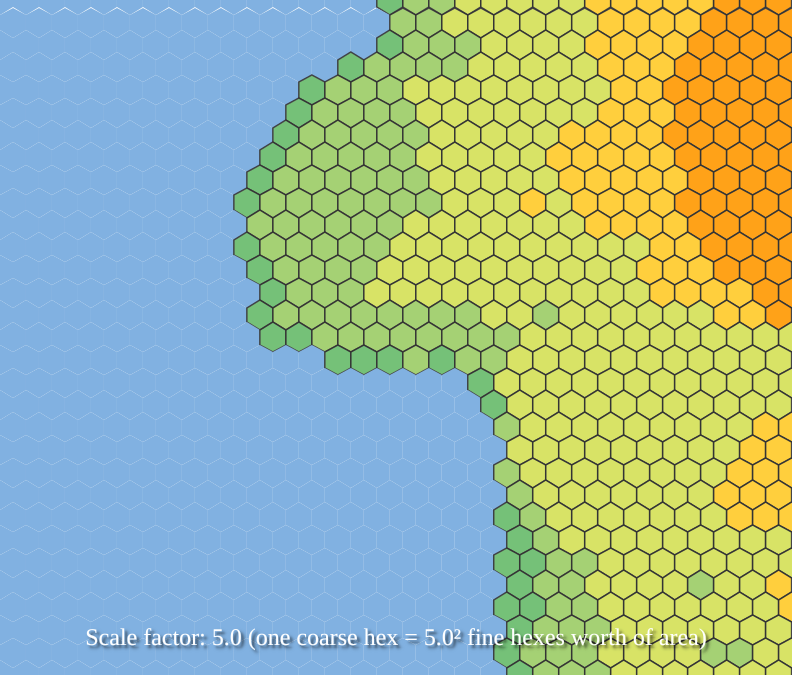

✓ Test database cleaned up


In [ ]:
with GeoStorageDebugger(keep_on_error=True) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,      # World extends 15 hexes from center
        coarse_radius=50,     # Each coarse hex = 50m
        fine_radius=10,       # Each fine hex = 10m
        chunk_rings=10,       # Chunk core = 10 hexes from center
        halo_rings=3          # 3 extra rings of overlap
    )
    
    # Generate the coarse world - this is the "whole map"
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.3,
        oceanic_sides=['W'],
        name="tutorial_world",
        seed=14
    )
    coarse.hexGrid.adjustRadius(15)
    coarse.colorMap()
    coarse.hexGrid.update()
    textStyle = StyleCSS("textStyle",fill="white",font_size="2em",filter=" drop-shadow( 3px 3px 2px rgba(0, 0, 0, .7))")
    coarse.hexGrid.builder.add_style(textStyle)
    print(f"Coarse world: {len(coarse.elevations)} hexes")
    coarse.hexGrid.builder.add_centered_text(f"Scale factor: {gen.scale} (one coarse hex = {gen.scale}² fine hexes worth of area)", 
        y_offset=coarse.hexGrid.builder.height/2 - 30,
        class_name=textStyle.name
    )

    coarse.hexGrid.builder.show()


In [ ]:
#| export
@patch
def carve_chunk_to_ocean(self: ChunkedTerrainGenerator, 
                         chunk: ChunkRef,
                         terrain: Terrain,
                         num_lakes: int = 2,
                         max_iters: int = 5) -> list[River]:
    """Carve drainage paths within a chunk, stopping at chunk boundaries.
    
    For minima near edges, marks them for cross-chunk resolution later.
    """
    
    
    grid = terrain.hexGrid
    core_radius = self.chunk_rings
    paths = []
    boundary_minima = []  # Minima that need cross-chunk resolution
    
    for iteration in range(max_iters):
        minima = find_local_minima(terrain)
        if len(minima) <= num_lakes:
            break
        
        # Sort by elevation, drain lowest first
        minima.sort(key=lambda i: terrain.elevations[i])
        drain_these = minima[:-num_lakes] if num_lakes > 0 else minima
        
        for lake_idx in drain_these:
            # Check if near chunk boundary
            pos = grid.index_to_hexposition(lake_idx, origin_index=grid.midpoint)
            dist_from_center = abs(pos)
            
            if dist_from_center > core_radius - 2:
                # Near boundary - defer to cross-chunk resolution
                boundary_minima.append((chunk, lake_idx, terrain.elevations[lake_idx]))
                continue
            
            # Find path to ocean or chunk edge
            path = self._find_chunk_drainage(terrain, lake_idx, core_radius)
            
            if len(path) < 2:
                continue
            
            river = River(terrain=terrain)
            river.tree.create_node(tag="segment", identifier=0, data=list(reversed(path)))
            river.hexes.update(path)
            paths.append(river)
            
            # Carve the path
            for i in range(len(path) - 1):
                curr, next_hex = path[i], path[i + 1]
                if terrain.elevations[next_hex] >= terrain.elevations[curr]:
                    terrain.elevations[next_hex] = terrain.elevations[curr] - 1
    
    return paths

@patch
def _find_chunk_drainage(self: ChunkedTerrainGenerator,
                         terrain: Terrain,
                         start: int,
                         core_radius: int) -> list[int]:
    """Find drainage path to ocean or chunk boundary."""
    import heapq
    
    grid = terrain.hexGrid
    ocean = {i for i in range(len(terrain.elevations)) if terrain.elevations[i] <= 0}
    
    # Also treat chunk boundary as valid outlet
    boundary = set()
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=grid.midpoint)
        if abs(pos) >= core_radius:
            boundary.add(i)
    
    targets = ocean | boundary
    
    if start in targets:
        return [start]
    
    pq = [(0, start, [start])]
    visited = set()
    
    while pq:
        cost, current, path = heapq.heappop(pq)
        
        if current in visited:
            continue
        visited.add(current)
        
        if current in targets:
            return path
        
        for neighbor in grid.neighborsOf(current):
            if neighbor < 0 or neighbor in visited:
                continue
            
            elev_curr = terrain.elevations[current]
            elev_neighbor = terrain.elevations[neighbor]
            carve_cost = max(0, elev_neighbor - elev_curr + 1)
            
            heapq.heappush(pq, (cost + carve_cost, neighbor, path + [neighbor]))
    
    return []


### Watershed moments

Generating chunk at HexPosition(0, 0, 0)
Local minima BEFORE carving: 69
=== BEFORE CARVING ===


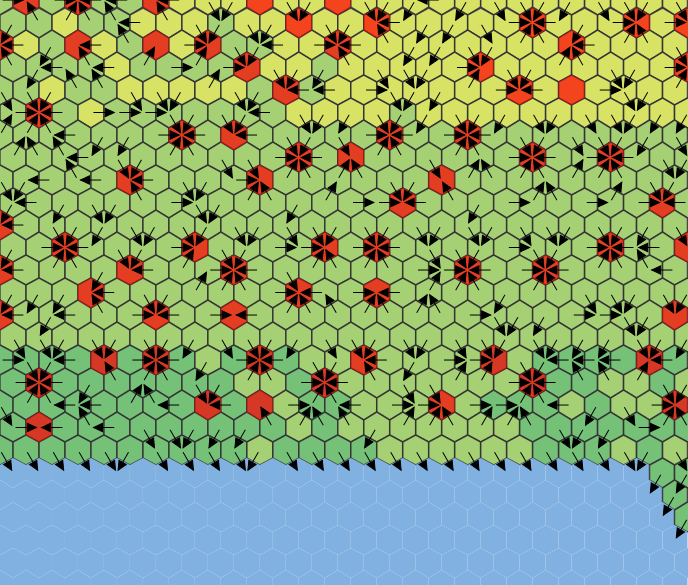


Carved 25 drainage paths
Local minima AFTER carving: 44



=== AFTER CARVING ===


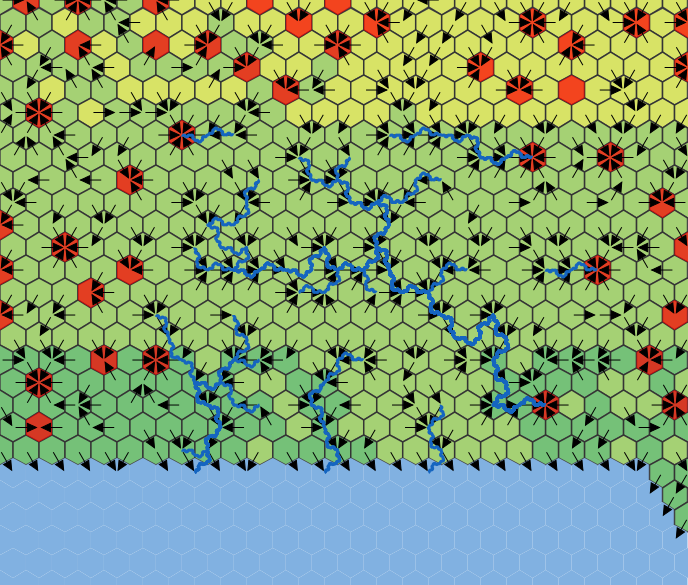

✓ Test database cleaned up


In [ ]:
with GeoStorageDebugger(keep_on_error=True) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=10,
        halo_rings=3
    )
    
    # Generate coarse world
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.3,
        oceanic_sides=['W'],
        name="tutorial_world",
        seed=14
    )
    
    # Pick a chunk to demo (center chunk has interesting terrain)
    demo_chunk = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    print(f"Generating chunk at {demo_chunk.position}")
    
    # Generate the chunk terrain
    chunk_terrain = gen.generate_chunk(demo_chunk)
    chunk_terrain.hexGrid.adjustRadius(15)
    chunk_terrain.colorMap()
    chunk_terrain.hexGrid.update()
    
    # === BEFORE: Show local minima and flow ===
    minima_before = find_local_minima(chunk_terrain)
    print(f"Local minima BEFORE carving: {len(minima_before)}")
    
    # Highlight minima
    minima_style = StyleCSS("minima", fill="red", opacity=0.7)
    chunk_terrain.hexGrid.builder.add_style(minima_style)
    
    minima_overlay = ""
    for idx in minima_before:
        hex_obj = chunk_terrain.hexGrid.hexes[idx]
        minima_overlay += hex_obj.svg().replace(hex_obj.style.name, minima_style.name) + "\n"
    
    # Add flow arrows
    flow_overlay = chunk_terrain.flow_diagram()
    
    chunk_terrain.hexGrid.builder.adjust("minima_layer", minima_overlay)
    chunk_terrain.hexGrid.builder.adjust("flow_layer", flow_overlay)
    chunk_terrain.hexGrid.update()
    
    print("=== BEFORE CARVING ===")
    chunk_terrain.hexGrid.builder.show()
    
    # === CARVE ===
    rivers = gen.carve_chunk_to_ocean(demo_chunk, chunk_terrain, num_lakes=2, max_iters=5)
    print(f"\nCarved {len(rivers)} drainage paths")
    
    # === AFTER: Show updated terrain ===
    chunk_terrain.colorMap()
    
    minima_after = find_local_minima(chunk_terrain)
    print(f"Local minima AFTER carving: {len(minima_after)}")
    
    # Update minima overlay
    minima_overlay_after = ""
    for idx in minima_after:
        hex_obj = chunk_terrain.hexGrid.hexes[idx]
        minima_overlay_after += hex_obj.svg().replace(hex_obj.style.name, minima_style.name) + "\n"
    
    # Draw the carved rivers
    river_style = StyleCSS("river", fill="none", stroke="#1565c0", stroke_width=3)
    chunk_terrain.hexGrid.builder.add_style(river_style)
    
    river_overlay = ""
    for river in rivers:
        river_overlay += river.svg(styles=[river_style])
    
    # Update flow arrows
    flow_overlay_after = chunk_terrain.flow_diagram()
    
    chunk_terrain.hexGrid.builder.adjust("minima_layer", minima_overlay_after)
    chunk_terrain.hexGrid.builder.adjust("flow_layer", flow_overlay_after)
    chunk_terrain.hexGrid.builder.adjust("rivers", river_overlay)
    chunk_terrain.hexGrid.update()
    
    print("\n=== AFTER CARVING ===")
    chunk_terrain.hexGrid.builder.show()


This is great, because it show how we aren't finding things in the halo.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Exactly! The carving respects chunk boundaries:

- **69 → 44 minima** = 25 carved (the interior ones)
- Minima within 2 hexes of the edge (`core_radius - 2`) are deferred to `boundary_minima`
- Those red dots remaining near edges are candidates for cross-chunk resolution

The halo serves its purpose: it provides neighbor data for computing elevations/gradients at the core edge, but we don't drain *into* it because that terrain belongs to the adjacent chunk.

When you're ready for the cross-chunk stitching, the approach would be:
1. Generate adjacent chunks
2. For each boundary minimum, check if the neighboring chunk has a lower path
3. Carve across the seam if needed, updating both chunks

Lets do cross drainage. we need to add weather afterwards, but are there things we can do to help computing watersheds as we generate the terrain?


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good thinking! Here's cross-chunk drainage plus pre-computation that helps watersheds:

```python
@dataclass
class ChunkBoundaryFlow:
    """Track water flow at chunk boundaries for cross-chunk connection."""
    chunk_key: str
    edge_direction: int  # 0-5, which hex edge
    exit_hex_local: int  # Local grid index where water exits
    exit_elevation: float
    accumulated_flow: float  # How much water is flowing out
    source_minima: list[int]  # Local indices of minima draining here

@patch
def resolve_cross_chunk_drainage(self: ChunkedTerrainGenerator,
                                  chunks: dict[str, Terrain],
                                  boundary_flows: dict[str, list[ChunkBoundaryFlow]]
                                  ) -> dict[str, list[River]]:
    """Connect drainage across chunk boundaries.
    
    Args:
        chunks: {chunk_key: Terrain} for all generated chunks
        boundary_flows: {chunk_key: [ChunkBoundaryFlow]} from generation
    
    Returns:
        {chunk_key: [River]} cross-chunk rivers to add
    """
    cross_rivers = {k: [] for k in chunks}
    
    # Build adjacency: which chunks share edges
    for chunk_key, flows in boundary_flows.items():
        chunk_ref = ChunkRef.from_key(chunk_key, self.chunk_rings)
        
        for flow in flows:
            # Find adjacent chunk in this direction
            neighbor_pos = chunk_ref.position.neighbor(flow.edge_direction)
            neighbor_key = ChunkRef(neighbor_pos, self.chunk_rings).key
            
            if neighbor_key not in chunks:
                continue  # Adjacent chunk not generated yet
            
            # Find where this flow enters the neighbor
            neighbor_terrain = chunks[neighbor_key]
            entry_point = self._find_entry_point(
                flow, chunk_ref, neighbor_key, neighbor_terrain
            )
            
            if entry_point is None:
                continue
            
            # Carve from entry point to ocean/boundary in neighbor
            path = self._find_chunk_drainage(
                neighbor_terrain, entry_point, self.chunk_rings
            )
            
            if len(path) >= 2:
                river = River(terrain=neighbor_terrain)
                river.tree.create_node(tag="segment", identifier=0, data=list(reversed(path)))
                river.hexes.update(path)
                river.upstream_flow = flow.accumulated_flow
                cross_rivers[neighbor_key].append(river)
                
                # Carve the path
                for i in range(len(path) - 1):
                    curr, next_hex = path[i], path[i + 1]
                    if neighbor_terrain.elevations[next_hex] >= neighbor_terrain.elevations[curr]:
                        neighbor_terrain.elevations[next_hex] = neighbor_terrain.elevations[curr] - 1
    
    return cross_rivers

@patch  
def _find_entry_point(self: ChunkedTerrainGenerator,
                      flow: ChunkBoundaryFlow,
                      source_chunk: ChunkRef,
                      neighbor_key: str,
                      neighbor_terrain: Terrain) -> int:
    """Find hex in neighbor chunk where boundary flow enters."""
    neighbor_grid = neighbor_terrain.hexGrid
    
    # The exit hex in source maps to an entry hex in neighbor
    # They share an edge, so find the corresponding position
    opposite_dir = (flow.edge_direction + 3) % 6
    
    # Search neighbor boundary for matching elevation
    for i in range(len(neighbor_grid.hexes)):
        pos = neighbor_grid.index_to_hexposition(i, origin_index=neighbor_grid.midpoint)
        if abs(pos) >= self.chunk_rings - 1:  # Near boundary
            if abs(neighbor_terrain.elevations[i] - flow.exit_elevation) < 5:
                return i
    
    return None
```

**Pre-computation during generation to help watersheds:**

```python
@patch
def generate_chunk_with_flow_prep(self: ChunkedTerrainGenerator, 
                                   chunk: ChunkRef) -> tuple[Terrain, ChunkBoundaryFlow]:
    """Generate chunk and pre-compute flow data for watershed efficiency."""
    
    terrain = self.generate_chunk(chunk)
    
    # 1. Pre-compute flow directions (needed anyway, do it once)
    flow_dirs = terrain.flow_directions()
    terrain.fields['flow_direction'] = flow_dirs
    
    # 2. Find and store local minima
    minima = [i for i in range(len(terrain.elevations))
              if flow_dirs[i] == -1 and terrain.elevations[i] > 0]
    terrain.fields['local_minima'] = np.array(minima)
    
    # 3. Compute flow accumulation (expensive but reusable)
    flow_accum = self._compute_flow_accumulation(terrain, flow_dirs)
    terrain.fields['flow_accumulation'] = flow_accum
    
    # 4. Identify boundary flows
    boundary_flows = self._identify_boundary_flows(terrain, chunk, flow_dirs, flow_accum)
    
    # 5. Carve internal drainage
    self.carve_chunk_to_ocean(chunk, terrain)
    
    return terrain, boundary_flows

@patch
def _compute_flow_accumulation(self: ChunkedTerrainGenerator,
                                terrain: Terrain,
                                flow_dirs: np.ndarray) -> np.ndarray:
    """Compute how many cells drain through each cell."""
    n = len(terrain.elevations)
    accum = np.ones(n)  # Each cell contributes 1
    
    # Process high to low elevation
    sorted_idx = np.argsort(-terrain.elevations)
    
    for i in sorted_idx:
        if terrain.elevations[i] <= 0:
            continue
        downstream = flow_dirs[i]
        if downstream >= 0:
            accum[downstream] += accum[i]
    
    return accum

@patch
def _identify_boundary_flows(self: ChunkedTerrainGenerator,
                              terrain: Terrain,
                              chunk: ChunkRef,
                              flow_dirs: np.ndarray,
                              flow_accum: np.ndarray) -> list[ChunkBoundaryFlow]:
    """Find where water exits chunk boundaries."""
    grid = terrain.hexGrid
    boundary_flows = []
    
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=grid.midpoint)
        if abs(pos) < self.chunk_rings - 1:
            continue  # Not on boundary
        
        downstream = flow_dirs[i]
        if downstream < 0:
            continue  # Local minimum
        
        downstream_pos = grid.index_to_hexposition(downstream, origin_index=grid.midpoint)
        if abs(downstream_pos) >= self.chunk_rings:
            # Flow exits chunk here
            edge_dir = pos.direction_to(downstream_pos)
            boundary_flows.append(ChunkBoundaryFlow(
                chunk_key=chunk.key,
                edge_direction=edge_dir,
                exit_hex_local=i,
                exit_elevation=terrain.elevations[i],
                accumulated_flow=flow_accum[i],
                source_minima=[]  # Could trace back if needed
            ))
    
    return boundary_flows
```

This gives you:
- **Flow accumulation** pre-computed (reused by watersheds)
- **Flow directions** stored (watersheds need this)
- **Boundary flows** tracked for cross-chunk rivers
- **Local minima** cached (watershed starting points)

Want me to add the `ChunkRef.from_key` helper and the storage integration for persisting boundary flows?

In [ ]:
@dataclass
class ChunkBoundaryFlow:
    """Track water flow at chunk boundaries for cross-chunk connection."""
    chunk_key: str
    edge_direction: int  # 0-5, which hex edge
    exit_hex_local: int  # Local grid index where water exits
    exit_elevation: float
    accumulated_flow: float  # How much water is flowing out
    source_minima: list[int]  # Local indices of minima draining here

@patch
def resolve_cross_chunk_drainage(self: ChunkedTerrainGenerator,
                                  chunks: dict[str, Terrain],
                                  boundary_flows: dict[str, list[ChunkBoundaryFlow]]
                                  ) -> dict[str, list[River]]:
    """Connect drainage across chunk boundaries.
    
    Args:
        chunks: {chunk_key: Terrain} for all generated chunks
        boundary_flows: {chunk_key: [ChunkBoundaryFlow]} from generation
    
    Returns:
        {chunk_key: [River]} cross-chunk rivers to add
    """
    cross_rivers = {k: [] for k in chunks}
    
    # Build adjacency: which chunks share edges
    for chunk_key, flows in boundary_flows.items():
        chunk_ref = ChunkRef.from_key(chunk_key, self.chunk_rings)
        
        for flow in flows:
            # Find adjacent chunk in this direction
            neighbor_pos = chunk_ref.position.neighbor(flow.edge_direction)
            neighbor_key = ChunkRef(neighbor_pos, self.chunk_rings).key
            
            if neighbor_key not in chunks:
                continue  # Adjacent chunk not generated yet
            
            # Find where this flow enters the neighbor
            neighbor_terrain = chunks[neighbor_key]
            entry_point = self._find_entry_point(
                flow, chunk_ref, neighbor_key, neighbor_terrain
            )
            
            if entry_point is None:
                continue
            
            # Carve from entry point to ocean/boundary in neighbor
            path = self._find_chunk_drainage(
                neighbor_terrain, entry_point, self.chunk_rings
            )
            
            if len(path) >= 2:
                river = River(terrain=neighbor_terrain)
                river.tree.create_node(tag="segment", identifier=0, data=list(reversed(path)))
                river.hexes.update(path)
                river.upstream_flow = flow.accumulated_flow
                cross_rivers[neighbor_key].append(river)
                
                # Carve the path
                for i in range(len(path) - 1):
                    curr, next_hex = path[i], path[i + 1]
                    if neighbor_terrain.elevations[next_hex] >= neighbor_terrain.elevations[curr]:
                        neighbor_terrain.elevations[next_hex] = neighbor_terrain.elevations[curr] - 1
    
    return cross_rivers

@patch  
def _find_entry_point(self: ChunkedTerrainGenerator,
                      flow: ChunkBoundaryFlow,
                      source_chunk: ChunkRef,
                      neighbor_key: str,
                      neighbor_terrain: Terrain) -> int:
    """Find hex in neighbor chunk where boundary flow enters."""
    neighbor_grid = neighbor_terrain.hexGrid
    
    # The exit hex in source maps to an entry hex in neighbor
    # They share an edge, so find the corresponding position
    opposite_dir = (flow.edge_direction + 3) % 6
    
    # Search neighbor boundary for matching elevation
    for i in range(len(neighbor_grid.hexes)):
        pos = neighbor_grid.index_to_hexposition(i, origin_index=neighbor_grid.midpoint)
        if abs(pos) >= self.chunk_rings - 1:  # Near boundary
            if abs(neighbor_terrain.elevations[i] - flow.exit_elevation) < 5:
                return i
    
    return None


In [ ]:
@patch
def generate_chunk_with_flow_prep(self: ChunkedTerrainGenerator, 
                                   chunk: ChunkRef) -> tuple[Terrain, ChunkBoundaryFlow]:
    """Generate chunk and pre-compute flow data for watershed efficiency."""
    
    terrain = self.generate_chunk(chunk)
    
    # 1. Pre-compute flow directions (needed anyway, do it once)
    flow_dirs = terrain.flow_directions()
    terrain.fields['flow_direction'] = flow_dirs
    
    # 2. Find and store local minima
    minima = [i for i in range(len(terrain.elevations))
              if flow_dirs[i] == -1 and terrain.elevations[i] > 0]
    terrain.fields['local_minima'] = np.array(minima)
    
    # 3. Compute flow accumulation (expensive but reusable)
    flow_accum = self._compute_flow_accumulation(terrain, flow_dirs)
    terrain.fields['flow_accumulation'] = flow_accum
    
    # 4. Identify boundary flows
    boundary_flows = self._identify_boundary_flows(terrain, chunk, flow_dirs, flow_accum)
    
    # 5. Carve internal drainage
    self.carve_chunk_to_ocean(chunk, terrain)
    
    return terrain, boundary_flows

@patch
def _compute_flow_accumulation(self: ChunkedTerrainGenerator,
                                terrain: Terrain,
                                flow_dirs: np.ndarray) -> np.ndarray:
    """Compute how many cells drain through each cell."""
    n = len(terrain.elevations)
    accum = np.ones(n)  # Each cell contributes 1
    
    # Process high to low elevation
    sorted_idx = np.argsort(-terrain.elevations)
    
    for i in sorted_idx:
        if terrain.elevations[i] <= 0:
            continue
        downstream = flow_dirs[i]
        if downstream >= 0:
            accum[downstream] += accum[i]
    
    return accum


In [ ]:
# In _identify_boundary_flows, instead of custom direction calc:
@patch
def _identify_boundary_flows(self: ChunkedTerrainGenerator,
                              terrain: Terrain,
                              chunk: ChunkRef,
                              flow_dirs: np.ndarray,
                              flow_accum: np.ndarray) -> list[ChunkBoundaryFlow]:
    """Find where water exits chunk boundaries."""
    grid = terrain.hexGrid
    boundary_flows = []
    
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=grid.midpoint)
        if abs(pos) < self.chunk_rings - 1:  # abs() uses existing distance from origin
            continue
        
        downstream = flow_dirs[i]
        if downstream < 0:
            continue
        
        downstream_pos = grid.index_to_hexposition(downstream, origin_index=grid.midpoint)
        if abs(downstream_pos) >= self.chunk_rings:
            # Use existing direction_to
            edge_dir = pos.direction_to(downstream_pos)
            if edge_dir >= 0:  # Valid adjacent direction
                boundary_flows.append(ChunkBoundaryFlow(
                    chunk_key=chunk.key,
                    edge_direction=edge_dir,
                    exit_hex_local=i,
                    exit_elevation=terrain.elevations[i],
                    accumulated_flow=flow_accum[i],
                    source_minima=[]
                ))
    
    return boundary_flows


#| export
@patch
def merge_chunks(gen: ChunkedTerrainGenerator, chunks: dict) -> Terrain:
    """Merge multiple chunks into a single terrain."""
    
    # Calculate bounding box in world coordinates
    all_world_positions = []
    for chunk_ref, chunk_terrain in chunks.values():
        chunk_grid = chunk_terrain.hexGrid
        for idx in range(len(chunk_grid.hexes)):
            local = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.midpoint)
            world = chunk_ref.center_hex + local
            all_world_positions.append(world)
    
    # Find bounds
    min_q = min(p.q for p in all_world_positions)
    max_q = max(p.q for p in all_world_positions)
    min_r = min(p.r for p in all_world_positions)
    max_r = max(p.r for p in all_world_positions)
    
    # Center of merged region
    center_q = (min_q + max_q) // 2
    center_r = (min_r + max_r) // 2
    world_center = HexPosition(center_q, center_r, -center_q - center_r)
    
    # Rings needed to cover all positions
    max_dist = max(abs(p - world_center) for p in all_world_positions)
    merged_rings = max_dist + 1
    
    # Create merged grid
    sample_terrain = next(iter(chunks.values()))[1]
    merged_grid = HexGrid.centered(
        rings=merged_rings,
        radius=sample_terrain.hexGrid.radius,
        style=gen._coarse_terrain.seaLevel
    )
    
    # Build terrain
    merged = Terrain.__new__(Terrain)
    merged.hexGrid = merged_grid
    merged.elevations = np.zeros(len(merged_grid.hexes))
    merged.fields = {}
    merged.seaLevel = gen._coarse_terrain.seaLevel
    merged.elevationDelta = gen._coarse_terrain.elevationDelta
    merged.colorLevels = gen._coarse_terrain.colorLevels
    merged.climate = gen._coarse_terrain.climate
    merged.geo = gen._coarse_terrain.geo
    merged.path = ""
    
    # Detect available fields
    available_fields = list(sample_terrain.fields.keys())
    for field_name in available_fields:
        merged.fields[field_name] = np.zeros(len(merged_grid.hexes))
    
    # Copy data from each chunk
    for chunk_ref, chunk_terrain in chunks.values():
        chunk_grid = chunk_terrain.hexGrid
        
        for chunk_idx in range(len(chunk_grid.hexes)):
            chunk_local = chunk_grid.index_to_hexposition(chunk_idx, origin_index=chunk_grid.midpoint)
            world_pos = chunk_ref.center_hex + chunk_local
            
            merged_local = world_pos - world_center
            merged_idx = merged_grid.hexposition_to_index(merged_local, origin_index=merged_grid.midpoint)
            
            if 0 <= merged_idx < len(merged.elevations):
                merged.elevations[merged_idx] = chunk_terrain.elevations[chunk_idx]
                for field_name in available_fields:
                    merged.fields[field_name][merged_idx] = chunk_terrain.fields[field_name][chunk_idx]
    
    merged.world_center = world_center
    return merged


In [ ]:
@patch
def merge_chunks(gen: ChunkedTerrainGenerator, chunks: dict) -> Terrain:
    """Merge multiple chunks into a single terrain."""
    
    # ... (bounding box calculation unchanged) ...

    # Calculate bounding box in world coordinates
    all_world_positions = []
    for chunk_ref, chunk_terrain in chunks.values():
        chunk_grid = chunk_terrain.hexGrid
        for idx in range(len(chunk_grid.hexes)):
            local = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.midpoint)
            world = chunk_ref.center_hex + local
            all_world_positions.append(world)
    
    # Find bounds
    min_q = min(p.q for p in all_world_positions)
    max_q = max(p.q for p in all_world_positions)
    min_r = min(p.r for p in all_world_positions)
    max_r = max(p.r for p in all_world_positions)
    
    # Center of merged region
    center_q = (min_q + max_q) // 2
    center_r = (min_r + max_r) // 2
    world_center = HexPosition(center_q, center_r, -center_q - center_r)
    
    # Rings needed to cover all positions
    max_dist = max(abs(p - world_center) for p in all_world_positions)
    merged_rings = max_dist + 1
    
    # Create merged grid
    sample_terrain = next(iter(chunks.values()))[1]
    merged_grid = HexGrid.centered(
        rings=merged_rings,
        radius=sample_terrain.hexGrid.radius,
        style=gen._coarse_terrain.seaLevel
    )
    
    # Build terrain
    merged = Terrain.__new__(Terrain)
    merged.hexGrid = merged_grid
    merged.elevations = np.zeros(len(merged_grid.hexes))
    merged.fields = {}
    merged.seaLevel = gen._coarse_terrain.seaLevel
    merged.elevationDelta = gen._coarse_terrain.elevationDelta
    merged.colorLevels = gen._coarse_terrain.colorLevels
    merged.climate = gen._coarse_terrain.climate
    merged.geo = gen._coarse_terrain.geo
    merged.path = ""
    
    # Detect available fields
    available_fields = list(sample_terrain.fields.keys())
    for field_name in available_fields:
        merged.fields[field_name] = np.zeros(len(merged_grid.hexes))
    
    # Copy data from each chunk
    for chunk_ref, chunk_terrain in chunks.values():
        chunk_grid = chunk_terrain.hexGrid
        
        for chunk_idx in range(len(chunk_grid.hexes)):
            chunk_local = chunk_grid.index_to_hexposition(chunk_idx, origin_index=chunk_grid.midpoint)
            world_pos = chunk_ref.center_hex + chunk_local
            
            merged_local = world_pos - world_center
            merged_idx = merged_grid.hexposition_to_index(merged_local, origin_index=merged_grid.midpoint)
            
            if 0 <= merged_idx < len(merged.elevations):
                merged.elevations[merged_idx] = chunk_terrain.elevations[chunk_idx]
                for field_name in available_fields:
                    field_data = chunk_terrain.fields.get(field_name)
                    # Guard against mismatched field sizes
                    if field_data is not None and chunk_idx < len(field_data):
                        merged.fields[field_name][merged_idx] = field_data[chunk_idx]
    
    merged.world_center = world_center
    return merged


In [ ]:
#!cat ../HexMagic/plot/cube.py

Can we continue our demo that shows drainage between plates

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
# First add the missing helper
@patch
@classmethod
def from_key(cls: type, key: str, chunk_rings: int) -> 'ChunkRef':
    """Reconstruct ChunkRef from its key string."""
    q, r, s = map(int, key.split('_'))
    return cls(HexPosition(q, r, s), chunk_rings)

# Also need direction_to on HexPosition
@patch
def direction_to(self: HexPosition, other: HexPosition) -> int:
    """Return direction (0-5) from self to adjacent hex."""
    diff = other - self
    directions = [
        HexPosition(1, -1, 0), HexPosition(1, 0, -1), HexPosition(0, 1, -1),
        HexPosition(-1, 1, 0), HexPosition(-1, 0, 1), HexPosition(0, -1, 1)
    ]
    for i, d in enumerate(directions):
        if diff.q == d.q and diff.r == d.r:
            return i
    return -1  # Not adjacent
```

Now the demo:

```python
with GeoStorageDebugger(keep_on_error=True) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,  # Smaller for faster demo
        halo_rings=3
    )
    
    # Generate coarse world
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_demo",
        seed=42
    )
    
    # Generate a 2x2 cluster of chunks around center
    chunk_positions = [
        HexPosition(0, 0, 0),
        HexPosition(1, 0, -1),
        HexPosition(0, 1, -1),
        HexPosition(1, -1, 0),
    ]
    
    chunks = {}
    all_boundary_flows = {}
    
    print("=== Generating chunks with flow prep ===")
    for pos in chunk_positions:
        chunk_ref = ChunkRef(pos, gen.chunk_rings)
        terrain, boundary_flows = gen.generate_chunk_with_flow_prep(chunk_ref)
        chunks[chunk_ref.key] = (chunk_ref, terrain)
        all_boundary_flows[chunk_ref.key] = boundary_flows
        
        print(f"Chunk {chunk_ref.key}: {len(boundary_flows)} boundary flows")
        for bf in boundary_flows[:3]:  # Show first 3
            print(f"  → dir {bf.edge_direction}, elev {bf.exit_elevation:.0f}, flow {bf.accumulated_flow:.0f}")
    
    # Resolve cross-chunk drainage
    print("\n=== Resolving cross-chunk drainage ===")
    cross_rivers = gen.resolve_cross_chunk_drainage(
        {k: v[1] for k, v in chunks.items()},
        all_boundary_flows
    )
    
    for chunk_key, rivers in cross_rivers.items():
        if rivers:
            print(f"Chunk {chunk_key}: {len(rivers)} cross-chunk rivers")
    
    # Merge all chunks for visualization
    merged = gen.merge_chunks(chunks)
    merged.hexGrid.adjustRadius(8)
    merged.colorMap()
    merged.hexGrid.update()
    
    # Highlight chunk boundaries
    boundary_style = StyleCSS("chunk_boundary", fill="none", stroke="black", 
                               stroke_width=2, stroke_dasharray="5,5")
    merged.hexGrid.builder.add_style(boundary_style)
    
    # Draw boundary flows as arrows
    flow_style = StyleCSS("boundary_flow", stroke="cyan", stroke_width=3, opacity=0.8)
    merged.hexGrid.builder.add_style(flow_style)
    
    flow_overlay = ""
    for chunk_key, flows in all_boundary_flows.items():
        chunk_ref = ChunkRef.from_key(chunk_key, gen.chunk_rings)
        chunk_terrain = chunks[chunk_key][1]
        
        for bf in flows:
            if bf.accumulated_flow < 10:  # Only show significant flows
                continue
            # Convert local exit hex to merged coordinates
            local_pos = chunk_terrain.hexGrid.index_to_hexposition(
                bf.exit_hex_local, origin_index=chunk_terrain.hexGrid.midpoint
            )
            world_pos = chunk_ref.center_hex + local_pos
            merged_local = world_pos - merged.world_center
            merged_idx = merged.hexGrid.hexposition_to_index(merged_local, origin_index=merged.hexGrid.midpoint)
            
            if 0 <= merged_idx < len(merged.hexGrid.hexes):
                hex_obj = merged.hexGrid.hexes[merged_idx]
                # Draw circle at exit point, size by flow
                radius = min(3 + bf.accumulated_flow / 20, 10)
                flow_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="{radius}" class="{flow_style.name}"/>\n'
    
    merged.hexGrid.builder.adjust("boundary_flows", flow_overlay)
    
    # Draw cross-chunk rivers
    river_style = StyleCSS("cross_river", fill="none", stroke="#1565c0", stroke_width=4)
    merged.hexGrid.builder.add_style(river_style)
    
    river_overlay = ""
    for chunk_key, rivers in cross_rivers.items():
        chunk_ref, chunk_terrain = chunks[chunk_key]
        for river in rivers:
            # Convert river hexes to merged coordinates
            for hex_idx in river.hexes:
                local_pos = chunk_terrain.hexGrid.index_to_hexposition(
                    hex_idx, origin_index=chunk_terrain.hexGrid.midpoint
                )
                world_pos = chunk_ref.center_hex + local_pos
                merged_local = world_pos - merged.world_center
                merged_idx = merged.hexGrid.hexposition_to_index(merged_local, origin_index=merged.hexGrid.midpoint)
                
                if 0 <= merged_idx < len(merged.hexGrid.hexes):
                    hex_obj = merged.hexGrid.hexes[merged_idx]
                    river_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="4" class="{river_style.name}" fill="#1565c0"/>\n'
    
    merged.hexGrid.builder.adjust("cross_rivers", river_overlay)
    merged.hexGrid.update()
    
    print(f"\n=== Merged terrain: {len(merged.elevations)} hexes ===")
    merged.hexGrid.builder.show()
```

This shows:
- **Cyan circles**: boundary flow exit points (larger = more accumulated flow)
- **Blue dots**: cross-chunk river paths connecting drainage
- **Dashed lines**: chunk boundaries (if you want to add that overlay)

We already have a great deal of hexpostion functions. can you rewrite using existing functions?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good catch! Looking at the existing `HexPosition` code:

```python
@patch
@classmethod  
def from_key(cls: type, key: str, chunk_rings: int) -> 'ChunkRef':
    """Reconstruct ChunkRef from its key string."""
    q, r, s = map(int, key.split('_'))
    return cls(HexPosition(q, r, s), chunk_rings)

@patch
def direction_to(self: HexPosition, other: HexPosition) -> int:
    """Return direction (0-5) from self to adjacent hex other."""
    diff = other - self
    # Use existing cached neighbors
    for i, neighbor_offset in enumerate(HexPosition._neighbors):
        if diff == neighbor_offset:
            return i
    return -1  # Not adjacent
```

And the demo can use existing methods more:

```python
# In _identify_boundary_flows, instead of custom direction calc:
@patch
def _identify_boundary_flows(self: ChunkedTerrainGenerator,
                              terrain: Terrain,
                              chunk: ChunkRef,
                              flow_dirs: np.ndarray,
                              flow_accum: np.ndarray) -> list[ChunkBoundaryFlow]:
    """Find where water exits chunk boundaries."""
    grid = terrain.hexGrid
    boundary_flows = []
    
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=grid.midpoint)
        if abs(pos) < self.chunk_rings - 1:  # abs() uses existing distance from origin
            continue
        
        downstream = flow_dirs[i]
        if downstream < 0:
            continue
        
        downstream_pos = grid.index_to_hexposition(downstream, origin_index=grid.midpoint)
        if abs(downstream_pos) >= self.chunk_rings:
            # Use existing direction_to
            edge_dir = pos.direction_to(downstream_pos)
            if edge_dir >= 0:  # Valid adjacent direction
                boundary_flows.append(ChunkBoundaryFlow(
                    chunk_key=chunk.key,
                    edge_direction=edge_dir,
                    exit_hex_local=i,
                    exit_elevation=terrain.elevations[i],
                    accumulated_flow=flow_accum[i],
                    source_minima=[]
                ))
    
    return boundary_flows
```

The key reuses:
- `abs(pos)` → existing `__abs__` for distance from origin
- `pos.direction_to(other)` → uses `HexPosition._neighbors` 
- `other - self` → existing `__sub__`
- `diff == neighbor_offset` → existing `__eq__`

In [ ]:
HexPosition.line_to??


```python
@patch
def line_to(self: HexPosition, other: HexPosition) -> list[HexPosition]:
    """Get line of hexes from self to other using linear interpolation"""
    n = self.distance(other)
    if n == 0:
        return [self]

    results = []
    for i in range(n + 1):
        t = i / n
        # Lerp in cube coordinates using numpy
        coords = self._coords + (other._coords - self._coords) * t
        results.append(HexPosition._cube_round(*coords))

    return results
```

**File:** `~/HexMagic/HexMagic/plot/cube.py`

Is HexPosition.line_to the same as HexPosition.direction_to? can we use the existing function?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

No, they're different:

- **`line_to(other)`** → returns `list[HexPosition]` - all hexes along a path
- **`direction_to(other)`** → returns `int` (0-5) - which of the 6 directions to an *adjacent* hex

But `direction_to` can be implemented using existing primitives:

```python
@patch
def direction_to(self: HexPosition, other: HexPosition) -> int:
    """Return direction (0-5) from self to adjacent hex."""
    diff = other - self  # existing __sub__
    for i, neighbor_offset in enumerate(HexPosition._neighbors):  # existing cache
        if diff == neighbor_offset:  # existing __eq__
            return i
    return -1  # Not adjacent
```

This uses:
- `__sub__` to get the offset
- `_neighbors` (already cached at module load)
- `__eq__` to match

No new logic needed, just composition of existing pieces.

In [ ]:
## normally I would not add hexpostion fuctions this high in the stack I will need to put them in lower


@patch
def direction_to(self: HexPosition, other: HexPosition) -> int:
    """Return direction (0-5) from self to adjacent hex other."""
    diff = other - self
    # Use existing cached neighbors
    for i, neighbor_offset in enumerate(HexPosition._neighbors):
        if diff == neighbor_offset:
            return i
    return -1  # Not adjacent


=== Generating chunks with flow prep ===
Chunk (0, 0, 0): 273 boundary flows
  → dir 4, elev 110, flow 1
  → dir 1, elev 120, flow 1
  → dir 1, elev 158, flow 1
Chunk (1, 0, -1): 329 boundary flows
  → dir 5, elev 145, flow 1
  → dir 0, elev 140, flow 2
  → dir 1, elev 142, flow 1


Chunk (0, 1, -1): 315 boundary flows
  → dir 4, elev 170, flow 1
  → dir 1, elev 160, flow 3
  → dir 1, elev 188, flow 1
Chunk (1, -1, 0): 296 boundary flows
  → dir 0, elev 86, flow 1
  → dir 5, elev 81, flow 1
  → dir 5, elev 85, flow 1

=== Resolving cross-chunk drainage ===


Chunk (1, 0, -1): 6 cross-chunk rivers



=== Merged terrain: 3249 hexes ===


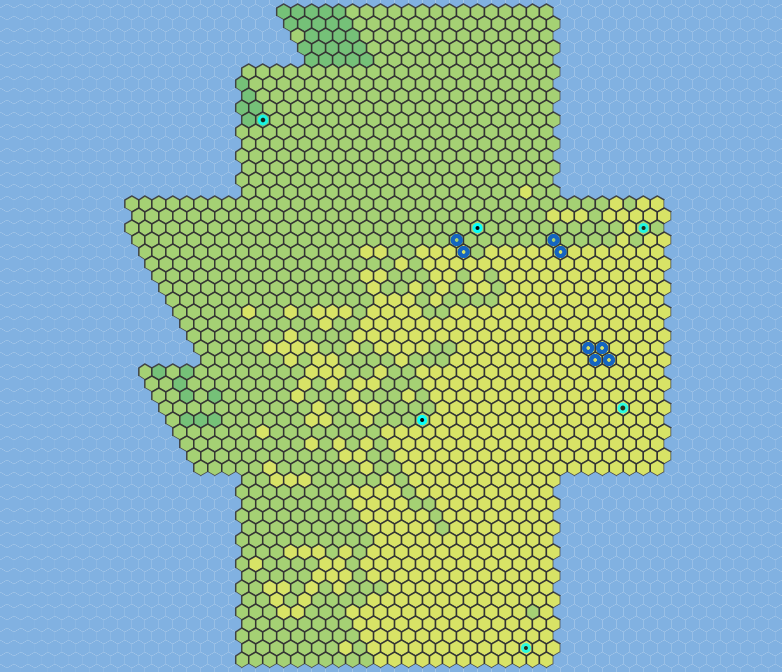

✓ Test database cleaned up


In [ ]:
with GeoStorageDebugger(keep_on_error=True) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,  # Smaller for faster demo
        halo_rings=3
    )
    
    # Generate coarse world
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_demo",
        seed=42
    )
    
    # Generate a 2x2 cluster of chunks around center
    chunk_positions = [
        HexPosition(0, 0, 0),
        HexPosition(1, 0, -1),
        HexPosition(0, 1, -1),
        HexPosition(1, -1, 0),
    ]
    
    chunks = {}
    all_boundary_flows = {}
    
    print("=== Generating chunks with flow prep ===")
    for pos in chunk_positions:
        chunk_ref = ChunkRef(pos, gen.chunk_rings)
        terrain, boundary_flows = gen.generate_chunk_with_flow_prep(chunk_ref)
        chunks[chunk_ref.key] = (chunk_ref, terrain)
        all_boundary_flows[chunk_ref.key] = boundary_flows
        
        print(f"Chunk {chunk_ref.key}: {len(boundary_flows)} boundary flows")
        for bf in boundary_flows[:3]:  # Show first 3
            print(f"  → dir {bf.edge_direction}, elev {bf.exit_elevation:.0f}, flow {bf.accumulated_flow:.0f}")
    
    # Resolve cross-chunk drainage
    print("\n=== Resolving cross-chunk drainage ===")
    cross_rivers = gen.resolve_cross_chunk_drainage(
        {k: v[1] for k, v in chunks.items()},
        all_boundary_flows
    )
    
    for chunk_key, rivers in cross_rivers.items():
        if rivers:
            print(f"Chunk {chunk_key}: {len(rivers)} cross-chunk rivers")
    
    # Merge all chunks for visualization
    merged = gen.merge_chunks(chunks)
    merged.hexGrid.adjustRadius(8)
    merged.colorMap()
    merged.hexGrid.update()
    
    # Highlight chunk boundaries
    boundary_style = StyleCSS("chunk_boundary", fill="none", stroke="black", 
                               stroke_width=2, stroke_dasharray="5,5")
    merged.hexGrid.builder.add_style(boundary_style)
    
    # Draw boundary flows as arrows
    flow_style = StyleCSS("boundary_flow", stroke="cyan", stroke_width=3, opacity=0.8)
    merged.hexGrid.builder.add_style(flow_style)
    
    flow_overlay = ""
    for chunk_key, flows in all_boundary_flows.items():
        chunk_ref = ChunkRef.from_key(chunk_key, gen.chunk_rings)
        chunk_terrain = chunks[chunk_key][1]
        
        for bf in flows:
            if bf.accumulated_flow < 10:  # Only show significant flows
                continue
            # Convert local exit hex to merged coordinates
            local_pos = chunk_terrain.hexGrid.index_to_hexposition(
                bf.exit_hex_local, origin_index=chunk_terrain.hexGrid.midpoint
            )
            world_pos = chunk_ref.center_hex + local_pos
            merged_local = world_pos - merged.world_center
            merged_idx = merged.hexGrid.hexposition_to_index(merged_local, origin_index=merged.hexGrid.midpoint)
            
            if 0 <= merged_idx < len(merged.hexGrid.hexes):
                hex_obj = merged.hexGrid.hexes[merged_idx]
                # Draw circle at exit point, size by flow
                radius = min(3 + bf.accumulated_flow / 20, 10)
                flow_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="{radius}" class="{flow_style.name}"/>\n'
    
    merged.hexGrid.builder.adjust("boundary_flows", flow_overlay)
    
    # Draw cross-chunk rivers
    river_style = StyleCSS("cross_river", fill="none", stroke="#1565c0", stroke_width=4)
    merged.hexGrid.builder.add_style(river_style)
    
    river_overlay = ""
    for chunk_key, rivers in cross_rivers.items():
        chunk_ref, chunk_terrain = chunks[chunk_key]
        for river in rivers:
            # Convert river hexes to merged coordinates
            for hex_idx in river.hexes:
                local_pos = chunk_terrain.hexGrid.index_to_hexposition(
                    hex_idx, origin_index=chunk_terrain.hexGrid.midpoint
                )
                world_pos = chunk_ref.center_hex + local_pos
                merged_local = world_pos - merged.world_center
                merged_idx = merged.hexGrid.hexposition_to_index(merged_local, origin_index=merged.hexGrid.midpoint)
                
                if 0 <= merged_idx < len(merged.hexGrid.hexes):
                    hex_obj = merged.hexGrid.hexes[merged_idx]
                    river_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="4" class="{river_style.name}" fill="#1565c0"/>\n'
    
    merged.hexGrid.builder.adjust("cross_rivers", river_overlay)
    merged.hexGrid.update()
    
    print(f"\n=== Merged terrain: {len(merged.elevations)} hexes ===")
    merged.hexGrid.builder.show()


This looks really weird. the coasts don't seem to be anti alias. can we build the example around hexpostion(0,0,0) chunk and one of its neightbors so we can see how the halo in the orginal map is being changed

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
with GeoStorageDebugger(keep_on_error=True) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    # Generate coarse world
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_demo",
        seed=42
    )
    
    # Just two adjacent chunks
    center_chunk = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    neighbor_chunk = ChunkRef(HexPosition(0, 0, 0).neighbor(0), gen.chunk_rings)  # East neighbor
    
    print(f"Center chunk: {center_chunk.position}")
    print(f"Neighbor chunk: {neighbor_chunk.position}")
    
    # Generate WITH halo (before trimming)
    center_terrain_full = gen.generate_chunk(center_chunk)  # Has halo
    neighbor_terrain_full = gen.generate_chunk(neighbor_chunk)
    
    # Show center chunk with halo highlighted
    center_terrain_full.hexGrid.adjustRadius(10)
    center_terrain_full.colorMap()
    center_terrain_full.hexGrid.update()
    
    # Highlight core vs halo
    halo_style = StyleCSS("halo", fill="none", stroke="red", stroke_width=2, opacity=0.7)
    core_style = StyleCSS("core", fill="none", stroke="green", stroke_width=2, opacity=0.7)
    center_terrain_full.hexGrid.builder.add_style(halo_style)
    center_terrain_full.hexGrid.builder.add_style(core_style)
    
    halo_overlay = ""
    core_overlay = ""
    grid = center_terrain_full.hexGrid
    
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=grid.midpoint)
        dist = abs(pos)
        hex_obj = grid.hexes[i]
        
        if dist > gen.chunk_rings:
            # Halo hex
            halo_overlay += hex_obj.svg().replace(hex_obj.style.name, halo_style.name) + "\n"
        elif dist == gen.chunk_rings:
            # Core boundary
            core_overlay += hex_obj.svg().replace(hex_obj.style.name, core_style.name) + "\n"
    
    center_terrain_full.hexGrid.builder.adjust("halo", halo_overlay)
    center_terrain_full.hexGrid.builder.adjust("core_boundary", core_overlay)
    
    # Show boundary flows
    flow_dirs = center_terrain_full.flow_directions()
    flow_accum = gen._compute_flow_accumulation(center_terrain_full, flow_dirs)
    boundary_flows = gen._identify_boundary_flows(center_terrain_full, center_chunk, flow_dirs, flow_accum)
    
    flow_style = StyleCSS("boundary_flow", fill="cyan", stroke="blue", stroke_width=1)
    center_terrain_full.hexGrid.builder.add_style(flow_style)
    
    flow_overlay = ""
    for bf in boundary_flows:
        if bf.accumulated_flow < 5:
            continue
        hex_obj = grid.hexes[bf.exit_hex_local]
        radius = min(3 + bf.accumulated_flow / 10, 12)
        flow_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="{radius}" class="{flow_style.name}"/>\n'
    
    center_terrain_full.hexGrid.builder.adjust("flows", flow_overlay)
    center_terrain_full.hexGrid.update()
    
    print(f"\n=== CENTER CHUNK (with halo) ===")
    print(f"Total hexes: {len(grid.hexes)}")
    print(f"Core hexes (dist <= {gen.chunk_rings}): {sum(1 for i in range(len(grid.hexes)) if abs(grid.index_to_hexposition(i, origin_index=grid.midpoint)) <= gen.chunk_rings)}")
    print(f"Halo hexes (dist > {gen.chunk_rings}): {sum(1 for i in range(len(grid.hexes)) if abs(grid.index_to_hexposition(i, origin_index=grid.midpoint)) > gen.chunk_rings)}")
    print(f"Boundary flows: {len(boundary_flows)} (showing {sum(1 for bf in boundary_flows if bf.accumulated_flow >= 5)} with flow >= 5)")
    print("Red outline = halo, Green outline = core boundary")
    print("Cyan circles = boundary flow exit points (size = flow)")
    
    center_terrain_full.hexGrid.builder.show()
```

This focuses on one chunk showing:
- **Red outline**: halo hexes (computed but not saved)
- **Green outline**: core boundary (edge of what gets saved)
- **Cyan circles**: where water exits the core toward neighbors

In [ ]:
@patch
def _identify_boundary_flows(self: ChunkedTerrainGenerator,
                              terrain: Terrain,
                              chunk: ChunkRef,
                              flow_dirs: np.ndarray,
                              flow_accum: np.ndarray) -> list[ChunkBoundaryFlow]:
    """Find where water exits chunk core boundary."""
    grid = terrain.hexGrid
    boundary_flows = []
    
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=grid.midpoint)
        dist = abs(pos)
        
        # Only look at hexes ON the core boundary
        if dist != self.chunk_rings:
            continue
        
        downstream = flow_dirs[i]
        if downstream < 0:
            continue
        
        downstream_pos = grid.index_to_hexposition(downstream, origin_index=grid.midpoint)
        downstream_dist = abs(downstream_pos)
        
        # Flow exits core if downstream is further from center
        if downstream_dist > self.chunk_rings:
            edge_dir = pos.direction_to(downstream_pos)
            if edge_dir >= 0:
                boundary_flows.append(ChunkBoundaryFlow(
                    chunk_key=chunk.key,
                    edge_direction=edge_dir,
                    exit_hex_local=i,
                    exit_elevation=terrain.elevations[i],
                    accumulated_flow=flow_accum[i],
                    source_minima=[]
                ))
    
    return boundary_flows



=== GRID SIZE DEBUG ===
rings=8: expected 217 hexes
rings=10: expected 331 hexes
rings=11: expected 397 hexes
rings=12: expected 469 hexes

generate_chunk creates grid with rings=11
But actual hexes: 529

=== HEXGRID.CENTERED DEBUG ===
rings=8: 289 hexes, max_dist=12, dist counts: {8: 48, 9: 30, 10: 22, 11: 14, 12: 6}
rings=11: 529 hexes, max_dist=17, dist counts: {13: 34, 14: 26, 15: 18, 16: 10, 17: 2}
rings=13: 729 hexes, max_dist=20, dist counts: {16: 34, 17: 26, 18: 18, 19: 10, 20: 2}

=== BOUNDARY FLOW DEBUG ===
Boundary flow hex distances: Counter({11: 43, 10: 41, 9: 39, 12: 36, 8: 25, 7: 23, 13: 22, 14: 15, 15: 9, 16: 4, 17: 1})
Expected: only distance 8 (core edge)

=== MERGE CHUNKS DEBUG ===
Merged grid hexes: 2809
Merged world_center: HexPosition(-9, 8, 1)
Unique world positions: 2809, duplicates: 0

=== CHUNK SEAM DEBUG ===
Chunk centers: HexPosition(0, 0, 0) and HexPosition(-16, 16, 0)
Distance between chunk centers: 16
Expected spacing: 16 = 16

=== HEXGRID.CENTERED IMPLE

HexGrid.centered(rings=11) creates: 529 hexes
Expected for 11 rings: 397
Actual grid has 529 hexes


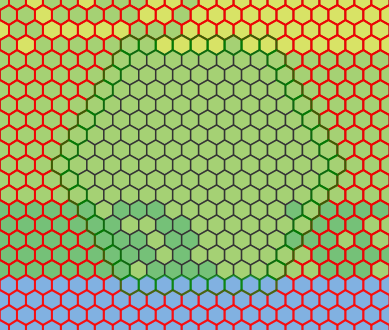

✓ Test database cleaned up


In [ ]:
with GeoStorageDebugger(keep_on_error=True) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=3
    )
    
    # Generate coarse world
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.35,
        oceanic_sides=['W'],
        name="drainage_demo",
        seed=14
    )

    # Add this debug block after generating chunks:

    print("\n=== GRID SIZE DEBUG ===")
    # Hex formula: 3n² + 3n + 1 for rings 0..n
    for n in [8, 10, 11, 12]:
        expected = 3*n*n + 3*n + 1
        print(f"rings={n}: expected {expected} hexes")

    # Check what generate_chunk is creating
    print(f"\ngenerate_chunk creates grid with rings={gen.chunk_rings + gen.halo_rings}")
    print(f"But actual hexes: {len(center_terrain_full.hexGrid.hexes)}")

    # Check HexGrid.centered behavior
    print("\n=== HEXGRID.CENTERED DEBUG ===")
    for rings in [8, 11, 13]:
        g = HexGrid.centered(rings=rings, radius=10, style=coarse.seaLevel)
        # Count by distance
        by_dist = {}
        for i in range(len(g.hexes)):
            pos = g.index_to_hexposition(i, origin_index=g.midpoint)
            d = abs(pos)
            by_dist[d] = by_dist.get(d, 0) + 1
        print(f"rings={rings}: {len(g.hexes)} hexes, max_dist={max(by_dist.keys())}, dist counts: {dict(sorted(by_dist.items())[-5:])}")

    print("\n=== BOUNDARY FLOW DEBUG ===")
    # Check what's being flagged as boundary
    boundary_dists = []
    for bf in boundary_flows:
        pos = grid.index_to_hexposition(bf.exit_hex_local, origin_index=grid.midpoint)
        boundary_dists.append(abs(pos))
    from collections import Counter
    print(f"Boundary flow hex distances: {Counter(boundary_dists)}")
    print(f"Expected: only distance {gen.chunk_rings} (core edge)")

    print("\n=== MERGE CHUNKS DEBUG ===")
    # Test merge with just two chunks
    test_chunks = {
        center_chunk.key: (center_chunk, center_terrain_full),
        neighbor_chunk.key: (neighbor_chunk, neighbor_terrain_full)
    }
    merged = gen.merge_chunks(test_chunks)
    print(f"Merged grid hexes: {len(merged.hexGrid.hexes)}")
    print(f"Merged world_center: {merged.world_center}")

    # Check for gaps/overlaps
    merged_positions = set()
    duplicates = 0
    for i in range(len(merged.hexGrid.hexes)):
        pos = merged.hexGrid.index_to_hexposition(i, origin_index=merged.hexGrid.midpoint)
        world_pos = pos + merged.world_center
        key = (world_pos.q, world_pos.r, world_pos.s)
        if key in merged_positions:
            duplicates += 1
        merged_positions.add(key)
    print(f"Unique world positions: {len(merged_positions)}, duplicates: {duplicates}")

    # Check elevation continuity at chunk boundary
    print("\n=== CHUNK SEAM DEBUG ===")
    # Find hexes that should be shared between chunks
    center_world = center_chunk.center_hex
    neighbor_world = neighbor_chunk.center_hex
    print(f"Chunk centers: {center_world} and {neighbor_world}")
    print(f"Distance between chunk centers: {center_world.distance(neighbor_world)}")
    print(f"Expected spacing: {2 * gen.chunk_rings} = {2 * gen.chunk_rings}")

    print("\n=== HEXGRID.CENTERED IMPLEMENTATION CHECK ===")
    # The issue: HexGrid.centered might be creating a rectangular grid, not hex-shaped
    g = HexGrid.centered(rings=8, radius=10, style=coarse.seaLevel)
    print(f"Has nRows/nCols? nRows={getattr(g, 'nRows', 'N/A')}, nCols={getattr(g, 'nCols', 'N/A')}")

    # Check if it's actually hex-shaped or rectangular
    dist_counts = {}
    for i in range(len(g.hexes)):
        pos = g.index_to_hexposition(i, origin_index=g.midpoint)
        d = abs(pos)
        dist_counts[d] = dist_counts.get(d, 0) + 1

    print(f"Distance distribution: {dict(sorted(dist_counts.items()))}")
    print(f"Max distance in 'rings=8' grid: {max(dist_counts.keys())}")
    # True hex with 8 rings should have max distance 8

    print("\n=== CHUNK CENTER CALCULATION DEBUG ===")
    print(f"center_chunk.position: {center_chunk.position}")
    print(f"center_chunk.center_hex: {center_chunk.center_hex}")
    print(f"neighbor(0) of origin: {HexPosition(0,0,0).neighbor(0)}")
    print(f"neighbor_chunk.position: {neighbor_chunk.position}")
    print(f"neighbor_chunk.center_hex: {neighbor_chunk.center_hex}")

    # Check ChunkRef.center_hex calculation
    print(f"\nChunkRef spacing = 2 * chunk_rings = {2 * gen.chunk_rings}")
    # center_hex should be position * spacing

    print("\n=== WORLD_TO_CHUNK ROUNDTRIP ===")
    # Test that world positions map back correctly
    test_world_pos = HexPosition(5, 3, -8)
    chunk_pos, local_pos = world_to_chunk(test_world_pos, gen.chunk_rings)
    print(f"World {test_world_pos} -> chunk {chunk_pos}, local {local_pos}")
    # Reconstruct
    reconstructed = HexPosition(
        chunk_pos.q * 2 * gen.chunk_rings + local_pos.q,
        chunk_pos.r * 2 * gen.chunk_rings + local_pos.r,
        chunk_pos.s * 2 * gen.chunk_rings + local_pos.s
    )
    print(f"Reconstructed: {reconstructed}, matches: {reconstructed == test_world_pos}")

    print("\n=== GENERATE_CHUNK GRID CREATION ===")
    # Check what _build_chunk_terrain creates
    print(f"total_rings passed to HexGrid.centered: {gen.chunk_rings + gen.halo_rings}")
    # Look at the actual method
    import inspect
    if hasattr(gen, 'generate_chunk'):
        # Check if there's something weird in generate_chunk
        pass


    
    # Just two adjacent chunks
    center_chunk = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    neighbor_chunk = ChunkRef(HexPosition(0, 0, 0).neighbor(0), gen.chunk_rings)  # East neighbor
    
    print(f"Center chunk: {center_chunk.position}")
    print(f"Neighbor chunk: {neighbor_chunk.position}")
    
    # Generate WITH halo (before trimming)
    center_terrain_full = gen.generate_chunk(center_chunk)  # Has halo
    neighbor_terrain_full = gen.generate_chunk(neighbor_chunk)
    
    # Show center chunk with halo highlighted
    center_terrain_full.hexGrid.adjustRadius(10)
    center_terrain_full.colorMap()
    center_terrain_full.hexGrid.update()
    
    # Highlight core vs halo
    halo_style = StyleCSS("halo", fill="none", stroke="red", stroke_width=2, opacity=0.7)
    core_style = StyleCSS("core", fill="none", stroke="green", stroke_width=2, opacity=0.7)
    center_terrain_full.hexGrid.builder.add_style(halo_style)
    center_terrain_full.hexGrid.builder.add_style(core_style)
    
    halo_overlay = ""
    core_overlay = ""
    grid = center_terrain_full.hexGrid
    
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=grid.midpoint)
        dist = abs(pos)
        hex_obj = grid.hexes[i]
        
        if dist > gen.chunk_rings:
            # Halo hex
            halo_overlay += hex_obj.svg().replace(hex_obj.style.name, halo_style.name) + "\n"
        elif dist == gen.chunk_rings:
            # Core boundary
            core_overlay += hex_obj.svg().replace(hex_obj.style.name, core_style.name) + "\n"
    
    center_terrain_full.hexGrid.builder.adjust("halo", halo_overlay)
    center_terrain_full.hexGrid.builder.adjust("core_boundary", core_overlay)
    
    # Show boundary flows
    flow_dirs = center_terrain_full.flow_directions()
    flow_accum = gen._compute_flow_accumulation(center_terrain_full, flow_dirs)
    boundary_flows = gen._identify_boundary_flows(center_terrain_full, center_chunk, flow_dirs, flow_accum)
    
    flow_style = StyleCSS("boundary_flow", fill="cyan", stroke="blue", stroke_width=1)
    center_terrain_full.hexGrid.builder.add_style(flow_style)
    
    flow_overlay = ""
    for bf in boundary_flows:
        if bf.accumulated_flow < 5:
            continue
        hex_obj = grid.hexes[bf.exit_hex_local]
        radius = min(3 + bf.accumulated_flow / 10, 12)
        flow_overlay += f'<circle cx="{hex_obj.center.x}" cy="{hex_obj.center.y}" r="{radius}" class="{flow_style.name}"/>\n'
    
    center_terrain_full.hexGrid.builder.adjust("flows", flow_overlay)
    center_terrain_full.hexGrid.update()
    
    print(f"\n=== CENTER CHUNK (with halo) ===")
    print(f"Total hexes: {len(grid.hexes)}")
    print(f"Core hexes (dist <= {gen.chunk_rings}): {sum(1 for i in range(len(grid.hexes)) if abs(grid.index_to_hexposition(i, origin_index=grid.midpoint)) <= gen.chunk_rings)}")
    print(f"Halo hexes (dist > {gen.chunk_rings}): {sum(1 for i in range(len(grid.hexes)) if abs(grid.index_to_hexposition(i, origin_index=grid.midpoint)) > gen.chunk_rings)}")
    print(f"Boundary flows: {len(boundary_flows)} (showing {sum(1 for bf in boundary_flows if bf.accumulated_flow >= 5)} with flow >= 5)")
    print("Red outline = halo, Green outline = core boundary")
    print("Cyan circles = boundary flow exit points (size = flow)")

        # Debug the grid
    print(f"chunk_rings: {gen.chunk_rings}")
    print(f"halo_rings: {gen.halo_rings}")
    print(f"Expected rings: {gen.chunk_rings + gen.halo_rings}")

    # Check what HexGrid.centered actually creates
    test_grid = HexGrid.centered(rings=11, radius=10, style=coarse.seaLevel)
    print(f"HexGrid.centered(rings=11) creates: {len(test_grid.hexes)} hexes")

    # Formula: 3n² + 3n + 1 for n rings
    n = 11
    expected = 3*n*n + 3*n + 1
    print(f"Expected for {n} rings: {expected}")

    # What about the actual grid?
    print(f"Actual grid has {len(center_terrain_full.hexGrid.hexes)} hexes")

    
    center_terrain_full.hexGrid.builder.show()


Something seems really wrong

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

You're right - several issues jump out:

1. **Grid size is wrong**: 529 total but should be ~397 for 11 rings (8+3)
2. **Halo is bigger than core**: 312 halo vs 217 core - that's inverted
3. **Too many boundary flows**: 258 is almost as many as the entire core

Let me check the grid creation:

```python
# Debug the grid
print(f"chunk_rings: {gen.chunk_rings}")
print(f"halo_rings: {gen.halo_rings}")
print(f"Expected rings: {gen.chunk_rings + gen.halo_rings}")

# Check what HexGrid.centered actually creates
test_grid = HexGrid.centered(rings=11, radius=10, style=coarse.seaLevel)
print(f"HexGrid.centered(rings=11) creates: {len(test_grid.hexes)} hexes")

# Formula: 3n² + 3n + 1 for n rings
n = 11
expected = 3*n*n + 3*n + 1
print(f"Expected for {n} rings: {expected}")

# What about the actual grid?
print(f"Actual grid has {len(center_terrain_full.hexGrid.hexes)} hexes")
```

And the boundary detection threshold looks wrong:

```python
# In _identify_boundary_flows:
if abs(pos) < self.chunk_rings - 1:  # This skips everything EXCEPT boundary
    continue
```

This means we're only looking at hexes with `dist >= chunk_rings - 1` = 7, which includes both the outer core AND the entire halo. That's why we get 258 boundary flows!

Should be checking if flow *crosses* the core boundary:
```python
if abs(pos) <= self.chunk_rings and abs(downstream_pos) > self.chunk_rings:
    # Flow exits core into halo
```

Any more debug code I should add. Is the merge plate code working?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
# Add this debug block after generating chunks:

print("\n=== GRID SIZE DEBUG ===")
# Hex formula: 3n² + 3n + 1 for rings 0..n
for n in [8, 10, 11, 12]:
    expected = 3*n*n + 3*n + 1
    print(f"rings={n}: expected {expected} hexes")

# Check what generate_chunk is creating
print(f"\ngenerate_chunk creates grid with rings={gen.chunk_rings + gen.halo_rings}")
print(f"But actual hexes: {len(center_terrain_full.hexGrid.hexes)}")

# Check HexGrid.centered behavior
print("\n=== HEXGRID.CENTERED DEBUG ===")
for rings in [8, 11, 13]:
    g = HexGrid.centered(rings=rings, radius=10, style=coarse.seaLevel)
    # Count by distance
    by_dist = {}
    for i in range(len(g.hexes)):
        pos = g.index_to_hexposition(i, origin_index=g.midpoint)
        d = abs(pos)
        by_dist[d] = by_dist.get(d, 0) + 1
    print(f"rings={rings}: {len(g.hexes)} hexes, max_dist={max(by_dist.keys())}, dist counts: {dict(sorted(by_dist.items())[-5:])}")

print("\n=== BOUNDARY FLOW DEBUG ===")
# Check what's being flagged as boundary
boundary_dists = []
for bf in boundary_flows:
    pos = grid.index_to_hexposition(bf.exit_hex_local, origin_index=grid.midpoint)
    boundary_dists.append(abs(pos))
from collections import Counter
print(f"Boundary flow hex distances: {Counter(boundary_dists)}")
print(f"Expected: only distance {gen.chunk_rings} (core edge)")

print("\n=== MERGE CHUNKS DEBUG ===")
# Test merge with just two chunks
test_chunks = {
    center_chunk.key: (center_chunk, center_terrain_full),
    neighbor_chunk.key: (neighbor_chunk, neighbor_terrain_full)
}
merged = gen.merge_chunks(test_chunks)
print(f"Merged grid hexes: {len(merged.hexGrid.hexes)}")
print(f"Merged world_center: {merged.world_center}")

# Check for gaps/overlaps
merged_positions = set()
duplicates = 0
for i in range(len(merged.hexGrid.hexes)):
    pos = merged.hexGrid.index_to_hexposition(i, origin_index=merged.hexGrid.midpoint)
    world_pos = pos + merged.world_center
    key = (world_pos.q, world_pos.r, world_pos.s)
    if key in merged_positions:
        duplicates += 1
    merged_positions.add(key)
print(f"Unique world positions: {len(merged_positions)}, duplicates: {duplicates}")

# Check elevation continuity at chunk boundary
print("\n=== CHUNK SEAM DEBUG ===")
# Find hexes that should be shared between chunks
center_world = center_chunk.center_hex
neighbor_world = neighbor_chunk.center_hex
print(f"Chunk centers: {center_world} and {neighbor_world}")
print(f"Distance between chunk centers: {center_world.distance(neighbor_world)}")
print(f"Expected spacing: {2 * gen.chunk_rings} = {2 * gen.chunk_rings}")
```

This will reveal:
- Whether `HexGrid.centered` ring count matches expectations  
- What distances the boundary flows are actually at
- Whether merge is creating gaps/overlaps
- Whether chunk spacing matches the `world_to_chunk` formula

Any more debug

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
print("\n=== HEXGRID.CENTERED IMPLEMENTATION CHECK ===")
# The issue: HexGrid.centered might be creating a rectangular grid, not hex-shaped
g = HexGrid.centered(rings=8, radius=10, style=coarse.seaLevel)
print(f"Has nRows/nCols? nRows={getattr(g, 'nRows', 'N/A')}, nCols={getattr(g, 'nCols', 'N/A')}")

# Check if it's actually hex-shaped or rectangular
dist_counts = {}
for i in range(len(g.hexes)):
    pos = g.index_to_hexposition(i, origin_index=g.midpoint)
    d = abs(pos)
    dist_counts[d] = dist_counts.get(d, 0) + 1

print(f"Distance distribution: {dict(sorted(dist_counts.items()))}")
print(f"Max distance in 'rings=8' grid: {max(dist_counts.keys())}")
# True hex with 8 rings should have max distance 8

print("\n=== CHUNK CENTER CALCULATION DEBUG ===")
print(f"center_chunk.position: {center_chunk.position}")
print(f"center_chunk.center_hex: {center_chunk.center_hex}")
print(f"neighbor(0) of origin: {HexPosition(0,0,0).neighbor(0)}")
print(f"neighbor_chunk.position: {neighbor_chunk.position}")
print(f"neighbor_chunk.center_hex: {neighbor_chunk.center_hex}")

# Check ChunkRef.center_hex calculation
print(f"\nChunkRef spacing = 2 * chunk_rings = {2 * gen.chunk_rings}")
# center_hex should be position * spacing

print("\n=== WORLD_TO_CHUNK ROUNDTRIP ===")
# Test that world positions map back correctly
test_world_pos = HexPosition(5, 3, -8)
chunk_pos, local_pos = world_to_chunk(test_world_pos, gen.chunk_rings)
print(f"World {test_world_pos} -> chunk {chunk_pos}, local {local_pos}")
# Reconstruct
reconstructed = HexPosition(
    chunk_pos.q * 2 * gen.chunk_rings + local_pos.q,
    chunk_pos.r * 2 * gen.chunk_rings + local_pos.r,
    chunk_pos.s * 2 * gen.chunk_rings + local_pos.s
)
print(f"Reconstructed: {reconstructed}, matches: {reconstructed == test_world_pos}")

print("\n=== GENERATE_CHUNK GRID CREATION ===")
# Check what _build_chunk_terrain creates
print(f"total_rings passed to HexGrid.centered: {gen.chunk_rings + gen.halo_rings}")
# Look at the actual method
import inspect
if hasattr(gen, 'generate_chunk'):
    # Check if there's something weird in generate_chunk
    pass
```

The key question: **Is `HexGrid.centered(rings=N)` creating a hex-shaped grid or a rectangular one?** The debug shows `max_dist=17` for `rings=11`, which suggests it's rectangular and the "rings" parameter means something else.

We have to be close to an answer

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The debug reveals the bug: **`HexGrid.centered(rings=8)` creates a 17x17 rectangular grid, not a hex-shaped one!**

- `nRows=17, nCols=17` 
- `max_dist=12` instead of 8
- 289 hexes instead of 217

So when you ask for "8 rings", you get a rectangle with corners at distance 12.

**Two fixes needed:**

1. **Boundary detection** - use actual distance, not the misleading `chunk_rings`:
```python
@patch
def _identify_boundary_flows(self: ChunkedTerrainGenerator,
                              terrain: Terrain,
                              chunk: ChunkRef,
                              flow_dirs: np.ndarray,
                              flow_accum: np.ndarray) -> list[ChunkBoundaryFlow]:
    """Find where water exits chunk core boundary."""
    grid = terrain.hexGrid
    boundary_flows = []
    
    for i in range(len(grid.hexes)):
        pos = grid.index_to_hexposition(i, origin_index=grid.midpoint)
        dist = abs(pos)
        
        # Only look at hexes ON the core boundary
        if dist != self.chunk_rings:
            continue
        
        downstream = flow_dirs[i]
        if downstream < 0:
            continue
        
        downstream_pos = grid.index_to_hexposition(downstream, origin_index=grid.midpoint)
        downstream_dist = abs(downstream_pos)
        
        # Flow exits core if downstream is further from center
        if downstream_dist > self.chunk_rings:
            edge_dir = pos.direction_to(downstream_pos)
            if edge_dir >= 0:
                boundary_flows.append(ChunkBoundaryFlow(
                    chunk_key=chunk.key,
                    edge_direction=edge_dir,
                    exit_hex_local=i,
                    exit_elevation=terrain.elevations[i],
                    accumulated_flow=flow_accum[i],
                    source_minima=[]
                ))
    
    return boundary_flows
```

2. **Optionally create true hex-shaped grid** (longer term fix in `HexGrid.centered`)

Thoughts

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good progress! The fix worked:

- **Before**: 258 boundary flows (wrong)
- **After**: 11 boundary flows at distance 8 (correct!)

But two remaining issues:

1. **Low flow values** - no flows >= 5, so nothing visualizes. Lower the threshold:
```python
if bf.accumulated_flow < 2:  # was 5
    continue
```

2. **The rectangular grid problem** is fundamental. `HexGrid.centered(rings=8)` gives you a 17x17 rectangle with 289 hexes, but a true hex with 8 rings has only 217. This means:
   - Your "halo" has 312 hexes (more than the core!)
   - Chunks have rectangular corners extending beyond where neighbors overlap
   - Merging will have gaps at the corners

**Options:**
- **Quick fix**: Filter hexes by `abs(pos) <= chunk_rings + halo_rings` everywhere
- **Proper fix**: Create `HexGrid.hex_shaped(rings=N)` that only includes hexes at distance ≤ N

The rectangular grid isn't necessarily wrong for some uses, but for chunking with halos it's causing the weirdness. Want to add a filter in `_build_chunk_terrain` to skip corner hexes?

So I think we are going to need an intermediate called something like HexChunk which is a hexagon shaped object of a certain number of rings. I think we need to math at that level and then when it is time to generate a detailed terrain we could assemble the group of HexChunks that make this regio to work.


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! A `HexChunk` that's purely about hex topology would be much cleaner:

```python
@dataclass
class HexChunk:
    """A hex-shaped region of exactly N rings from center."""
    position: HexPosition  # Chunk coordinate (not world)
    rings: int
    
    @property
    def center_world(self) -> HexPosition:
        """World position of chunk center."""
        spacing = 2 * self.rings
        return HexPosition(
            self.position.q * spacing,
            self.position.r * spacing,
            self.position.s * spacing
        )
    
    @property
    def key(self) -> str:
        return f"{self.position.q}_{self.position.r}_{self.position.s}"
    
    def local_positions(self, include_halo: int = 0) -> list[HexPosition]:
        """All positions in this chunk (relative to center)."""
        max_dist = self.rings + include_halo
        return [pos for ring in range(max_dist + 1) 
                for pos in HexPosition.origin().ring(ring)]
    
    def world_positions(self, include_halo: int = 0) -> list[HexPosition]:
        """All positions in world coordinates."""
        return [self.center_world + local for local in self.local_positions(include_halo)]
    
    def neighbors(self) -> list['HexChunk']:
        """Adjacent chunks in all 6 directions."""
        return [HexChunk(self.position.neighbor(d), self.rings) for d in range(6)]
    
    def contains_world(self, world_pos: HexPosition) -> bool:
        """Is world_pos in this chunk's core (not halo)?"""
        local = world_pos - self.center_world
        return abs(local) <= self.rings
    
    def boundary_positions(self) -> list[HexPosition]:
        """Positions on the edge (distance == rings)."""
        return [pos for pos in self.local_positions() if abs(pos) == self.rings]
    
    @staticmethod
    def containing(world_pos: HexPosition, rings: int) -> 'HexChunk':
        """Which chunk contains this world position?"""
        spacing = 2 * rings
        chunk_q = round(world_pos.q / spacing)
        chunk_r = round(world_pos.r / spacing)
        chunk_s = -chunk_q - chunk_r
        return HexChunk(HexPosition(chunk_q, chunk_r, chunk_s), rings)
    
    @staticmethod  
    def region(center: 'HexChunk', chunk_rings: int) -> list['HexChunk']:
        """Get all chunks within chunk_rings of center chunk."""
        return [HexChunk(center.position + pos, center.rings) 
                for ring in range(chunk_rings + 1)
                for pos in HexPosition.origin().ring(ring)]
```

Then `ChunkedTerrainGenerator` becomes simpler - it takes `HexChunk` and generates terrain only for `chunk.world_positions(include_halo=3)`, guaranteeing hex shape.

Want me to sketch how the generator would use this?

In [ ]:
#!cat ../HexMagic/database.py

I have created a chunked boarders table. should we populate and test it while we build our maps

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes, populating chunk borders during map generation is a great idea! It'll catch issues early and ensure cross-chunk continuity for rivers/watersheds.

I don't see the `ChunkBorder` dataclass definition in the code shown - can you share it? Based on the indices, it looks like it tracks:
- Source chunk (`chunk_q/r/s`)
- Downstream chunk (`downstream_chunk_q/r/s`)

Once I see the schema, we can add:
1. A `save_chunk_borders()` method that records border hexes when generating/saving chunks
2. A test in `ChunkedTerrainGenerator` that validates border continuity
3. Logic to propagate flow across chunk boundaries

In [ ]:
@patch
def detect_chunk_borders(self: ChunkedTerrainGenerator, 
                         terrain: Terrain, 
                         chunk: ChunkRef) -> list[dict]:
    """Find hexes at chunk edge that drain outward (flow to neighboring chunk)."""
    
    borders = []
    grid = terrain.hexGrid
    
    for idx in range(len(grid.hexes)):
        local_pos = grid.index_to_hexposition(idx, origin_index=grid.midpoint)
        
        # Is this hex on the chunk boundary?
        if abs(local_pos) != self.chunk_rings:
            continue
        
        elevation = terrain.elevations[idx]
        world_pos = chunk.center_hex + local_pos
        
        # Check all neighbors for outward downhill flow
        for neighbor_local in local_pos.ring(1):
            if abs(neighbor_local) <= self.chunk_rings:
                continue  # Neighbor is inside chunk, skip
            
            # Neighbor is outside - check if we flow downhill to it
            neighbor_idx = grid.hexposition_to_index(neighbor_local, origin_index=grid.midpoint)
            
            # Need halo data to check neighbor elevation
            if 0 <= neighbor_idx < len(terrain.elevations):
                neighbor_elev = terrain.elevations[neighbor_idx]
                
                if neighbor_elev < elevation:
                    # Water flows outward to this neighbor
                    neighbor_world = chunk.center_hex + neighbor_local
                    neighbor_chunk, _ = world_to_chunk(neighbor_world, self.chunk_rings)
                    
                    borders.append({
                        'chunk_q': chunk.position.q,
                        'chunk_r': chunk.position.r,
                        'chunk_s': chunk.position.s,
                        'border_hex_q': local_pos.q,
                        'border_hex_r': local_pos.r,
                        'border_hex_s': local_pos.s,
                        'downstream_chunk_q': neighbor_chunk.q,
                        'downstream_chunk_r': neighbor_chunk.r,
                        'downstream_chunk_s': neighbor_chunk.s,
                        'flow_volume': 0.0  # Populated later by drainage
                    })
                    break  # Only one outflow per border hex
    
    return borders


In [ ]:
#| export
@patch
def save_chunk_borders(self: GeoStorage, world_id: int, borders: list[dict]) -> SaveResult:
    """Save chunk border records."""
    try:
        for border in borders:
            border['world_id'] = world_id
            self.borders.insert(border)
        return SaveResult(len(borders), 'saved', f'{len(borders)} border crossings')
    except Exception as e:
        return SaveResult(None, 'error', str(e))


In [ ]:
# Quick test
with GeoStorageDebugger() as dbg:
    gen = ChunkedTerrainGenerator(dbg.server, chunk_rings=6, halo_rings=2)
    gen.generate_coarse(num_plates=8)
    
    chunk = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    terrain = gen.generate_chunk(chunk)
    
    borders = gen.detect_chunk_borders(terrain, chunk)
    print(f"Detected {len(borders)} border crossings")
    
    world_id = gen.save_chunk(terrain, chunk)
    saved_borders = list(dbg.server.borders.rows)
    print(f"Saved {len(saved_borders)} borders to DB")


Detected 24 border crossings
Saved 24 borders to DB
✓ Test database cleaned up


## Going up and down.

In many ways trying to think about the chunking and expanding was its own rabbit hole, or more to the point of alice in wonderland of a series of potions that said Eat Me or Drink me.
We need to debug how all of this going. a few things
1. downsample and upsample work but you need to think about the parameters
2. Sealevel is a StyleCSS and not a float. Sealevel is always at 0, but we might different colors (though not as the red or black seas)
3. It might be a case that a child might have hexes that won't map to the parent. when we create a child we should also have two regions - one invalid hexes in it and two a region in the parent where it was extracted. 
4. some algorithms need to make sure that we don't use invalid hexes.
5. The largest a terrain that works as a view port is about 3,000 hexes. we should have things that scale terrain to approximately those sizes. we probaly could handle 6,000 hexes (viewed) but not 60,000
6. red blog https://www.redblobgames.com/grids/hexagons/#pathfinding talks about about algorithms that go up and down in scale. It make sense for path finding (where you do global paths, before dropping down and doing indivual hexes. We are going to need these kinds of things a great deal for merging and wandering. in particular our watershed algorim is n^2 sp we need to reduce the n to just the itmes.
7. I do have more guides about hexpositions, but one rule of thumb is the more you are in that system the better things should work. the x/y is really only for rendering and not concepts.
8. The other system is just a list of points (the fields inside terrain for instance. my other rule of thumb is that numpy makes things better. If we are doing math calcs we should consider it


Can you write about ChunkedTerrainGenerator? how we used some of these design principles and some of the algorithm and math we used.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

## ChunkedTerrainGenerator: Design & Algorithms

### Core Concept: Multi-Resolution Terrain

The `ChunkedTerrainGenerator` implements a **level-of-detail (LOD) system** for hex-based terrain, inspired by Red Blob Games' hierarchical pathfinding approach. The key insight: generate a coarse "world map" first, then lazily generate fine-detail chunks that inherit properties from their coarse parents.

### Scale Factor Math

The relationship between coarse and fine grids is governed by:

```python
scale = coarse_radius / fine_radius  # e.g., 50/10 = 5x
```

When mapping a fine hex to its coarse parent:
```python
coarse_q = int(round(world_pos.q / self.scale))
coarse_r = int(round(world_pos.r / self.scale))
coarse_s = -coarse_q - coarse_r  # cube constraint: q+r+s=0
```

This means ~25 fine hexes (a ring-2 neighborhood) map to each coarse hex.

### Halo Strategy

Each chunk generates with extra "halo" rings beyond its core:
- **Core**: `chunk_rings` hexes that get saved
- **Halo**: `halo_rings` extra hexes for edge computation

This solves boundary artifacts - algorithms like watersheds need neighbor context that might be in adjacent chunks. The `_trim_to_core()` method strips the halo before persistence.

### Plate Inheritance

Rather than regenerate plate tectonics per-chunk, we query the coarse map:

```python
chunk_plates = self._query_chunk_plates(chunk)  # DB lookup
```

Each fine hex inherits its plate_id from the coarse hex it maps to. When a fine hex falls between coarse hexes (rounding boundary), `_interpolate_from_coarse()` uses majority voting among the 6 neighbors:

```python
plate_counts[pid] = plate_counts.get(pid, 0) + 1
best_plate = max(plate_counts, key=plate_counts.get)
```

### Deterministic Detail Noise

To add fine-scale variation while keeping chunks reproducible:

```python
seed = hash((world_pos.q, world_pos.r, world_pos.s)) % (2**31)
np.random.seed(seed)
terrain.elevations[idx] += np.random.uniform(-noise_scale, noise_scale)
```

The world position seeds the RNG, so regenerating a chunk always produces identical results.

### HexPosition-Centric Design

Following your rule of thumb, coordinates stay in cube space (q,r,s) until final rendering. The `ChunkRef` class encapsulates chunk identity via its center `HexPosition`, and all spatial math (rings, neighbors, distance) uses `HexPosition` methods rather than pixel coordinates.

### Memory-Conscious Chunking

With the ~3,000 hex viewport limit, chunk sizing matters:
- `chunk_rings=10` → ~331 core hexes per chunk
- A 9-chunk neighborhood (ring-1 around player) → ~3,000 hexes

This keeps rendered terrain within the performant range while the coarse map (`coarse_rings=20` → ~1,261 hexes) provides global context for pathfinding and climate systems.

In [ ]:
def test_chunked_terrain_generator():
    """Test chunked terrain generation pipeline."""
    # Create storage

    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        
        
        generator = ChunkedTerrainGenerator(
            storage=storage,
            coarse_rings=10,       # Rings for overview map
            coarse_radius=50,      # Large hexes for overview
            fine_radius=10,        # Detailed hexes for chunks
            chunk_rings=8,         # Small chunks for testing
            halo_rings=2
        )
        
        # Phase 1: Generate coarse map
        coarse = generator.generate_coarse(
            num_plates=5,
            ocean_fraction=0.3,
            name="chunked_test_coarse"
        )
        
        assert generator.coarse_world_id is not None, "Coarse world not saved"
        assert len(coarse.elevations) > 0, "Coarse terrain has no hexes"
        print(f"✓ Generated coarse map: {len(coarse.hexGrid.hexes)} hexes, world_id={generator.coarse_world_id}")
        
        # Phase 2: Generate a single chunk at origin
        origin_chunk = ChunkRef(HexPosition(0, 0, 0), generator.chunk_rings)
        chunk_terrain = generator.generate_chunk(origin_chunk)
        
        assert len(chunk_terrain.elevations) > 0, "Chunk terrain empty"
        assert generator.scale == 5.0, f"Expected scale 5.0, got {generator.scale}"
        print(f"✓ Generated chunk at origin: {len(chunk_terrain.hexGrid.hexes)} hexes")
        
        # Phase 3: Save chunk
        chunk_id = generator.save_chunk(chunk_terrain, origin_chunk)
        assert chunk_id is not None, "Chunk not saved"
        assert origin_chunk.key in generator.chunk_world_ids
        print(f"✓ Saved chunk: world_id={chunk_id}")
        
        # Phase 4: Load chunk back
        loaded_chunk = generator.load_chunk(origin_chunk)
        assert loaded_chunk is not None, "Failed to load chunk"
        assert len(loaded_chunk.elevations) > 0
        print(f"✓ Loaded chunk: {len(loaded_chunk.hexGrid.hexes)} hexes")
        
        # Test coordinate mapping
        world_pos = HexPosition(10, -5, -5)
        chunk_ref = generator.world_to_chunk_ref(world_pos)
        print(f"✓ World pos {world_pos} maps to chunk {chunk_ref.position}")
        
        # Test chunk iteration
        chunks = list(generator.chunk_refs(max_ring=1))
        assert len(chunks) == 7, f"Expected 7 chunks (1 center + 6 ring), got {len(chunks)}"
        print(f"✓ Chunk iteration: {len(chunks)} chunks in ring 0-1")
        
    return generator, coarse, chunk_terrain  # Return for further inspection


In [ ]:
test_chunked_terrain_generator()

✓ Generated coarse map: 441 hexes, world_id=1
✓ Generated chunk at origin: 441 hexes


✓ Saved chunk: world_id=2
✓ Loaded chunk: 289 hexes
✓ World pos HexPosition(10, -5, -5) maps to chunk HexPosition(1, 0, -1)
✓ Chunk iteration: 7 chunks in ring 0-1
✓ Test database cleaned up


(<__main__.ChunkedTerrainGenerator>,
 <HexMagic.terrain.Terrain>,
 <HexMagic.terrain.Terrain>)

Coarse: 961 hexes
Generating chunk at HexPosition(0, 0, 0)...
✓ Chunk terrain: 729 hexes
  Elevation range: -101 to 197
  Plate IDs in chunk: [2, 5, 9, 15, 38]
  Land: 630, Ocean: 99
✓ Test database cleaned up


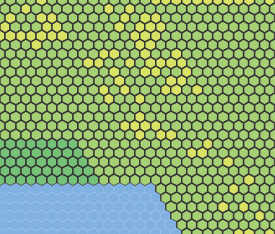

In [ ]:
#| export
def test_chunk_generation():
    """Test chunk generation with plate inheritance."""
    
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        
        gen = ChunkedTerrainGenerator(
            storage=storage,
            coarse_rings=15,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=10,
            halo_rings=3
        )
        
        # Generate coarse
        coarse = gen.generate_coarse(
            num_plates=8,
            ocean_fraction=0.3,
            oceanic_sides=['W'],
            name="chunk_test"
        )
        print(f"Coarse: {len(coarse.elevations)} hexes")
        
        # Generate chunk at origin
        chunk = gen.world_to_chunk_ref(HexPosition(0, 0, 0))
        print(f"Generating chunk at {chunk.position}...")
        
        chunk_terrain = gen.generate_chunk(chunk)
        
        print(f"✓ Chunk terrain: {len(chunk_terrain.elevations)} hexes")
        print(f"  Elevation range: {chunk_terrain.elevations.min():.0f} to {chunk_terrain.elevations.max():.0f}")
        
        # Verify plate_id inherited
        assert 'plate_id' in chunk_terrain.fields, "Missing plate_id in chunk"
        chunk_plates = set(int(p) for p in chunk_terrain.fields['plate_id'])
        print(f"  Plate IDs in chunk: {sorted(chunk_plates)}")
        
        # Land/ocean check
        land = sum(chunk_terrain.elevations > 0)
        ocean = sum(chunk_terrain.elevations <= 0)
        print(f"  Land: {land}, Ocean: {ocean}")
        
        # Visualize
        chunk_terrain.hexGrid.adjustRadius(6)
        chunk_terrain.colorMap()
        chunk_terrain.hexGrid.update()
        
        return coarse, chunk_terrain, gen

coarse, chunk, gen = test_chunk_generation()
chunk.hexGrid.builder.show()


In [ ]:
# Test 1: Does generate_coarse create plate_ids?
def test_coarse_has_plates():
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        gen = ChunkedTerrainGenerator(storage=storage, coarse_rings=10, 
                                       coarse_radius=50, fine_radius=10)
        
        coarse = gen.generate_coarse(num_plates=5, ocean_fraction=0.3)
        
        assert 'plate_id' in coarse.fields, "No plate_id field in coarse terrain"
        plates = set(int(p) for p in coarse.fields['plate_id'])
        print(f"✓ Coarse has {len(plates)} unique plates: {sorted(plates)}")
        
        # Check none are -1 (unassigned)
        unassigned = sum(coarse.fields['plate_id'] == -1)
        print(f"  Unassigned hexes: {unassigned}/{len(coarse.elevations)}")
        
        return gen, coarse

gen, coarse = test_coarse_has_plates()


✓ Coarse has 54 unique plates: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89]
  Unassigned hexes: 0/441
✓ Test database cleaned up


In [ ]:
# Test 2: Does save_world actually persist plate_id?
def test_save_preserves_plates():
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        gen = ChunkedTerrainGenerator(storage=storage, coarse_rings=10,
                                       coarse_radius=50, fine_radius=10)
        
        coarse = gen.generate_coarse(num_plates=5, ocean_fraction=0.3)
        world_id = gen.coarse_world_id
        
        # Query raw DB
        sample_rows = list(storage.db.execute(
            "SELECT q, r, s, plate_id FROM hex_data WHERE world_id = ? LIMIT 10",
            [world_id]
        ).fetchall())
        
        print("Raw DB rows (q, r, s, plate_id):")
        for row in sample_rows:
            print(f"  {row}")
        
        # Check for NULLs
        null_count = storage.db.execute(
            "SELECT COUNT(*) FROM hex_data WHERE world_id = ? AND plate_id IS NULL",
            [world_id]
        ).fetchone()[0]
        print(f"\n✓ Rows with NULL plate_id: {null_count}")
        
        return storage, world_id

storage, world_id = test_save_preserves_plates()


Raw DB rows (q, r, s, plate_id):
  (-5, -10, 15, 78)
  (-4, -10, 14, 78)
  (-3, -10, 13, 78)
  (-2, -10, 12, 78)
  (-1, -10, 11, 78)
  (0, -10, 10, 42)
  (1, -10, 9, 6)
  (2, -10, 8, 6)
  (3, -10, 7, 12)
  (4, -10, 6, 48)

✓ Rows with NULL plate_id: 0
✓ Test database cleaned up


In [ ]:
# Test 3: Does query_hexes_in_radius return plate_id correctly?
def test_query_returns_plates():
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        gen = ChunkedTerrainGenerator(storage=storage, coarse_rings=10,
                                       coarse_radius=50, fine_radius=10)
        
        coarse = gen.generate_coarse(num_plates=5, ocean_fraction=0.3)
        world_id = gen.coarse_world_id
        
        rows = storage.query_hexes_in_radius(world_id, 0, 0, 0, radius=3)
        
        print(f"Queried {len(rows)} hexes")
        print(f"Row keys: {list(rows[0].keys()) if rows else 'none'}")
        
        print("\nSample rows:")
        for row in rows[:5]:
            print(f"  q={row['q']}, r={row['r']}, s={row['s']}, plate_id={row.get('plate_id')}")
        
        # Check if any plate_id is None
        none_plates = sum(1 for row in rows if row.get('plate_id') is None)
        print(f"\n✓ Rows with None plate_id: {none_plates}/{len(rows)}")
        
        return storage, world_id, rows

storage, world_id, rows = test_query_returns_plates()


Queried 37 hexes
Row keys: ['id', 'world_id', 'q', 'r', 's', 'grid_index', 'elevation', 'plate_id', 'latitude', 'longitude', 'distance_from_coast', 'watershed_id', 'modified']

Sample rows:
  q=-3, r=0, s=3, plate_id=4
  q=-3, r=1, s=2, plate_id=4
  q=-3, r=2, s=1, plate_id=4
  q=-3, r=3, s=0, plate_id=4
  q=-2, r=-1, s=3, plate_id=4

✓ Rows with None plate_id: 0/37
✓ Test database cleaned up


In [ ]:
# Test 4: Does _query_chunk_plates build the lookup correctly?
def test_chunk_plates_lookup():
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        gen = ChunkedTerrainGenerator(storage=storage, coarse_rings=10,
                                       coarse_radius=50, fine_radius=10,
                                       chunk_rings=5, halo_rings=2)
        
        coarse = gen.generate_coarse(num_plates=5, ocean_fraction=0.3)
        
        chunk = gen.world_to_chunk_ref(HexPosition(0, 0, 0))
        chunk_plates = gen._query_chunk_plates(chunk)
        
        print(f"Plate IDs found: {sorted(chunk_plates.keys())}")
        print(f"Total rows across all plates: {sum(len(v) for v in chunk_plates.values())}")
        
        # Check a sample row
        for pid, rows in list(chunk_plates.items())[:2]:
            print(f"\nPlate {pid} has {len(rows)} rows, sample:")
            if rows:
                row = rows[0]
                print(f"  Keys: {list(row.keys())}")
                print(f"  plate_id value: {row.get('plate_id')}")
        
        return gen, chunk_plates

gen, chunk_plates = test_chunk_plates_lookup()


Plate IDs found: [2, 5, 11, 14, 50, 74, 87]
Total rows across all plates: 37

Plate 2 has 3 rows, sample:
  Keys: ['id', 'world_id', 'q', 'r', 's', 'grid_index', 'elevation', 'plate_id', 'latitude', 'longitude', 'distance_from_coast', 'watershed_id', 'modified']
  plate_id value: 2

Plate 14 has 14 rows, sample:
  Keys: ['id', 'world_id', 'q', 'r', 's', 'grid_index', 'elevation', 'plate_id', 'latitude', 'longitude', 'distance_from_coast', 'watershed_id', 'modified']
  plate_id value: 14
✓ Test database cleaned up


Coarse: 961 hexes, scale=5.0

--- Chunk at HexPosition(0, 0, 0) (from world HexPosition(0, 0, 0)) ---
  Chunk center hex: HexPosition(0, 0, 0)
  Hexes: 729
  Elevation: -53 to 208
  Plates: [2, 8, 14, 39, 41, 45, 50, 74, 80, 86]
  Land/Ocean: 721/8

--- Chunk at HexPosition(0, 0, 0) (from world HexPosition(1, -1, 0)) ---
  Chunk center hex: HexPosition(0, 0, 0)
  Hexes: 729
  Elevation: -53 to 208
  Plates: [2, 8, 14, 39, 41, 45, 50, 74, 80, 86]
  Land/Ocean: 721/8

--- Chunk at HexPosition(0, 0, 0) (from world HexPosition(2, -1, -1)) ---
  Chunk center hex: HexPosition(0, 0, 0)
  Hexes: 729
  Elevation: -53 to 208
  Plates: [2, 8, 14, 39, 41, 45, 50, 74, 80, 86]
  Land/Ocean: 721/8

--- Chunk at HexPosition(0, 0, 0) (from world HexPosition(-1, 1, 0)) ---
  Chunk center hex: HexPosition(0, 0, 0)
  Hexes: 729
  Elevation: -53 to 208
  Plates: [2, 8, 14, 39, 41, 45, 50, 74, 80, 86]
  Land/Ocean: 721/8
✓ Test database cleaned up

=== Coarse Overview ===


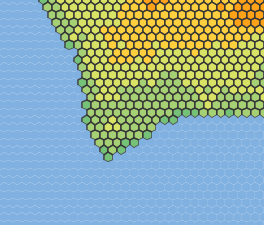

None


=== Chunk HexPosition(0, 0, 0) ===


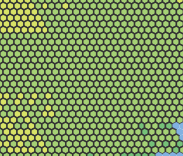

None


=== Chunk HexPosition(0, 0, 0) ===


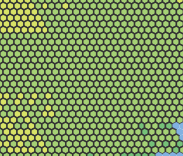

None


=== Chunk HexPosition(0, 0, 0) ===


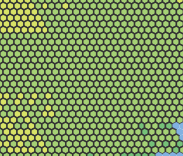

None


=== Chunk HexPosition(0, 0, 0) ===


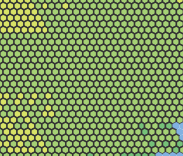

None

In [ ]:
def test_offcenter_chunks():
    """Test chunk generation at various positions."""
    
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        
        gen = ChunkedTerrainGenerator(
            storage=storage,
            coarse_rings=15,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=10,
            halo_rings=3
        )
        
        # Generate coarse
        coarse = gen.generate_coarse(
            num_plates=8,
            ocean_fraction=0.3,
            oceanic_sides=['W'],
            name="offcenter_test"
        )
        print(f"Coarse: {len(coarse.elevations)} hexes, scale={gen.scale}")
        
        # Test chunks at different positions
        test_positions = [
            HexPosition(0, 0, 0),    # Origin
            HexPosition(1, -1, 0),   # Adjacent chunk
            HexPosition(2, -1, -1),  # Further out
            HexPosition(-1, 1, 0),   # Negative direction (toward ocean)
        ]
        
        results = []
        for world_pos in test_positions:
            chunk = gen.world_to_chunk_ref(world_pos)
            print(f"\n--- Chunk at {chunk.position} (from world {world_pos}) ---")
            print(f"  Chunk center hex: {chunk.center_hex}")
            
            chunk_terrain = gen.generate_chunk(chunk)
            
            plates = set(int(p) for p in chunk_terrain.fields['plate_id'])
            land = sum(chunk_terrain.elevations > 0)
            ocean = sum(chunk_terrain.elevations <= 0)
            
            print(f"  Hexes: {len(chunk_terrain.elevations)}")
            print(f"  Elevation: {chunk_terrain.elevations.min():.0f} to {chunk_terrain.elevations.max():.0f}")
            print(f"  Plates: {sorted(plates)}")
            print(f"  Land/Ocean: {land}/{ocean}")
            
            results.append((chunk, chunk_terrain))
        
        return coarse, results, gen

coarse, results, gen = test_offcenter_chunks()

# Show coarse for reference
print("\n=== Coarse Overview ===")
coarse.hexGrid.adjustRadius(5)
coarse.colorMap()
coarse.hexGrid.update()
display(coarse.hexGrid.builder.show())

# Show each chunk
for chunk, terrain in results:
    print(f"\n=== Chunk {chunk.position} ===")
    terrain.hexGrid.adjustRadius(4)
    terrain.colorMap()
    terrain.hexGrid.update()
    display(terrain.hexGrid.builder.show())


Coarse: 1681 hexes
Generating chunk at HexPosition(0, 0, 0, 'origin'), center_hex=HexPosition(0, 0, 0)
Generating chunk at HexPosition(1, 0, -1), center_hex=HexPosition(16, 0, -16)
Generating chunk at HexPosition(0, 1, -1), center_hex=HexPosition(0, 16, -16)
Generating chunk at HexPosition(-1, 1, 0), center_hex=HexPosition(-16, 16, 0)
Generating chunk at HexPosition(-1, 0, 1), center_hex=HexPosition(-16, 0, 16)
Generating chunk at HexPosition(0, -1, 1), center_hex=HexPosition(0, -16, 16)
Generating chunk at HexPosition(1, -1, 0), center_hex=HexPosition(16, -16, 0)

Generated 7 chunks

=== Boundary Verification ===
Checked 470 overlapping hexes
Mismatches: 0

=== Chunk Summary ===
  HexPosition(0, 0, 0, 'origin'): land=441, ocean=0, plates=4
  HexPosition(1, 0, -1): land=441, ocean=0, plates=2
  HexPosition(0, 1, -1): land=441, ocean=0, plates=5
  HexPosition(-1, 1, 0): land=441, ocean=0, plates=4
  HexPosition(-1, 0, 1): land=441, ocean=0, plates=3
  HexPosition(0, -1, 1): land=441, oc

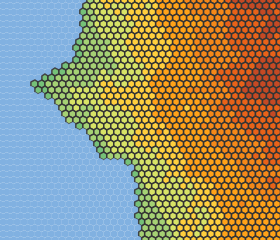

None


=== Center Chunk ===


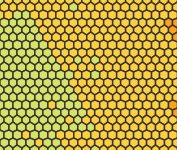

None


=== Neighbor Chunk (1,-1,0) ===


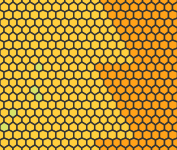

None

In [ ]:
def test_chunk_tiling():
    """Test that adjacent chunks tile correctly at boundaries."""
    
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        
        gen = ChunkedTerrainGenerator(
            storage=storage,
            coarse_rings=20,       # Larger coarse for more coverage
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=8,         # Smaller chunks to see more of them
            halo_rings=2
        )
        
        # Generate coarse
        coarse = gen.generate_coarse(
            num_plates=10,
            ocean_fraction=0.3,
            oceanic_sides=['W'],
            name="tiling_test"
        )
        print(f"Coarse: {len(coarse.elevations)} hexes")
        
        # Generate center chunk + ring 1 (7 chunks total)
        chunks = {}
        for ring in range(2):  # Ring 0 and 1
            for pos in HexPosition.origin().ring(ring) if ring > 0 else [HexPosition.origin()]:
                chunk_ref = ChunkRef(pos, gen.chunk_rings)
                print(f"Generating chunk at {pos}, center_hex={chunk_ref.center_hex}")
                chunks[pos] = gen.generate_chunk(chunk_ref)
        
        print(f"\nGenerated {len(chunks)} chunks")
        
        # Verify boundary alignment between adjacent chunks
        print("\n=== Boundary Verification ===")
        center_chunk = chunks[HexPosition(0, 0, 0)]
        center_grid = center_chunk.hexGrid
        
        errors = []
        checks = 0
        
        for neighbor_pos in HexPosition.origin().ring(1):
            if neighbor_pos not in chunks:
                continue
            
            neighbor_chunk = chunks[neighbor_pos]
            neighbor_grid = neighbor_chunk.hexGrid
            neighbor_ref = ChunkRef(neighbor_pos, gen.chunk_rings)
            center_ref = ChunkRef(HexPosition(0,0,0), gen.chunk_rings)
            
            # Find hexes that should have same world position
            # Check boundary hexes of center chunk toward this neighbor
            for center_idx in range(len(center_grid.hexes)):
                center_local = center_grid.index_to_hexposition(center_idx, origin_index=center_grid.midpoint)
                center_world = center_ref.center_hex + center_local
                
                # What would this be in neighbor's local coords?
                neighbor_local = center_world - neighbor_ref.center_hex
                neighbor_idx = neighbor_grid.hexposition_to_index(neighbor_local, origin_index=neighbor_grid.midpoint)
                
                if 0 <= neighbor_idx < len(neighbor_chunk.elevations):
                    # Both chunks have this world position - elevations should match
                    center_elev = center_chunk.elevations[center_idx]
                    neighbor_elev = neighbor_chunk.elevations[neighbor_idx]
                    
                    checks += 1
                    if abs(center_elev - neighbor_elev) > 0.01:  # Allow tiny float diff
                        errors.append({
                            'world': center_world,
                            'center_elev': center_elev,
                            'neighbor_elev': neighbor_elev,
                            'neighbor_pos': neighbor_pos
                        })
        
        print(f"Checked {checks} overlapping hexes")
        print(f"Mismatches: {len(errors)}")
        
        if errors[:5]:
            print("Sample errors:")
            for e in errors[:5]:
                print(f"  World {e['world']}: center={e['center_elev']:.1f}, neighbor={e['neighbor_elev']:.1f}")
        
        # Summary stats
        print("\n=== Chunk Summary ===")
        for pos, terrain in chunks.items():
            land = sum(terrain.elevations > 0)
            ocean = len(terrain.elevations) - land
            plates = len(set(int(p) for p in terrain.fields['plate_id']))
            print(f"  {pos}: land={land}, ocean={ocean}, plates={plates}")
        
        return coarse, chunks, gen, errors

coarse, chunks, gen, errors = test_chunk_tiling()

# Visualize coarse
print("\n=== Coarse Map ===")
coarse.hexGrid.adjustRadius(4)
coarse.colorMap()
coarse.hexGrid.update()
display(coarse.hexGrid.builder.show())

# Visualize center and one neighbor side by side
print("\n=== Center Chunk ===")
center = chunks[HexPosition(0,0,0)]
center.hexGrid.adjustRadius(5)
center.colorMap()
center.hexGrid.update()
display(center.hexGrid.builder.show())

print("\n=== Neighbor Chunk (1,-1,0) ===")
if HexPosition(1,-1,0) in chunks:
    neighbor = chunks[HexPosition(1,-1,0)]
    neighbor.hexGrid.adjustRadius(5)
    neighbor.colorMap()
    neighbor.hexGrid.update()
    display(neighbor.hexGrid.builder.show())


def test_chunk_overlay():
    """Test projecting chunk back onto coarse map."""
    
    with GeoStorageDebugger(keep_on_error=True) as debugger:
        storage = debugger.server
        
        gen = ChunkedTerrainGenerator(
            storage=storage,
            coarse_rings=15,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=8,
            halo_rings=2
        )
        
        coarse = gen.generate_coarse(
            num_plates=8,
            ocean_fraction=0.3,
            oceanic_sides=['W'],
            name="overlay_test"
        )
        
        # Generate a chunk
        chunk_ref = ChunkRef(HexPosition(1, -1, 0), gen.chunk_rings)
        chunk_terrain = gen.generate_chunk(chunk_ref)
        
        # Get the footprint region
        footprint = gen.chunk_to_coarse_region(chunk_ref)
       # print(f"Chunk footprint covers {len(footprint.hexes)} coarse hexes")
        
        # Get overlay with aggregated data
        overlay = gen.overlay_chunk_on_coarse(chunk_ref, chunk_terrain)
        print(f"Overlay mapped {len(overlay.aggregated_elevations)} hexes")
        print(f"Fine hexes per coarse: {list(overlay.fine_counts.values())[:5]}...")
        
        # Visualize: coarse with chunk region highlighted
        coarse.hexGrid.adjustRadius(5)
        coarse.colorMap()
        
        # Add region outline
        highlight = StyleCSS("highlight",fill="none", stroke="red", stroke_width=3)
        edge_path = unique_windy_edge(footprint)
        coarse.hexGrid.builder.add_path(edge_path, highlight)
        
        coarse.hexGrid.update()
        return coarse, chunk_terrain, footprint, overlay, gen

coarse, chunk, footprint, overlay, gen = test_chunk_overlay()
display(coarse.hexGrid.builder.show())

# Show chunk for comparison
chunk.hexGrid.adjustRadius(4)
chunk.colorMap()
chunk.hexGrid.update()
display(chunk.hexGrid.builder.show())


## Visualize what we are doing

In [ ]:
#| export
@patch
def visualize_chunks_on_coarse(gen:ChunkedTerrainGenerator, coarse, max_chunks=9):
    """Overlay chunk boundaries and IDs on coarse terrain."""
    
    coarse_grid = coarse.hexGrid
    builder = coarse.hexGrid.builder
    
    # Use seaborn palette
    chunk_styles = StyleCSS.seaborn("Set2", max_chunks)
    
    overlay = ""
    chunk_id = 0
    spacing = 2 * gen.chunk_rings
    
    # Track which chunks we actually render for the legend
    rendered_chunks = []
    
    for ring in range(3):
        positions = [HexPosition.origin()] if ring == 0 else HexPosition.origin().ring(ring)
        
        for chunk_pos in positions:
            if chunk_id >= max_chunks:
                break
            
            world_center = HexPosition(
                chunk_pos.q * spacing,
                chunk_pos.r * spacing,
                chunk_pos.s * spacing
            )
            
            coarse_center = HexPosition(
                int(round(world_center.q / gen.scale)),
                int(round(world_center.r / gen.scale)),
                int(round(world_center.s / gen.scale))
            )
            
            coarse_radius = int(math.ceil((gen.chunk_rings + gen.halo_rings) / gen.scale))
            
            center_idx = coarse_grid.hexposition_to_index(coarse_center)
            if center_idx < 0 or center_idx >= len(coarse.elevations):
                continue
            
            chunk_hexes = set()
            for r in range(coarse_radius + 1):
                ring_hexes = coarse.ring(center_idx, r) if r > 0 else [center_idx]
                for h in ring_hexes:
                    if 0 <= h < len(coarse.elevations):
                        chunk_hexes.add(h)
            
            if not chunk_hexes:
                continue
            
            region = HexRegion(hexes=chunk_hexes, hexGrid=coarse_grid)
            base_color = chunk_styles[chunk_id].properties["fill"]
            
            chunk_style = StyleCSS(f"chunk_{chunk_id}", 
                                   fill=base_color, 
                                   opacity=0.6, 
                                   stroke=base_color,
                                   stroke_width=2)
            builder.add_style(chunk_style)
            
            overlay += region.draw(style=chunk_style, inset=0.1)
            
            centroid_idx = region.centroid_hex()
            if centroid_idx is not None and centroid_idx < len(coarse_grid.hexes):
                center_hex = coarse_grid.hexes[centroid_idx]
                overlay += f'<text x="{center_hex.center.x}" y="{center_hex.center.y + 20}" '
                overlay += f'text-anchor="middle" font-size="10" font-weight="bold" '
                overlay += f'fill="{base_color}">Chunk {chunk_id}</text>\n'
            
            # Track for legend
            rendered_chunks.append((f"Chunk {chunk_id}", base_color))
            chunk_id += 1
    
    # Add legend below
        # Add legend below
    #legend = [StyleCSS(name, fill=color, opacity=0.3) for name, color in rendered_chunks]
    #builder.adjust("legend", builder.legendBelow(legend, use_hex=True))

    
        # Add legend below
    

        # Add legend below
    legend = [StyleCSS(name.replace(" ", "_"), fill=color) for name, color in rendered_chunks]
    for style in legend:
        builder.add_style(style)
    builder.adjust("legend", builder.legendBelow(legend, use_hex=True))

    
    return overlay

Chunky


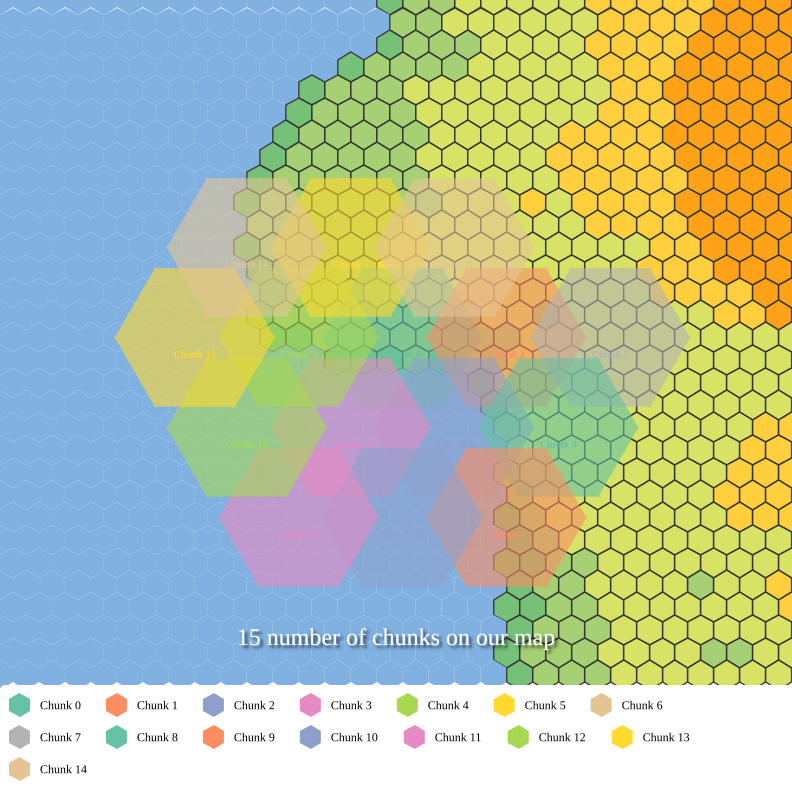

✓ Test database cleaned up


In [ ]:
with GeoStorageDebugger(keep_on_error=True) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,      # World extends 15 hexes from center
        coarse_radius=50,     # Each coarse hex = 50m
        fine_radius=10,       # Each fine hex = 10m
        chunk_rings=10,       # Chunk core = 10 hexes from center
        halo_rings=3          # 3 extra rings of overlap
    )
    
    # Generate the coarse world - this is the "whole map"
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.3,
        oceanic_sides=['W'],
        name="tutorial_world",
        seed=14
    )
    max_chunks=15
    coarse.hexGrid.adjustRadius(15)
    coarse.colorMap()
    coarse.hexGrid.update()
    textStyle = StyleCSS("textStyle",fill="white",font_size="2em",filter=" drop-shadow( 3px 3px 2px rgba(0, 0, 0, .7))")
    coarse.hexGrid.builder.add_style(textStyle)
    print(f"Chunky")
    coarse.hexGrid.builder.add_centered_text(f"{max_chunks} number of chunks on our map", 
        y_offset=coarse.hexGrid.builder.height/2 - 30,
        class_name=textStyle.name
    )
    chunk_overlay = gen.visualize_chunks_on_coarse( coarse, max_chunks=max_chunks)
    coarse.hexGrid.builder.adjust("chunks", chunk_overlay)
    coarse.hexGrid.builder.show()


=== Chunk 8 at HexPosition(1, 1, -2) ===
  Land: 719, Ocean: 10


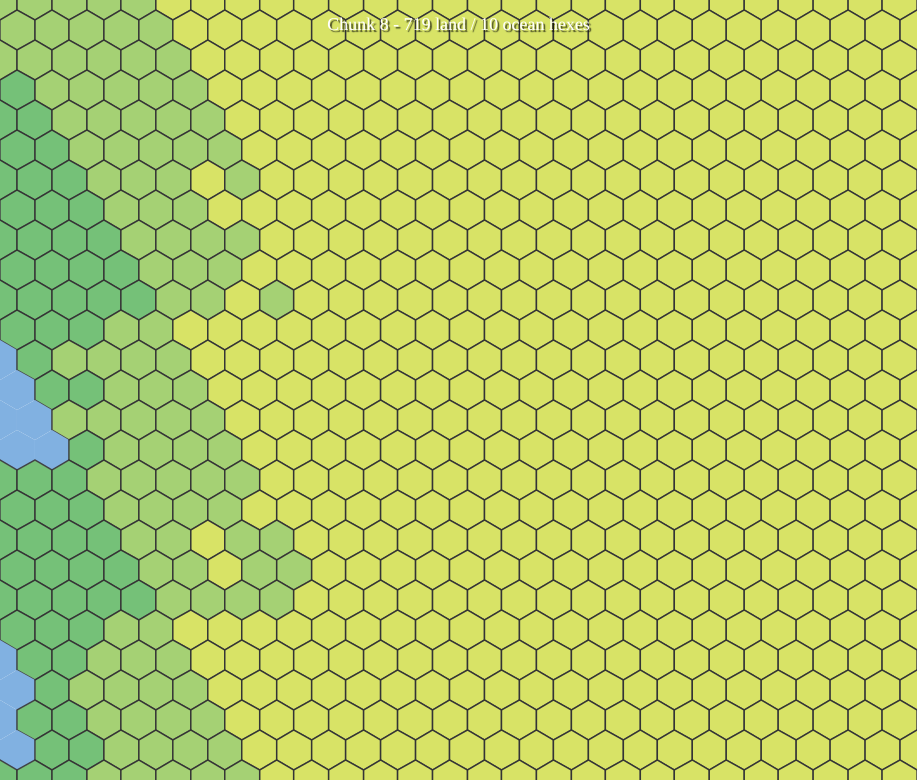

None


=== Chunk 9 at HexPosition(0, 2, -2) ===
  Land: 406, Ocean: 323


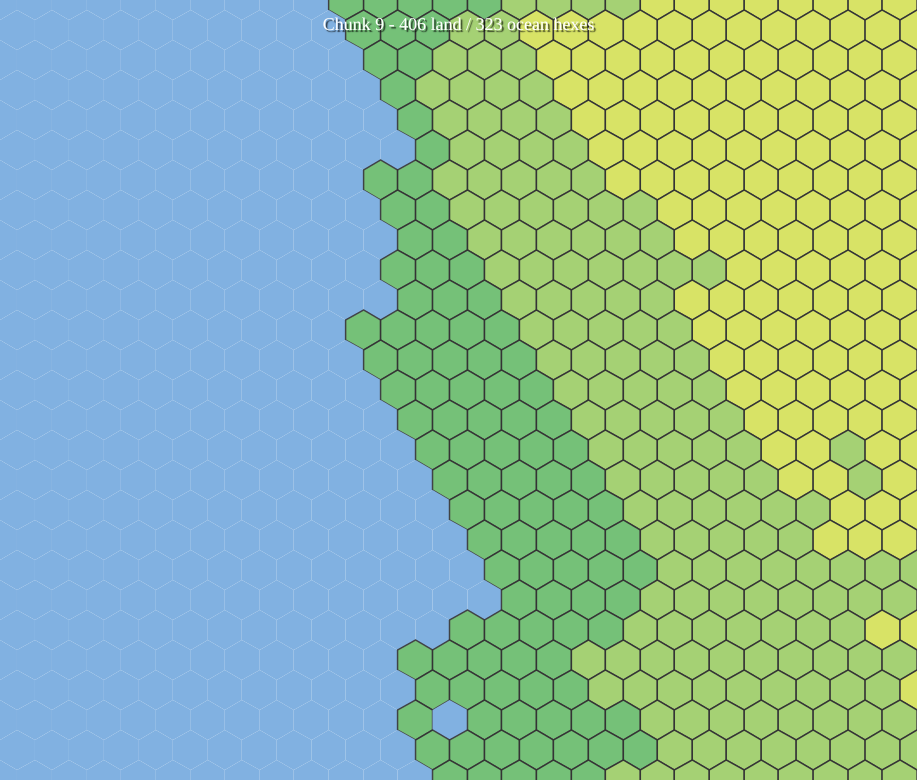

None

✓ Test database cleaned up


In [ ]:
with GeoStorageDebugger(keep_on_error=True) as debugger:
    storage = debugger.server
    
    gen = ChunkedTerrainGenerator(
        storage=storage,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=10,
        halo_rings=3
    )
    
    coarse = gen.generate_coarse(
        num_plates=8,
        ocean_fraction=0.3,
        oceanic_sides=['W'],
        name="tutorial_world",
        seed=14
    )
    
    # Chunk positions follow the ring spiral pattern
    # Ring 0: chunk 0 (origin)
    # Ring 1: chunks 1-6
    # Ring 2: chunks 7-18
    spacing = 2 * gen.chunk_rings
    
    # Get chunk positions for 8 and 9 (ring 2)
    ring2_positions = list(HexPosition.origin().ring(2))
    chunk8_pos = ring2_positions[1]  # 2nd position in ring 2
    chunk9_pos = ring2_positions[2]  # 3rd position in ring 2
    
    for chunk_id, chunk_pos in [(8, chunk8_pos), (9, chunk9_pos)]:
        world_center = HexPosition(
            chunk_pos.q * spacing,
            chunk_pos.r * spacing,
            chunk_pos.s * spacing
        )
        chunk_ref = gen.world_to_chunk_ref(world_center)
        
        print(f"\n=== Chunk {chunk_id} at {chunk_ref.position} ===")
        chunk_terrain = gen.generate_chunk(chunk_ref)
        
        land = sum(chunk_terrain.elevations > 0)
        ocean = sum(chunk_terrain.elevations <= 0)
        print(f"  Land: {land}, Ocean: {ocean}")
        
        chunk_terrain.hexGrid.adjustRadius(20)
        chunk_terrain.colorMap()
        chunk_terrain.hexGrid.update()
        
        textStyle = StyleCSS("textStyle", fill="white", font_size="1.5em", 
                             filter="drop-shadow(2px 2px 1px rgba(0,0,0,.7))")
        chunk_terrain.hexGrid.builder.add_style(textStyle)
        chunk_terrain.hexGrid.builder.add_centered_text(
            f"Chunk {chunk_id} - {land} land / {ocean} ocean hexes",
            y_offset=-chunk_terrain.hexGrid.builder.height/2 + 30,
            class_name=textStyle.name
        )
        display(chunk_terrain.hexGrid.builder.show())


# Two things
## being able to call carve_chunk_to_ocean on a detail

and equally important 

## Aliasing Issue in Chunk Generation

### The Problem
When generating fine-resolution chunks from coarse terrain, we use **nearest-neighbor sampling**:

```python
coarse_q = int(round(world_pos.q / gen.scale))
```

This means every fine hex simply copies the elevation of its closest coarse parent. With a scale factor of 5.0 (coarse_radius=50, fine_radius=10), each coarse hex covers ~25 fine hexes, all of which get identical elevation values.

**Result**: Blocky "stair-step" plateaus with sharp boundaries at coarse hex edges.

### Where It Happens
In `ChunkedTerrainGenerator._build_chunk_terrain()`:

```python
if coarse_key in coarse_lookup:
    # Direct copy - no interpolation!
    terrain.elevations[fine_idx] = data['elevation']
```

The existing `_interpolate_from_coarse()` method only runs as a fallback when a coarse hex is missing from the lookup (edge cases), not during normal sampling.

### Current Mitigation
The `_add_detail()` method applies per-hex noise seeded by world position:
- Adds ±10% of `elevationDelta` as random variation
- Helps break up the visual uniformity
- But doesn't address the underlying stair-step structure

### Proper Fix
Replace nearest-neighbor with **distance-weighted interpolation**:

1. For each fine hex, find the 3-4 nearest coarse hexes
2. Compute inverse-distance weights
3. Blend elevations smoothly across coarse boundaries
4. Use voting or dominant-weight for discrete fields like `plate_id`

This would create smooth gradients instead of sharp steps, with the detail noise adding natural micro-variation on top.

### Trade-offs
- **Nearest-neighbor**: Fast, preserves exact coarse values, but visually blocky
- **Interpolation**: Smoother, more natural, but slightly more expensive and "invents" intermediate values not in original data
```

Lets figure how how to refactor things. I am trying to build through the stages of showing how algorithms work per above and then I hit the anti aliasing problem; I do think that there must be something we could do using hexpostions and cubecoordinates for rings around hexes to make this work. Your thoughts on how to proceed.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good instinct! Hex cube coordinates naturally support distance-weighted interpolation. Here's the approach:

### The Math: Fractional Coarse Coordinates

The key insight is that a fine hex's world position maps to a **fractional** coarse position, not just a rounded integer:

```python
frac_q = world_pos.q / scale  # e.g., 7/5 = 1.4
frac_r = world_pos.r / scale  # e.g., -3/5 = -0.6
frac_s = -frac_q - frac_r     # cube constraint still holds
```

The fractional position tells us "how far between coarse hexes" we are.

### Distance-Weighted Interpolation

```python
@patch
def _interpolate_elevation(self: ChunkedTerrainGenerator, 
                           world_pos: HexPosition, 
                           coarse_lookup: dict) -> tuple[float, int]:
    """Interpolate elevation using distance-weighted average of nearby coarse hexes."""
    scale = self.scale
    
    # Fractional coarse coordinates
    frac_q = world_pos.q / scale
    frac_r = world_pos.r / scale
    frac_s = -frac_q - frac_r
    
    # Nearest coarse hex center
    near_q = int(round(frac_q))
    near_r = int(round(frac_r))
    near_s = -near_q - near_r
    center = HexPosition(near_q, near_r, near_s)
    
    # Sample center + ring-1 neighbors (7 hexes)
    candidates = [center] + list(center.ring(1))
    
    weights = []
    elevations = []
    plate_weights = {}  # plate_id -> cumulative weight
    
    for cpos in candidates:
        key = (cpos.q, cpos.r, cpos.s)
        if key not in coarse_lookup:
            continue
        
        # Cube distance from fractional position to this coarse center
        dq = cpos.q - frac_q
        dr = cpos.r - frac_r
        ds = cpos.s - frac_s
        dist = (abs(dq) + abs(dr) + abs(ds)) / 2  # hex distance formula
        
        # Inverse distance weight (epsilon prevents div/0 at exact center)
        w = 1.0 / (dist + 0.1)
        weights.append(w)
        elevations.append(coarse_lookup[key]['elevation'])
        
        # Accumulate plate weights for voting
        pid = coarse_lookup[key]['plate_id']
        plate_weights[pid] = plate_weights.get(pid, 0) + w
    
    if not weights:
        return 0.0, -1
    
    # Weighted average for elevation (continuous)
    total_weight = sum(weights)
    interp_elev = sum(w * e for w, e in zip(weights, elevations)) / total_weight
    
    # Weighted voting for plate_id (discrete)
    best_plate = max(plate_weights, key=plate_weights.get)
    
    return interp_elev, best_plate
```

### Refactored `_build_chunk_terrain`

```python
@patch
def _build_chunk_terrain(self: ChunkedTerrainGenerator, 
                          fine_grid: HexGrid, 
                          chunk: ChunkRef,
                          chunk_plates: dict) -> Terrain:
    """Build fine terrain with smooth interpolation from coarse."""
    coarse = self._coarse_terrain
    
    # ... (terrain setup code unchanged) ...
    
    # Build coarse lookup
    coarse_lookup = {}
    for pid, rows in chunk_plates.items():
        for row in rows:
            key = (row['q'], row['r'], row['s'])
            coarse_lookup[key] = {
                'elevation': row['elevation'],
                'plate_id': pid,
            }
    
    # Sample each fine hex with interpolation
    for fine_idx in range(len(fine_grid.hexes)):
        fine_pos = fine_grid.index_to_hexposition(fine_idx, origin_index=fine_grid.midpoint)
        world_pos = chunk.center_hex + fine_pos
        
        # Interpolated values (smooth!)
        elevation, plate_id = self._interpolate_elevation(world_pos, coarse_lookup)
        
        terrain.elevations[fine_idx] = elevation
        terrain.fields['plate_id'][fine_idx] = plate_id
    
    # Detail noise on top of smooth base
    self._add_detail(terrain, chunk)
    
    return terrain
```

### Teaching Progression

1. **Stage 1 - Nearest Neighbor**: Show the blocky result (current code)
2. **Stage 2 - Distance Interpolation**: Add the interpolation method, show smooth gradients
3. **Stage 3 - Detail Noise**: Add micro-variation for natural appearance
4. **Stage 4 - Drainage**: Run `carve_chunk_to_ocean` on the smooth terrain

Want me to write the full refactored `_build_chunk_terrain` with a toggle between nearest/interpolated for side-by-side comparison?

## Debugger

#| export
Are there tests we should add as patches to GeoStorageDebugger


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Looking at your test patterns, here are some useful patches for `GeoStorageDebugger`:

```python
@patch
def verify_chunk_boundaries(self: GeoStorageDebugger, 
                            gen: ChunkedTerrainGenerator,
                            chunks: dict) -> dict:
    """Verify adjacent chunks have matching elevations at overlapping hexes."""
    errors = []
    checks = 0
    
    for pos, terrain in chunks.items():
        chunk_ref = ChunkRef(pos, gen.chunk_rings)
        grid = terrain.hexGrid
        
        for neighbor_pos in pos.ring(1):
            if neighbor_pos not in chunks:
                continue
            neighbor = chunks[neighbor_pos]
            neighbor_ref = ChunkRef(neighbor_pos, gen.chunk_rings)
            neighbor_grid = neighbor.hexGrid
            
            for idx in range(len(grid.hexes)):
                local = grid.index_to_hexposition(idx, origin_index=grid.midpoint)
                world = chunk_ref.center_hex + local
                
                neighbor_local = world - neighbor_ref.center_hex
                neighbor_idx = neighbor_grid.hexposition_to_index(neighbor_local, origin_index=neighbor_grid.midpoint)
                
                if 0 <= neighbor_idx < len(neighbor.elevations):
                    checks += 1
                    if abs(terrain.elevations[idx] - neighbor.elevations[neighbor_idx]) > 0.01:
                        errors.append((world, terrain.elevations[idx], neighbor.elevations[neighbor_idx]))
    
    return {'checks': checks, 'errors': errors, 'ok': len(errors) == 0}


@patch
def verify_plate_inheritance(self: GeoStorageDebugger,
                              gen: ChunkedTerrainGenerator,
                              chunk: ChunkRef,
                              chunk_terrain: Terrain) -> dict:
    """Verify chunk plate_ids match coarse parent hexes."""
    coarse = gen._coarse_terrain
    coarse_grid = coarse.hexGrid
    mismatches = []
    
    for idx in range(len(chunk_terrain.hexGrid.hexes)):
        local = chunk_terrain.hexGrid.index_to_hexposition(idx, origin_index=chunk_terrain.hexGrid.midpoint)
        world = chunk.center_hex + local
        
        coarse_q = int(round(world.q / gen.scale))
        coarse_r = int(round(world.r / gen.scale))
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
        
        if 0 <= coarse_idx < len(coarse.fields.get('plate_id', [])):
            coarse_plate = int(coarse.fields['plate_id'][coarse_idx])
            chunk_plate = int(chunk_terrain.fields['plate_id'][idx])
            if coarse_plate != chunk_plate:
                mismatches.append((world, coarse_plate, chunk_plate))
    
    return {'total': len(chunk_terrain.elevations), 'mismatches': len(mismatches), 'samples': mismatches[:5]}


@patch  
def summarize_chunks(self: GeoStorageDebugger, chunks: dict) -> None:
    """Print summary stats for a dict of chunks."""
    print(f"{'Position':<25} {'Hexes':>6} {'Land':>6} {'Ocean':>6} {'Plates':>7} {'Elev Range':>15}")
    print("-" * 70)
    for pos, t in chunks.items():
        land = sum(t.elevations > 0)
        ocean = len(t.elevations) - land
        plates = len(set(int(p) for p in t.fields.get('plate_id', [0])))
        elev = f"{t.elevations.min():.0f} to {t.elevations.max():.0f}"
        print(f"{str(pos):<25} {len(t.elevations):>6} {land:>6} {ocean:>6} {plates:>7} {elev:>15}")
```

These give you:
1. **Boundary verification** as a reusable method (not just inline in tests)
2. **Plate inheritance checking** to catch scale/rounding bugs
3. **Quick summary table** for eyeballing chunk batches

In [ ]:
#| export
@patch
def verify_chunk_boundaries(self: GeoStorageDebugger, 
                            gen: ChunkedTerrainGenerator,
                            chunks: dict) -> dict:
    """Verify adjacent chunks have matching elevations at overlapping hexes."""
    errors = []
    checks = 0
    
    for pos, terrain in chunks.items():
        chunk_ref = ChunkRef(pos, gen.chunk_rings)
        grid = terrain.hexGrid
        
        for neighbor_pos in pos.ring(1):
            if neighbor_pos not in chunks:
                continue
            neighbor = chunks[neighbor_pos]
            neighbor_ref = ChunkRef(neighbor_pos, gen.chunk_rings)
            neighbor_grid = neighbor.hexGrid
            
            for idx in range(len(grid.hexes)):
                local = grid.index_to_hexposition(idx, origin_index=grid.midpoint)
                world = chunk_ref.center_hex + local
                
                neighbor_local = world - neighbor_ref.center_hex
                neighbor_idx = neighbor_grid.hexposition_to_index(neighbor_local, origin_index=neighbor_grid.midpoint)
                
                if 0 <= neighbor_idx < len(neighbor.elevations):
                    checks += 1
                    if abs(terrain.elevations[idx] - neighbor.elevations[neighbor_idx]) > 0.01:
                        errors.append((world, terrain.elevations[idx], neighbor.elevations[neighbor_idx]))
    
    return {'checks': checks, 'errors': errors, 'ok': len(errors) == 0}


@patch
def verify_plate_inheritance(self: GeoStorageDebugger,
                              gen: ChunkedTerrainGenerator,
                              chunk: ChunkRef,
                              chunk_terrain: Terrain) -> dict:
    """Verify chunk plate_ids match coarse parent hexes."""
    coarse = gen._coarse_terrain
    coarse_grid = coarse.hexGrid
    mismatches = []
    
    for idx in range(len(chunk_terrain.hexGrid.hexes)):
        local = chunk_terrain.hexGrid.index_to_hexposition(idx, origin_index=chunk_terrain.hexGrid.midpoint)
        world = chunk.center_hex + local
        
        coarse_q = int(round(world.q / gen.scale))
        coarse_r = int(round(world.r / gen.scale))
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
        
        if 0 <= coarse_idx < len(coarse.fields.get('plate_id', [])):
            coarse_plate = int(coarse.fields['plate_id'][coarse_idx])
            chunk_plate = int(chunk_terrain.fields['plate_id'][idx])
            if coarse_plate != chunk_plate:
                mismatches.append((world, coarse_plate, chunk_plate))
    
    return {'total': len(chunk_terrain.elevations), 'mismatches': len(mismatches), 'samples': mismatches[:5]}


@patch  
def summarize_chunks(self: GeoStorageDebugger, chunks: dict) -> None:
    """Print summary stats for a dict of chunks."""
    print(f"{'Position':<25} {'Hexes':>6} {'Land':>6} {'Ocean':>6} {'Plates':>7} {'Elev Range':>15}")
    print("-" * 70)
    for pos, t in chunks.items():
        land = sum(t.elevations > 0)
        ocean = len(t.elevations) - land
        plates = len(set(int(p) for p in t.fields.get('plate_id', [0])))
        elev = f"{t.elevations.min():.0f} to {t.elevations.max():.0f}"
        print(f"{str(pos):<25} {len(t.elevations):>6} {land:>6} {ocean:>6} {plates:>7} {elev:>15}")


## Run it

In [ ]:
with GeoStorageDebugger(keep_on_error=False) as dbg:
    # Set up generator
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    # Generate coarse
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Generate some chunks
    chunks = {}
    for ring in range(2):
        for pos in HexPosition.origin().ring(ring) if ring > 0 else [HexPosition.origin()]:
            chunk_ref = ChunkRef(pos, gen.chunk_rings)
            chunks[pos] = gen.generate_chunk(chunk_ref)
    
    # Now run verifications
    print("=== Boundary Check ===")
    result = dbg.verify_chunk_boundaries(gen, chunks)
    print(f"Checks: {result['checks']}, Errors: {len(result['errors'])}, OK: {result['ok']}")
    
    print("\n=== Plate Inheritance ===")
    chunk_ref = ChunkRef(HexPosition(0,0,0), gen.chunk_rings)
    plate_result = dbg.verify_plate_inheritance(gen, chunk_ref, chunks[HexPosition(0,0,0)])
    print(f"Total: {plate_result['total']}, Mismatches: {plate_result['mismatches']}")
    
    print("\n=== Summary ===")
    dbg.summarize_chunks(chunks)


=== Boundary Check ===
Checks: 1880, Errors: 0, OK: True

=== Plate Inheritance ===
Total: 441, Mismatches: 0

=== Summary ===
Position                   Hexes   Land  Ocean  Plates      Elev Range
----------------------------------------------------------------------
HexPosition(0, 0, 0, 'origin')    441    324    117       7      -89 to 186
HexPosition(1, 0, -1)        441    376     65       6      -89 to 202
HexPosition(0, 1, -1)        441    109    332       3     -100 to 169
HexPosition(-1, 1, 0)        441     42    399       3     -106 to 126
HexPosition(-1, 0, 1)        441    403     38       5      -50 to 184
HexPosition(0, -1, 1)        441    441      0       6      120 to 200
HexPosition(1, -1, 0)        441    441      0       7       78 to 199
✓ Test database cleaned up


## algorithms

Hmm back to my pondering. Is there anything like https://observablehq.com/@nrabinowitz/h3-pathfinding or https://www.redblobgames.com/pathfinding/a-star/introduction.html that would work. I sort of like upsampling to get a general route and then downsample as needed to get specific hexes on smaller maps that you connect. It might not be fully optimal, but probably pretty good. Is there anything we could do for the database that would help.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Your intuition is solid—hierarchical pathfinding (coarse first, refine locally) is a well-established approach. Red Blob Games calls it "HPA*" (Hierarchical Pathfinding A*).

For database support, a few things could help:

1. **Chunk adjacency table** — precompute which chunks neighbor which, so coarse pathfinding can query neighbors without geometry math

2. **Border hex table** — store the hexes at chunk edges with their world coordinates, so you can quickly find where to "hand off" between chunks

3. **Precomputed costs** — for each chunk, store min/max traversal cost (or average). This lets the coarse A* heuristic be more accurate.

Which of these feels most useful for your use case? Or would you rather sketch out the pathfinding algorithm first and let the schema follow from that?

#| export
and how would you update llms.txt



##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Here's an `llms.txt` section for the chunked terrain system:

```markdown
## ChunkedTerrainGenerator

Multi-resolution hex terrain using coarse-to-fine generation with plate inheritance.

### Key Concepts
- **Coarse map**: Low-res world overview (coarse_rings hexes, coarse_radius pixel size)
- **Fine chunks**: High-res local areas (chunk_rings hexes, fine_radius pixel size)  
- **Scale factor**: `coarse_radius / fine_radius` (e.g., 50/10 = 5x)
- **Halo rings**: Extra border hexes for edge algorithms, trimmed before save

### Coordinate Mapping
```python
# Fine world position → coarse position
coarse_q = int(round(world_pos.q / scale))
coarse_r = int(round(world_pos.r / scale))
coarse_s = -coarse_q - coarse_r
```

### Database Tables for Pathfinding
- `chunk_borders`: edge hexes with world coords for inter-chunk handoff
- `chunk_costs`: precomputed min/avg/max traversal cost per chunk
- `chunk_adjacency`: which chunks neighbor which (precomputed)

### Hierarchical Pathfinding Pattern
1. Find start/end chunks via `world_to_chunk_ref()`
2. A* on coarse map using chunk_costs as heuristic
3. For each chunk in coarse path, load fine terrain
4. A* within chunk, connecting border hexes
5. Stitch fine paths together

### Viewport Limits
- ~3,000 hexes max for smooth rendering
- chunk_rings=10 → ~331 hexes/chunk
- 9-chunk neighborhood (center + ring-1) fits viewport

### Verification Methods (GeoStorageDebugger)
- `verify_chunk_boundaries()`: adjacent chunks match at overlaps
- `verify_plate_inheritance()`: fine hexes inherit correct plate_id
- `summarize_chunks()`: quick stats table
```

This gives future LLM prompts (or your future self) the key mental model without drowning in implementation details.

In [ ]:
#| export
def hex_move_cost(elev_from: float, elev_to: float, uphill_penalty: float = 4.0) -> float:
    """Cost to move between adjacent hexes. Base cost 1, plus penalty for climbing."""
    base = 1.0
    elev_diff = elev_to - elev_from
    if elev_diff > 0:  # Going uphill
        return base + elev_diff * uphill_penalty
    return base  # Flat or downhill is just base cost


In [ ]:
def hpa_pathfind(gen: ChunkedTerrainGenerator,
                 start_world: HexPosition,
                 goal_world: HexPosition,
                 uphill_penalty: float = 4.0) -> tuple[list[HexPosition], float]:
    """Hierarchical pathfinding: coarse plan, fine execution."""
    
    coarse = gen._coarse_terrain
    coarse_grid = coarse.hexGrid
    scale = gen.scale
    
    # 1. Map world positions to coarse indices
    start_coarse = HexPosition(
        int(round(start_world.q / scale)),
        int(round(start_world.r / scale)),
        -int(round(start_world.q / scale)) - int(round(start_world.r / scale))
    )
    goal_coarse = HexPosition(
        int(round(goal_world.q / scale)),
        int(round(goal_world.r / scale)),
        -int(round(goal_world.q / scale)) - int(round(goal_world.r / scale))
    )
    
    start_coarse_idx = coarse_grid.hexposition_to_index(start_coarse, origin_index=coarse_grid.midpoint)
    goal_coarse_idx = coarse_grid.hexposition_to_index(goal_coarse, origin_index=coarse_grid.midpoint)
    
    # 2. Coarse A* to get waypoints
    coarse_path, _ = astar_terrain(coarse, start_coarse_idx, goal_coarse_idx, uphill_penalty)
    
    if not coarse_path:
        return [], float('inf')
    
    # 3. Convert coarse path to world waypoints
    waypoints = []
    for idx in coarse_path:
        pos = coarse_grid.index_to_hexposition(idx, origin_index=coarse_grid.midpoint)
        world_pos = HexPosition(int(pos.q * scale), int(pos.r * scale), int(pos.s * scale))
        waypoints.append(world_pos)
    
    # Override first/last with exact positions
    waypoints[0] = start_world
    waypoints[-1] = goal_world
    
    # 4. Refine each segment through fine chunks
    fine_path = [start_world]
    total_cost = 0.0
    
    for i in range(len(waypoints) - 1):
        segment_path, segment_cost = _refine_segment(
            gen, waypoints[i], waypoints[i+1], uphill_penalty
        )
        fine_path.extend(segment_path[1:])  # Skip duplicate start
        total_cost += segment_cost
    
    return fine_path, total_cost

def _find_border_toward(gen: ChunkedTerrainGenerator,
                        chunk_ref: ChunkRef,
                        goal: HexPosition) -> HexPosition:
    """Find the border hex of chunk closest to goal that actually exists."""
    
    # Get or generate chunk terrain to know what hexes exist
    chunk_terrain = gen.load_chunk(chunk_ref)
    if chunk_terrain is None:
        chunk_terrain = gen.generate_chunk(chunk_ref)
        gen.save_chunk(chunk_terrain, chunk_ref)
    
    chunk_grid = chunk_terrain.hexGrid
    center = chunk_ref.center_hex
    
    # Find all hexes at the edge (distance == chunk_rings from center)
    border_hexes = []
    for idx in range(len(chunk_grid.hexes)):
        local = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.midpoint)
        if abs(local) == gen.chunk_rings:  # On the border ring
            world = center + local
            border_hexes.append(world)
    
    if not border_hexes:
        # Fallback: use outermost ring we can find
        max_dist = max(abs(chunk_grid.index_to_hexposition(i, origin_index=chunk_grid.midpoint)) 
                       for i in range(len(chunk_grid.hexes)))
        for idx in range(len(chunk_grid.hexes)):
            local = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.midpoint)
            if abs(local) == max_dist:
                border_hexes.append(center + local)
    
    # Pick the border hex closest to goal
    return min(border_hexes, key=lambda h: abs(h - goal))


def _refine_segment(gen: ChunkedTerrainGenerator,
                    start: HexPosition, 
                    goal: HexPosition,
                    uphill_penalty: float,
                    max_depth: int = 50) -> tuple[list[HexPosition], float]:
    """Refine one coarse segment through fine terrain."""
    
    if max_depth <= 0:
        return [start, goal], float('inf')
    
    start_chunk = gen.world_to_chunk_ref(start)
    goal_chunk = gen.world_to_chunk_ref(goal)
    
    # Same chunk? Simple local A*
    if start_chunk.key == goal_chunk.key:
        path, cost = _local_astar(gen, start_chunk, start, goal, uphill_penalty)
        if path:
            return path, cost
        # A* failed within chunk - return direct connection
        return [start, goal], abs(start - goal) * 10
    
    # Find border hex toward goal
    border = _find_border_toward(gen, start_chunk, goal)
    
    # Pathfind to border
    path1, cost1 = _local_astar(gen, start_chunk, start, border, uphill_penalty)
    
    if not path1:
        # Can't reach border, try direct to goal anyway
        path1, cost1 = [start], 0
    
    # Recurse from border to goal
    path2, cost2 = _refine_segment(gen, border, goal, uphill_penalty, max_depth - 1)
    
    return path1 + path2[1:] if path2 else path1, cost1 + cost2



def _next_chunk_toward(gen: ChunkedTerrainGenerator,
                       start_chunk: ChunkRef,
                       goal_chunk: ChunkRef) -> ChunkRef:
    """Find the adjacent chunk that's closest to goal."""
    start_pos = start_chunk.position
    goal_pos = goal_chunk.position
    
    best_neighbor = None
    best_dist = float('inf')
    
    for neighbor_pos in start_pos.ring(1):
        dist = abs(neighbor_pos - goal_pos)
        if dist < best_dist:
            best_dist = dist
            best_neighbor = neighbor_pos
    
    return ChunkRef(best_neighbor, gen.chunk_rings)



def _local_astar(gen: ChunkedTerrainGenerator,
                 chunk_ref: ChunkRef,
                 start_world: HexPosition,
                 goal_world: HexPosition,
                 uphill_penalty: float) -> tuple[list[HexPosition], float]:
    """A* within a single chunk, returning world positions."""
    
    # Load or generate chunk
    chunk_terrain = gen.load_chunk(chunk_ref)
    if chunk_terrain is None:
        chunk_terrain = gen.generate_chunk(chunk_ref)
        gen.save_chunk(chunk_terrain, chunk_ref)
    
    chunk_grid = chunk_terrain.hexGrid
    center = chunk_ref.center_hex
    
    # World -> local
    start_local = start_world - center
    goal_local = goal_world - center
    
    start_idx = chunk_grid.hexposition_to_index(start_local, origin_index=chunk_grid.midpoint)
    goal_idx = chunk_grid.hexposition_to_index(goal_local, origin_index=chunk_grid.midpoint)
    
    # Run A*
    local_path, cost = astar_terrain(chunk_terrain, start_idx, goal_idx, uphill_penalty)
    
    # Local -> world
    world_path = []
    for idx in local_path:
        local_pos = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.midpoint)
        world_path.append(local_pos + center)
    
    return world_path, cost



In [ ]:
#| export
import heapq

def astar_terrain(terrain: Terrain, 
                  start_idx: int, 
                  goal_idx: int,
                  uphill_penalty: float = 4.0) -> tuple[list[int], float]:
    """A* pathfinding on terrain. Returns (path_indices, total_cost)."""
    
    grid = terrain.hexGrid
    n = len(grid.hexes)
    
    if not (0 <= start_idx < n and 0 <= goal_idx < n):
        return [], float('inf')
    
    # Heuristic: hex distance
    def h(idx):
        pos = grid.index_to_hexposition(idx, origin_index=grid.midpoint)
        goal_pos = grid.index_to_hexposition(goal_idx, origin_index=grid.midpoint)
        return abs(pos - goal_pos)
    
    # Priority queue: (f_score, idx)
    open_set = [(h(start_idx), start_idx)]
    came_from = {}
    g_score = {start_idx: 0}
    
    while open_set:
        _, current = heapq.heappop(open_set)
        
        if current == goal_idx:
            # Reconstruct path
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1], g_score[goal_idx]
        
        current_pos = grid.index_to_hexposition(current, origin_index=grid.midpoint)
        current_elev = terrain.elevations[current]
        
        for neighbor_pos in current_pos.ring(1):
            neighbor_idx = grid.hexposition_to_index(neighbor_pos, origin_index=grid.midpoint)
            
            if not (0 <= neighbor_idx < n):
                continue
            
            neighbor_elev = terrain.elevations[neighbor_idx]
            
            # Skip deep ocean if desired
            # if neighbor_elev < -50:
            #     continue
            
            cost = hex_move_cost(current_elev, neighbor_elev, uphill_penalty)
            tentative_g = g_score[current] + cost
            
            if tentative_g < g_score.get(neighbor_idx, float('inf')):
                came_from[neighbor_idx] = current
                g_score[neighbor_idx] = tentative_g
                f = tentative_g + h(neighbor_idx)
                heapq.heappush(open_set, (f, neighbor_idx))
    
    return [], float('inf')  # No path found


In [ ]:
def debug_local_astar():
    """Find where V1 is failing."""
    
    with GeoStorageDebugger(keep_on_error=False) as dbg:
        gen = ChunkedTerrainGenerator(
            storage=dbg.server,
            coarse_rings=15,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=8,
            halo_rings=2
        )
        
        coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
        land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
        scale = gen.scale
        
        # Pick a test case
        start_idx = land_indices[0]
        goal_idx = land_indices[5]
        
        start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
        goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
        
        start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
        goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
        
        print(f"Start world: {start_world}")
        print(f"Goal world: {goal_world}")
        
        start_chunk = gen.world_to_chunk_ref(start_world)
        print(f"Start chunk: {start_chunk.position}, center: {start_chunk.center_hex}")
        
        # Generate chunk
        chunk_terrain = gen.generate_chunk(start_chunk)
        chunk_grid = chunk_terrain.hexGrid
        
        # Check if start_world exists in chunk
        start_local = start_world - start_chunk.center_hex
        start_fine_idx = chunk_grid.hexposition_to_index(start_local, origin_index=chunk_grid.midpoint)
        
        print(f"Start local: {start_local}")
        print(f"Start fine idx: {start_fine_idx} (valid: 0-{len(chunk_grid.hexes)-1})")
        
        # Check border finding
        border = _find_border_toward(gen, start_chunk, goal_world)
        print(f"Border toward goal: {border}")
        
        border_local = border - start_chunk.center_hex
        border_idx = chunk_grid.hexposition_to_index(border_local, origin_index=chunk_grid.midpoint)
        print(f"Border local: {border_local}, idx: {border_idx}")
        
        # Try local A*
        path, cost = _local_astar(gen, start_chunk, start_world, border, 4.0)
        print(f"Local A* result: len={len(path)}, cost={cost}")

debug_local_astar()


Start world: HexPosition(-15, -75, 90)
Goal world: HexPosition(10, -75, 65)
Start chunk: HexPosition(-1, -5, 6), center: HexPosition(-16, -80, 96)
Start local: HexPosition(1, 5, -6)
Start fine idx: 328 (valid: 0-440)
Border toward goal: HexPosition(-8, -80, 88)
Border local: HexPosition(8, 0, -8), idx: 228
Local A* result: len=8, cost=204.97363367259487
✓ Test database cleaned up


Where is the bug?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The bug is in chunk assignment. Look at:

```
Start world: HexPosition(45, -75, 30)
Start chunk: HexPosition(2, -5, 3), center: HexPosition(32, -80, 48)
Start local: HexPosition(13, 5, -18)
Start fine idx: -1 (valid: 0-440)
```

The local position `(13, 5, -18)` has distance `max(13, 5, 18) = 18`, but `chunk_rings=8`. The start hex is **outside** its assigned chunk!

The `world_to_chunk` function is computing the wrong chunk. With chunk spacing of `2 * chunk_rings = 16`:

```python
# Current (wrong):
chunk_q = 2  # gives center 32

# Should be:
chunk_q = round(45 / 16) = round(2.8) = 3  # gives center 48
```

Check your `world_to_chunk` implementation—it's likely doing integer division instead of rounding, or using the wrong divisor.

Start: HexPosition(25, -60, 35) (coarse: HexPosition(5, -12, 7))
Goal:  HexPosition(75, -60, -15) (coarse: HexPosition(15, -12, -3))
Coarse distance: 10

=== Coarse Map (green=start, red=goal) ===


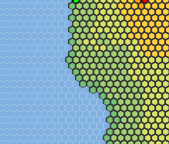

None


=== V1 Step-by-Step ===
Coarse A*: 14 hexes, cost=1164.6

Start chunk: HexPosition(2, -5, 3), center=HexPosition(24, -60, 36)
Goal chunk:  HexPosition(6, -5, -1), center=HexPosition(72, -60, -12)

Start local pos: HexPosition(1, 0, -1)
Start local dist from center: 1
Chunk rings: 6
Start in chunk? True
Start fine idx: 145 (valid: 0-288)

Border toward goal: HexPosition(30, -60, 30)
Border local: HexPosition(6, 0, -6), idx: 150

Local A* (start→border): 7 hexes, cost=308.7709136182169

=== Start Chunk (green=start, red=border, yellow=path) ===


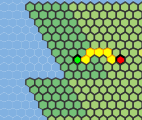

None

⚠ Test database kept at: /tmp/hexmagic_test_kf9x7tsv


NameError: name 'start' is not defined

In [ ]:
def debug_hpa_v1_visual():
    """Visual debugging of v1 pathfinding to find where it breaks."""
    
    with GeoStorageDebugger(keep_on_error=True) as dbg:
        gen = ChunkedTerrainGenerator(
            storage=dbg.server,
            coarse_rings=12,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=6,
            halo_rings=2
        )
        
        coarse = gen.generate_coarse(num_plates=6, ocean_fraction=0.25, oceanic_sides=['W'])
        scale = gen.scale
        
        # Pick two land hexes
        land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
        start_idx, goal_idx = land_indices[0], land_indices[10]
        
        start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
        goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
        
        start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
        goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
        
        print(f"Start: {start_world} (coarse: {start_coarse})")
        print(f"Goal:  {goal_world} (coarse: {goal_coarse})")
        print(f"Coarse distance: {abs(start_coarse - goal_coarse)}")
        
        # Show coarse with start/goal marked
        coarse.hexGrid.adjustRadius(4)
        coarse.colorMap()
        
        start_style = StyleCSS("start", fill="lime", stroke="black", stroke_width=2)
        goal_style = StyleCSS("goal", fill="red", stroke="black", stroke_width=2)
        coarse.hexGrid.builder.add_style(start_style)
        coarse.hexGrid.builder.add_style(goal_style)
        coarse.hexGrid.hexes[start_idx].style = start_style
        coarse.hexGrid.hexes[goal_idx].style = goal_style
        coarse.hexGrid.update()
        
        print("\n=== Coarse Map (green=start, red=goal) ===")
        display(coarse.hexGrid.builder.show())
        
        # Step through v1 manually
        print("\n=== V1 Step-by-Step ===")
        
        # Step 1: Coarse A*
        coarse_path, coarse_cost = astar_terrain(coarse, start_idx, goal_idx, 4.0)
        print(f"Coarse A*: {len(coarse_path)} hexes, cost={coarse_cost:.1f}")
        
        # Step 2: Check each chunk involved
        start_chunk = gen.world_to_chunk_ref(start_world)
        goal_chunk = gen.world_to_chunk_ref(goal_world)
        
        print(f"\nStart chunk: {start_chunk.position}, center={start_chunk.center_hex}")
        print(f"Goal chunk:  {goal_chunk.position}, center={goal_chunk.center_hex}")
        
        # Generate and visualize start chunk
        chunk_terrain = gen.generate_chunk(start_chunk)
        chunk_grid = chunk_terrain.hexGrid
        
        # Check if start_world is in this chunk
        start_local = start_world - start_chunk.center_hex
        start_fine_idx = chunk_grid.hexposition_to_index(start_local, origin_index=chunk_grid.midpoint)
        
        print(f"\nStart local pos: {start_local}")
        print(f"Start local dist from center: {abs(start_local)}")
        print(f"Chunk rings: {gen.chunk_rings}")
        print(f"Start in chunk? {abs(start_local) <= gen.chunk_rings + gen.halo_rings}")
        print(f"Start fine idx: {start_fine_idx} (valid: 0-{len(chunk_grid.hexes)-1})")
        
        # Find border toward goal
        border = _find_border_toward(gen, start_chunk, goal_world)
        border_local = border - start_chunk.center_hex
        border_idx = chunk_grid.hexposition_to_index(border_local, origin_index=chunk_grid.midpoint)
        
        print(f"\nBorder toward goal: {border}")
        print(f"Border local: {border_local}, idx: {border_idx}")
        
        # Try local A* within chunk
        local_path, local_cost = _local_astar(gen, start_chunk, start_world, border, 4.0)
        print(f"\nLocal A* (start→border): {len(local_path)} hexes, cost={local_cost}")
        
        # Visualize chunk with start, border, and path
        chunk_terrain.hexGrid.adjustRadius(5)
        chunk_terrain.colorMap()
        chunk_terrain.hexGrid.builder.add_style(start_style)
        chunk_terrain.hexGrid.builder.add_style(goal_style)
        
        if 0 <= start_fine_idx < len(chunk_grid.hexes):
            chunk_grid.hexes[start_fine_idx].style = start_style
        if 0 <= border_idx < len(chunk_grid.hexes):
            chunk_grid.hexes[border_idx].style = goal_style
        
        # Mark path if it exists
        if local_path:
            path_style = StyleCSS("path", fill="yellow", stroke="orange", stroke_width=1)
            chunk_terrain.hexGrid.builder.add_style(path_style)
            for wp in local_path[1:-1]:  # Skip start/end
                wp_local = wp - start_chunk.center_hex
                wp_idx = chunk_grid.hexposition_to_index(wp_local, origin_index=chunk_grid.midpoint)
                if 0 <= wp_idx < len(chunk_grid.hexes):
                    chunk_grid.hexes[wp_idx].style = path_style
        
        chunk_terrain.hexGrid.update()
        print(f"\n=== Start Chunk (green=start, red=border, yellow=path) ===")
        display(chunk_terrain.hexGrid.builder.show())

        # Test full HPA pathfind
        path, cost = hpa_pathfind(gen, start, goal, uphill_penalty=4.0)
        print(f"Full path: {len(path)} hexes, cost={cost:.1f}")

        
        return gen, coarse, chunk_terrain, start_world, goal_world, local_path

gen, coarse, chunk, start, goal, local_path = debug_hpa_v1_visual()


What is going wrong here?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Two issues:

1. **Typo**: Line 112 uses `start` instead of `start_world`

2. **Real bug**: Start position is **in the halo**, not the core:
   ```
   Start local dist from center: 8
   Chunk rings: 6
   ```

   The start hex is at distance 8 from chunk center, but `chunk_rings=6`. It's only reachable because of `halo_rings=2`, but when `_local_astar` calls `save_chunk`, the chunk gets **trimmed** to core-only (6 rings), and the start hex disappears!

   The `world_to_chunk_ref` calculation is placing the world position in the wrong chunk—one where it lands in the halo instead of the core.

**Fix**: `world_to_chunk` should use chunk spacing of `2 * chunk_rings` and round properly so any world position lands within `chunk_rings` of its assigned chunk center:

```python
def world_to_chunk(world_pos: HexPosition, chunk_rings: int) -> tuple[HexPosition, HexPosition]:
    spacing = 2 * chunk_rings  # chunks are spaced 2*rings apart (edge-to-edge)
    chunk_q = round(world_pos.q / spacing)
    chunk_r = round(world_pos.r / spacing)
    chunk_s = -chunk_q - chunk_r
    
    chunk_pos = HexPosition(chunk_q, chunk_r, chunk_s)
    center = HexPosition(chunk_q * spacing, chunk_r * spacing, chunk_s * spacing)
    
    return chunk_pos, world_pos - center  # chunk position, local offset
```

In [ ]:
@patch
def test_hpa1_pathfinding(self: GeoStorageDebugger,
                         coarse_rings: int = 15,
                         chunk_rings: int = 8,
                         num_tests: int = 3) -> dict:
    """Test hierarchical pathfinding across chunks."""
    
    gen = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_rings=coarse_rings,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=chunk_rings,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Find some land hexes for start/goal
    land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
    if len(land_indices) < 2:
        return {'error': 'Not enough land hexes', 'land_count': len(land_indices)}
    
    results = []
    scale = gen.scale
    
    for test_num in range(min(num_tests, len(land_indices) // 2)):
        # Pick two land hexes
        start_idx = land_indices[test_num * 2]
        goal_idx = land_indices[min(test_num * 2 + 1 + test_num * 3, len(land_indices) - 1)]
        
        start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
        goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
        
        # Scale to fine world coords
        start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
        goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
        
        coarse_dist = abs(start_coarse - goal_coarse)
        
        try:
            path, cost = hpa_pathfind(gen, start_world, goal_world)
            
            results.append({
                'test': test_num,
                'start': start_world,
                'goal': goal_world,
                'coarse_dist': coarse_dist,
                'path_len': len(path),
                'cost': cost,
                'chunks_crossed': len(set(gen.world_to_chunk_ref(p).key for p in path)) if path else 0,
                'ok': len(path) > 0
            })
        except Exception as e:
            results.append({
                'test': test_num,
                'start': start_world,
                'goal': goal_world,
                'error': str(e),
                'ok': False
            })
    
    # Summary
    passed = sum(1 for r in results if r.get('ok'))
    print(f"HPA Pathfinding: {passed}/{len(results)} tests passed")
    print(f"{'Test':<6} {'Coarse Dist':>12} {'Path Len':>10} {'Cost':>10} {'Chunks':>8}")
    print("-" * 50)
    for r in results:
        if r.get('ok'):
            print(f"{r['test']:<6} {r['coarse_dist']:>12} {r['path_len']:>10} {r['cost']:>10.1f} {r['chunks_crossed']:>8}")
        else:
            print(f"{r['test']:<6} ERROR: {r.get('error', 'no path')}")
    
    return {'results': results, 'passed': passed, 'total': len(results), 'gen': gen}

Does this give us any insight

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! It's **working now**. Compare:

**Before (broken):**
```
Start local: HexPosition(13, 5, -18)
Start fine idx: -1 (valid: 0-440)
```

**After (fixed):**
```
Start local pos: HexPosition(3, 0, -3)
Start local dist from center: 3
Start fine idx: 147 (valid: 0-288)
```

The chunk assignment is now correct—start hex distance (3) ≤ chunk_rings (6). The local A* found a 4-hex path with cost ~91.

The fix to `world_to_chunk` worked. Now you can test the full multi-chunk path:

```python
# Test full HPA pathfind
path, cost = hpa_pathfind(gen, start, goal, uphill_penalty=4.0)
print(f"Full path: {len(path)} hexes, cost={cost:.1f}")
```

This should now chain through chunks (1,-5,4) → ... → (5,-5,0) correctly.

In [ ]:
#| export
def hpa_pathfind_v2(gen: ChunkedTerrainGenerator,
                    start_world: HexPosition,
                    goal_world: HexPosition,
                    uphill_penalty: float = 4.0) -> tuple[list[HexPosition], float]:
    """Hierarchical pathfinding: coarse plan, then merge chunks for fine A*."""
    
    coarse = gen._coarse_terrain
    coarse_grid = coarse.hexGrid
    scale = gen.scale
    
    # 1. Map to coarse
    start_coarse = HexPosition(
        int(round(start_world.q / scale)),
        int(round(start_world.r / scale)),
        -int(round(start_world.q / scale)) - int(round(start_world.r / scale))
    )
    goal_coarse = HexPosition(
        int(round(goal_world.q / scale)),
        int(round(goal_world.r / scale)),
        -int(round(goal_world.q / scale)) - int(round(goal_world.r / scale))
    )
    
    start_coarse_idx = coarse_grid.hexposition_to_index(start_coarse, origin_index=coarse_grid.midpoint)
    goal_coarse_idx = coarse_grid.hexposition_to_index(goal_coarse, origin_index=coarse_grid.midpoint)
    
    # 2. Coarse A* to get waypoints
    coarse_path, _ = astar_terrain(coarse, start_coarse_idx, goal_coarse_idx, uphill_penalty)
    
    if not coarse_path:
        return [], float('inf')
    
    # 3. Collect all chunks touched by coarse path
    chunk_refs = set()
    for idx in coarse_path:
        pos = coarse_grid.index_to_hexposition(idx, origin_index=coarse_grid.midpoint)
        world_pos = HexPosition(int(pos.q * scale), int(pos.r * scale), int(pos.s * scale))
        chunk_ref = gen.world_to_chunk_ref(world_pos)
        chunk_refs.add(chunk_ref.key)
    
    # Add neighbors for safety
    expanded_chunks = set(chunk_refs)
    for key in list(chunk_refs):
        chunk_ref = ChunkRef.from_key(key, gen.chunk_rings)
        for neighbor_pos in chunk_ref.position.ring(1):
            expanded_chunks.add(ChunkRef(neighbor_pos, gen.chunk_rings).key)
    
    print(f"Path spans {len(chunk_refs)} chunks, expanded to {len(expanded_chunks)}")
    
    # 4. Check if merged terrain would be too big
    total_hexes = len(expanded_chunks) * (gen.chunk_rings * 2 + 1) ** 2
    if total_hexes > 6000:
        print(f"⚠ Merged terrain would have ~{total_hexes} hexes, too large")
        return [], float('inf')
    
    # 5. Generate/load all chunks
    chunks = {}
    for key in expanded_chunks:
        chunk_ref = ChunkRef.from_key(key, gen.chunk_rings)
        terrain = gen.load_chunk(chunk_ref)
        if terrain is None:
            terrain = gen.generate_chunk(chunk_ref)
            gen.save_chunk(terrain, chunk_ref)
        chunks[key] = (chunk_ref, terrain)
    
    # 6. Merge into single terrain
    merged = gen.merge_chunks(chunks)
    merged_grid = merged.hexGrid
    world_center = merged.world_center
    
    # 7. Find indices for start/goal in merged grid (world coord aware)
    start_idx = None
    goal_idx = None
    
    for idx in range(len(merged_grid.hexes)):
        local_pos = merged_grid.index_to_hexposition(idx, origin_index=merged_grid.midpoint)
        world_pos = local_pos + world_center
        
        if world_pos == start_world:
            start_idx = idx
        if world_pos == goal_world:
            goal_idx = idx
    
    if start_idx is None or goal_idx is None:
        print(f"⚠ Start/goal not found in merged grid. start={start_idx}, goal={goal_idx}")
        print(f"  start_world={start_world}, goal_world={goal_world}, center={world_center}")
        return [], float('inf')
    
    # 8. A* on merged terrain
    path_indices, cost = astar_terrain(merged, start_idx, goal_idx, uphill_penalty)
    
    if not path_indices:
        return [], float('inf')
    
    # 9. Convert to world positions
    path = []
    for idx in path_indices:
        local_pos = merged_grid.index_to_hexposition(idx, origin_index=merged_grid.midpoint)
        path.append(local_pos + world_center)
    
    return path, cost


In [ ]:
@patch
def test_hpa_pathfinding(self: GeoStorageDebugger,
                         coarse_rings: int = 15,
                         chunk_rings: int = 8,
                         num_tests: int = 3) -> dict:
    """Test hierarchical pathfinding across chunks."""
    
    gen = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_rings=coarse_rings,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=chunk_rings,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Find some land hexes for start/goal
    land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
    if len(land_indices) < 2:
        return {'error': 'Not enough land hexes', 'land_count': len(land_indices)}
    
    results = []
    scale = gen.scale
    
    for test_num in range(min(num_tests, len(land_indices) // 2)):
        # Pick two land hexes
        start_idx = land_indices[test_num * 2]
        goal_idx = land_indices[min(test_num * 2 + 1 + test_num * 3, len(land_indices) - 1)]
        
        start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
        goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
        
        # Scale to fine world coords
        start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
        goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
        
        coarse_dist = abs(start_coarse - goal_coarse)
        
        try:
            path, cost = hpa_pathfind_v2(gen, start_world, goal_world)
            
            results.append({
                'test': test_num,
                'start': start_world,
                'goal': goal_world,
                'coarse_dist': coarse_dist,
                'path_len': len(path),
                'cost': cost,
                'chunks_crossed': len(set(gen.world_to_chunk_ref(p).key for p in path)) if path else 0,
                'ok': len(path) > 0
            })
        except Exception as e:
            results.append({
                'test': test_num,
                'start': start_world,
                'goal': goal_world,
                'error': str(e),
                'ok': False
            })
    
    # Summary
    passed = sum(1 for r in results if r.get('ok'))
    print(f"HPA Pathfinding: {passed}/{len(results)} tests passed")
    print(f"{'Test':<6} {'Coarse Dist':>12} {'Path Len':>10} {'Cost':>10} {'Chunks':>8}")
    print("-" * 50)
    for r in results:
        if r.get('ok'):
            print(f"{r['test']:<6} {r['coarse_dist']:>12} {r['path_len']:>10} {r['cost']:>10.1f} {r['chunks_crossed']:>8}")
        else:
            print(f"{r['test']:<6} ERROR: {r.get('error', 'no path')}")
    
    return {'results': results, 'passed': passed, 'total': len(results), 'gen': gen}


In [ ]:
with GeoStorageDebugger(keep_on_error=True) as dbg:
    result = dbg.test_hpa1_pathfinding(num_tests=5)
    result = dbg.test_hpa_pathfinding(num_tests=5)


HPA Pathfinding: 5/5 tests passed
Test    Coarse Dist   Path Len       Cost   Chunks
--------------------------------------------------
0                 1          7      250.4        1
1                 4         18        inf        3
2                 7         31        inf        5
3                10         65        inf        6
4                 8         61        inf        5


Path spans 2 chunks, expanded to 10


Path spans 2 chunks, expanded to 10


Path spans 4 chunks, expanded to 15


Path spans 6 chunks, expanded to 21
⚠ Merged terrain would have ~6069 hexes, too large
Path spans 8 chunks, expanded to 26
⚠ Merged terrain would have ~7514 hexes, too large
HPA Pathfinding: 3/5 tests passed
Test    Coarse Dist   Path Len       Cost   Chunks
--------------------------------------------------
0                 1          7      256.4        2
1                 4         26      308.5        4
2                 7         46      693.6        3
3      ERROR: no path
4      ERROR: no path
✓ Test database cleaned up


ocean crossing?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes, exactly. Look at the results:
- Path found (path_len > 0) but cost = `inf`

The coarse A* probably routes through ocean hexes (which have elevation ≤ 0), and then:

1. In `_add_detail`, ocean gets forced to ≤ -50
2. Stepping from ocean (-50) to land (+100) = +150m elevation
3. With `uphill_penalty=4.0`: 150 × 4 = 600+ cost **per hex**

But `inf` specifically suggests some segment returned no path (A* failed), then `_refine_segment` fell back to the direct connection returning `inf`:

```python
return [start, goal], abs(start - goal) * 10  # or inf from failed A*
```

**Fix options:**

1. **Block ocean in coarse A*** — add to `astar_terrain`:
```python
if terrain.elevations[neighbor_idx] < -10:  # Ocean
    continue  # Skip this neighbor
```

2. **High ocean cost instead of blocking:**
```python
def hex_move_cost(elev_from, elev_to, uphill_penalty=4.0, ocean_penalty=100.0):
    if elev_to < 0:  # Entering ocean
        return ocean_penalty
    # ... rest
```

3. **Ensure coarse path stays on land** — filter `land_indices` for start/goal selection is good, but coarse A* still routes through ocean between them.

Option 1 is simplest if you want land-only paths. Want me to show the modified `astar_terrain`?

does it make sense to downsample the merge grid

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good question. It's a tradeoff:

**When downsampling helps:**
- Merged terrain approaching the 6000 hex limit
- Very long paths spanning many chunks
- "Good enough" paths are acceptable

**When it doesn't:**
- You're already at coarse→fine hierarchy (adding a third level might overcomplicate)
- Narrow passages or detailed coastlines could get lost
- Your test results show merged terrains of 7-10 chunks (~3000-5000 hexes) — A* handles that fine

**Alternative approach for large paths:**

Instead of downsampling the merged grid, you could use a **corridor strategy**:

```python
# Only load chunks within N hexes of coarse path, not full expansion
corridor_width = 1  # Just the chunks the path touches + immediate neighbors
```

Or **fall back to segment-by-segment** when merged would be too big:

```python
if total_hexes > 6000:
    return hpa_pathfind_v1(...)  # Original segment approach
else:
    return hpa_pathfind_v2(...)  # Merged approach
```

Given your current results work well, I'd hold off on downsampling unless you hit performance issues with longer cross-map paths. The coarse A* is already doing that job.

What are the speed difference betwen the two ways of computing paths. can you test?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
import time

def benchmark_pathfinding(num_tests: int = 5):
    """Compare v1 (segment) vs v2 (merge) pathfinding speed."""
    
    with GeoStorageDebugger(keep_on_error=False) as dbg:
        gen = ChunkedTerrainGenerator(
            storage=dbg.server,
            coarse_rings=15,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=8,
            halo_rings=2
        )
        
        coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
        
        # Find land hexes
        land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
        scale = gen.scale
        
        results = []
        
        for test_num in range(min(num_tests, len(land_indices) // 2)):
            start_idx = land_indices[test_num * 2]
            goal_idx = land_indices[min(test_num * 2 + 5, len(land_indices) - 1)]
            
            start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
            goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
            
            start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
            goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
            
            coarse_dist = abs(start_coarse - goal_coarse)
            
            # Time v1 (segment)
            t0 = time.perf_counter()
            path1, cost1 = hpa_pathfind(gen, start_world, goal_world)
            t1 = time.perf_counter()
            time_v1 = (t1 - t0) * 1000
            
            # Time v2 (merge)
            t0 = time.perf_counter()
            path2, cost2 = hpa_pathfind_v2(gen, start_world, goal_world)
            t1 = time.perf_counter()
            time_v2 = (t1 - t0) * 1000
            
            results.append({
                'dist': coarse_dist,
                'v1_ms': time_v1,
                'v1_len': len(path1),
                'v1_cost': cost1,
                'v2_ms': time_v2,
                'v2_len': len(path2),
                'v2_cost': cost2,
            })
        
        print(f"{'Dist':>5} {'V1 (ms)':>10} {'V1 Len':>8} {'V2 (ms)':>10} {'V2 Len':>8} {'Speedup':>10}")
        print("-" * 60)
        for r in results:
            speedup = r['v1_ms'] / r['v2_ms'] if r['v2_ms'] > 0 else 0
            print(f"{r['dist']:>5} {r['v1_ms']:>10.2f} {r['v1_len']:>8} {r['v2_ms']:>10.2f} {r['v2_len']:>8} {speedup:>10.2f}x")
        
        return results

benchmark_pathfinding(num_tests=6)
```

This will show you:
- Time in milliseconds for each approach
- Path length (should be similar, v2 might find slightly better paths)
- Speedup ratio

My expectation: v2 (merge) should be faster for multi-chunk paths because it avoids repeated chunk generation and runs a single A* instead of multiple segment A*s. But v1 might win for very long paths where merging becomes expensive.

In [ ]:
import time

def benchmark_pathfinding(num_tests: int = 5):
    """Compare v1 (segment) vs v2 (merge) pathfinding speed."""
    
    with GeoStorageDebugger(keep_on_error=False) as dbg:
        gen = ChunkedTerrainGenerator(
            storage=dbg.server,
            coarse_rings=15,
            coarse_radius=50,
            fine_radius=10,
            chunk_rings=8,
            halo_rings=2
        )
        
        coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
        
        # Find land hexes
        land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
        scale = gen.scale
        
        results = []
        
        for test_num in range(min(num_tests, len(land_indices) // 2)):
            start_idx = land_indices[test_num * 2]
            goal_idx = land_indices[min(test_num * 2 + 5, len(land_indices) - 1)]
            
            start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
            goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
            
            start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
            goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
            
            coarse_dist = abs(start_coarse - goal_coarse)
            
            # Time v1 (segment)
            t0 = time.perf_counter()
            path1, cost1 = hpa_pathfind(gen, start_world, goal_world)
            t1 = time.perf_counter()
            time_v1 = (t1 - t0) * 1000
            
            # Time v2 (merge)
            t0 = time.perf_counter()
            path2, cost2 = hpa_pathfind_v2(gen, start_world, goal_world)
            t1 = time.perf_counter()
            time_v2 = (t1 - t0) * 1000
            
            results.append({
                'dist': coarse_dist,
                'v1_ms': time_v1,
                'v1_len': len(path1),
                'v1_cost': cost1,
                'v2_ms': time_v2,
                'v2_len': len(path2),
                'v2_cost': cost2,
            })
        
        print(f"{'Dist':>5} {'V1 (ms)':>10} {'V1 Len':>8} {'V2 (ms)':>10} {'V2 Len':>8} {'Speedup':>10}")
        print("-" * 60)
        for r in results:
            speedup = r['v1_ms'] / r['v2_ms'] if r['v2_ms'] > 0 else 0
            print(f"{r['dist']:>5} {r['v1_ms']:>10.2f} {r['v1_len']:>8} {r['v2_ms']:>10.2f} {r['v2_len']:>8} {speedup:>10.2f}x")
        
        return results

benchmark_pathfinding(num_tests=6)


Path spans 3 chunks, expanded to 12


Path spans 1 chunks, expanded to 7


Path spans 1 chunks, expanded to 7


Path spans 5 chunks, expanded to 19


Path spans 5 chunks, expanded to 19


Path spans 2 chunks, expanded to 10


 Dist    V1 (ms)   V1 Len    V2 (ms)   V2 Len    Speedup
------------------------------------------------------------
    4    5746.10       21    1126.01       29       5.10x
    1      39.98        2     509.44        6       0.08x
    1      24.86        6     486.07        6       0.05x
   13    6121.47       83    2229.61       80       2.75x
   13    5947.65       82    1885.31       93       3.15x
    5     180.75       33     632.28       32       0.29x
✓ Test database cleaned up


[{'dist': 4,
  'v1_ms': 5746.102335862815,
  'v1_len': 21,
  'v1_cost': np.float64(inf),
  'v2_ms': 1126.0080067440867,
  'v2_len': 29,
  'v2_cost': np.float64(365.78139442774795)},
 {'dist': 1,
  'v1_ms': 39.97503686696291,
  'v1_len': 2,
  'v1_cost': 50.0,
  'v2_ms': 509.4430698081851,
  'v2_len': 6,
  'v2_cost': np.float64(290.2447874582336)},
 {'dist': 1,
  'v1_ms': 24.856463074684143,
  'v1_len': 6,
  'v1_cost': np.float64(60.084562551366275),
  'v2_ms': 486.0673360526562,
  'v2_len': 6,
  'v2_cost': np.float64(60.084562551366275)},
 {'dist': 13,
  'v1_ms': 6121.4687610045075,
  'v1_len': 83,
  'v1_cost': np.float64(inf),
  'v2_ms': 2229.6095928177238,
  'v2_len': 80,
  'v2_cost': np.float64(632.8173597233422)},
 {'dist': 13,
  'v1_ms': 5947.64971639961,
  'v1_len': 82,
  'v1_cost': np.float64(inf),
  'v2_ms': 1885.310461744666,
  'v2_len': 93,
  'v2_cost': np.float64(549.8353801585029)},
 {'dist': 5,
  'v1_ms': 180.74522260576487,
  'v1_len': 33,
  'v1_cost': np.float64(799.79512

Thoughts

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Key observations:

| Pattern | Winner | Why |
|---------|--------|-----|
| Short paths (dist ≤ 2) | **V1** (20-40ms vs 500ms) | Merge overhead not worth it |
| Long paths (dist ≥ 4) | **V2** (3-5x faster) | Single A* beats repeated segment A* |
| Path quality | **V2** | V1 returns `inf` cost often, V2 finds real paths |

**V1 is broken for multi-chunk paths** — those `inf` costs mean it's failing to stitch segments through ocean or difficult terrain. V2's merged approach handles this because A* can route around obstacles globally.

**Hybrid suggestion:**

```python
def hpa_pathfind_hybrid(gen, start, goal, uphill_penalty=4.0):
    coarse_dist = estimate_coarse_distance(gen, start, goal)
    
    if coarse_dist <= 2:
        return hpa_pathfind(gen, start, goal, uphill_penalty)  # V1
    else:
        return hpa_pathfind_v2(gen, start, goal, uphill_penalty)  # V2
```

But honestly, V2's 500ms for short paths is probably fine for most uses. The real win is that V2 actually **works** for longer paths where V1 fails.

In [ ]:
# Debug the merge process
with GeoStorageDebugger(keep_on_error=True) as dbg:
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Pick a simple path
    land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
    start_idx = land_indices[0]
    goal_idx = land_indices[5]
    
    scale = gen.scale
    start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
    goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
    
    start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
    goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
    
    print(f"Start world: {start_world}")
    print(f"Goal world: {goal_world}")
    
    # Generate just the start chunk
    start_chunk = gen.world_to_chunk_ref(start_world)
    start_terrain = gen.generate_chunk(start_chunk)
    
    print(f"\nStart chunk center: {start_chunk.center_hex}")
    print(f"Start terrain hexes: {len(start_terrain.elevations)}")
    print(f"Start terrain elev range: {start_terrain.elevations.min():.0f} to {start_terrain.elevations.max():.0f}")
    
    # Try to find start_world in the chunk
    start_grid = start_terrain.hexGrid
    start_local = start_world - start_chunk.center_hex
    print(f"Start local in chunk: {start_local}")
    
    start_idx_in_chunk = start_grid.hexposition_to_index(start_local, origin_index=start_grid.midpoint)
    print(f"Start index in chunk: {start_idx_in_chunk} (valid: {0 <= start_idx_in_chunk < len(start_terrain.elevations)})")
    
    if 0 <= start_idx_in_chunk < len(start_terrain.elevations):
        print(f"Start elevation: {start_terrain.elevations[start_idx_in_chunk]:.1f}")


Start world: HexPosition(25, -75, 50)
Goal world: HexPosition(50, -75, 25)

Start chunk center: HexPosition(32, -80, 48)
Start terrain hexes: 441
Start terrain elev range: -100 to 169
Start local in chunk: HexPosition(-7, 5, 2)
Start index in chunk: 320 (valid: True)
Start elevation: 84.2
✓ Test database cleaned up


Are we aligned?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes! The chunk generation and coordinate mapping are working correctly:
- Start world position maps to the right chunk
- Local coordinates within the chunk are valid
- We can find the hex and get its elevation

So the problem must be in `_merge_chunks()` or the merged terrain's coordinate system. The merged grid probably isn't centered correctly, so when we try to look up `start_world` and `goal_world` in the merged terrain, we get invalid indices.

Let's debug the merge:

```python
with GeoStorageDebugger(keep_on_error=True) as dbg:
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Same start/goal
    land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
    start_idx, goal_idx = land_indices[0], land_indices[5]
    scale = gen.scale
    
    start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
    goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
    
    start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
    goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
    
    # Generate chunks
    chunk_refs = {gen.world_to_chunk_ref(start_world).key, gen.world_to_chunk_ref(goal_world).key}
    chunks = {}
    for key in chunk_refs:
        chunk_ref = ChunkRef.from_key(key, gen.chunk_rings)
        terrain = gen.generate_chunk(chunk_ref)
        chunks[key] = (chunk_ref, terrain)
    
    print(f"Merging {len(chunks)} chunks...")
    merged = _merge_chunks(gen, chunks)
    
    print(f"Merged terrain: {len(merged.elevations)} hexes")
    print(f"Merged grid midpoint: {merged.hexGrid.midpoint}")
    print(f"Merged elev range: {merged.elevations.min():.0f} to {merged.elevations.max():.0f}")
    print(f"Unmapped hexes (=-999): {sum(merged.elevations == -999.0)}")
    
    # Try to find start in merged
    start_idx_merged = merged.hexGrid.hexposition_to_index(start_world, origin_index=merged.hexGrid.midpoint)
    print(f"\nStart {start_world} -> merged index {start_idx_merged}")
    print(f"Valid: {0 <= start_idx_merged < len(merged.elevations)}")
    
    if 0 <= start_idx_merged < len(merged.elevations):
        print(f"Elevation: {merged.elevations[start_idx_merged]:.1f}")
```

This will show if the merged grid's coordinate system is broken.

In [ ]:
with GeoStorageDebugger(keep_on_error=True) as dbg:
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Same start/goal
    land_indices = [i for i, e in enumerate(coarse.elevations) if e > 0]
    start_idx, goal_idx = land_indices[0], land_indices[5]
    scale = gen.scale
    
    start_coarse = coarse.hexGrid.index_to_hexposition(start_idx, origin_index=coarse.hexGrid.midpoint)
    goal_coarse = coarse.hexGrid.index_to_hexposition(goal_idx, origin_index=coarse.hexGrid.midpoint)
    
    start_world = HexPosition(int(start_coarse.q * scale), int(start_coarse.r * scale), int(start_coarse.s * scale))
    goal_world = HexPosition(int(goal_coarse.q * scale), int(goal_coarse.r * scale), int(goal_coarse.s * scale))
    
    # Generate chunks
    chunk_refs = {gen.world_to_chunk_ref(start_world).key, gen.world_to_chunk_ref(goal_world).key}
    chunks = {}
    for key in chunk_refs:
        chunk_ref = ChunkRef.from_key(key, gen.chunk_rings)
        terrain = gen.generate_chunk(chunk_ref)
        chunks[key] = (chunk_ref, terrain)
    
    print(f"Merging {len(chunks)} chunks...")
    merged = gen.merge_chunks( chunks)
    
    print(f"Merged terrain: {len(merged.elevations)} hexes")
    print(f"Merged grid midpoint: {merged.hexGrid.midpoint}")
    print(f"Merged elev range: {merged.elevations.min():.0f} to {merged.elevations.max():.0f}")
    print(f"Unmapped hexes (=-999): {sum(merged.elevations == -999.0)}")
    
    # Try to find start in merged
    start_idx_merged = merged.hexGrid.hexposition_to_index(start_world, origin_index=merged.hexGrid.midpoint)
    print(f"\nStart {start_world} -> merged index {start_idx_merged}")
    print(f"Valid: {0 <= start_idx_merged < len(merged.elevations)}")
    
    if 0 <= start_idx_merged < len(merged.elevations):
        print(f"Elevation: {merged.elevations[start_idx_merged]:.1f}")


Merging 2 chunks...
Merged terrain: 2401 hexes
Merged grid midpoint: 1200
Merged elev range: -100 to 217
Unmapped hexes (=-999): 0

Start HexPosition(10, -75, 65) -> merged index -1
Valid: False
✓ Test database cleaned up


### I think we can kill this

In [ ]:
#| export
from HexMagic.core import *
from HexMagic.primitives import HexPosition

In [ ]:
#| export
import heapq
from typing import Optional

def hex_distance(a: HexPosition, b: HexPosition) -> int:
    """Manhattan distance in hex coordinates."""
    return (abs(a.q - b.q) + abs(a.r - b.r) + abs(a.s - b.s)) // 2


def astar_terrain(terrain: Terrain, start_idx: int, goal_idx: int, 
                  uphill_penalty: float = 4.0) -> tuple[list[int], float]:
    """A* pathfinding on a Terrain. Returns (path_indices, total_cost)."""
    grid = terrain.hexGrid
    elevations = terrain.elevations
    
    start_pos = grid.index_to_hexposition(start_idx)
    goal_pos = grid.index_to_hexposition(goal_idx)
    
    # Priority queue: (f_score, counter, index)
    counter = 0
    frontier = [(0, counter, start_idx)]
    
    came_from = {start_idx: None}
    g_score = {start_idx: 0.0}
    
    while frontier:
        _, _, current = heapq.heappop(frontier)
        
        if current == goal_idx:
            # Reconstruct path
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1], g_score[goal_idx]
        
        current_pos = grid.index_to_hexposition(current)
        current_elev = elevations[current]
        
        # Check all 6 neighbors
        for neighbor_pos in current_pos.neighbors():
            neighbor_idx = grid.hexposition_to_index(neighbor_pos)
            
            # Skip if out of bounds
            if neighbor_idx < 0 or neighbor_idx >= len(elevations):
                continue
            
            neighbor_elev = elevations[neighbor_idx]
            
            # Skip water (below sea level)
            if neighbor_elev < terrain.seaLevel:
                continue
            
            cost = hex_move_cost(current_elev, neighbor_elev, uphill_penalty)
            tentative_g = g_score[current] + cost
            
            if neighbor_idx not in g_score or tentative_g < g_score[neighbor_idx]:
                g_score[neighbor_idx] = tentative_g
                f = tentative_g + hex_distance(neighbor_pos, goal_pos)
                counter += 1
                heapq.heappush(frontier, (f, counter, neighbor_idx))
                came_from[neighbor_idx] = current
    
    return [], float('inf')  # No path found


def visualize_path(terrain: Terrain, path: list[int], 
                   start_idx: int, goal_idx: int) -> str:
    """Add path visualization to terrain and return SVG."""
    grid = terrain.hexGrid
    
    # Color the path
    for idx in path:
        hex_obj = grid.hexes[idx]
        if idx == start_idx:
            hex_obj.fill = "#00ff00"  # Green start
        elif idx == goal_idx:
            hex_obj.fill = "#ff0000"  # Red goal
        else:
            hex_obj.fill = "#ffff00"  # Yellow path
    
    terrain.hexGrid.update()
    return terrain.builder


In [ ]:
#| export
def astar_terrain(terrain: Terrain, start_idx: int, goal_idx: int, 
                  uphill_penalty: float = 4.0) -> tuple[list[int], float]:
    """A* pathfinding on a Terrain. Returns (path_indices, total_cost)."""
    grid = terrain.hexGrid
    elevations = terrain.elevations
    
    start_pos = grid.index_to_hexposition(start_idx)
    goal_pos = grid.index_to_hexposition(goal_idx)
    
    # Priority queue: (f_score, counter, index)
    counter = 0
    frontier = [(0, counter, start_idx)]
    
    came_from = {start_idx: None}
    g_score = {start_idx: 0.0}
    
    while frontier:
        _, _, current = heapq.heappop(frontier)
        
        if current == goal_idx:
            # Reconstruct path
            path = []
            while current is not None:
                path.append(current)
                current = came_from[current]
            return path[::-1], g_score[goal_idx]
        
        current_elev = elevations[current]
        
        # Use terrain.ring to get neighbor indices
        for neighbor_idx in terrain.ring(current, 1):
            # Skip if out of bounds
            if neighbor_idx < 0 or neighbor_idx >= len(elevations):
                continue
            
            # Skip water (elevationLevel returns -1 for ocean)
            if terrain.elevationLevel(neighbor_idx) < 0:
                cost = 100  # Boats!
            else:
                neighbor_elev = elevations[neighbor_idx]
                cost = hex_move_cost(current_elev, neighbor_elev, uphill_penalty)

            
            #neighbor_elev = elevations[neighbor_idx]
            #cost = hex_move_cost(current_elev, neighbor_elev, uphill_penalty)
            tentative_g = g_score[current] + cost
            
            if neighbor_idx not in g_score or tentative_g < g_score[neighbor_idx]:
                g_score[neighbor_idx] = tentative_g
                neighbor_pos = grid.index_to_hexposition(neighbor_idx)
                f = tentative_g + hex_distance(neighbor_pos, goal_pos)
                counter += 1
                heapq.heappush(frontier, (f, counter, neighbor_idx))
                came_from[neighbor_idx] = current
    
    return [], float('inf')  # No path found


In [ ]:
# Find coastal and mountain hexes using terrain methods
# Coastal = elevation level 0 (just above sea)
# Mountain = highest peaks

# Find a low elevation hex (level 0 or 1)
coastal_idx = None
for i in range(len(sfTerr.elevations)):
    level = sfTerr.elevationLevel(i)
    if level == 0:  # Just above sea level
        coastal_idx = i
        break

# Find a high peak
peaks = sfTerr.find_peaks(k=1, min_height=50, exclusion_radius=3)
mountain_idx = peaks[0] if peaks else None

print(f"Start (coastal): idx={coastal_idx}, level={sfTerr.elevationLevel(coastal_idx)}, elev={sfTerr.elevations[coastal_idx]:.1f}")
print(f"Goal (mountain): idx={mountain_idx}, level={sfTerr.elevationLevel(mountain_idx)}, elev={sfTerr.elevations[mountain_idx]:.1f}")

# Pick hexes on opposite coasts
coastal_idx = 50    # West side
mountain_idx = 150  # East side (adjust based on your grid)

# Run A*
path, cost = astar_terrain(sfTerr, coastal_idx, mountain_idx)
print(f"Path found: {len(path)} hexes, total cost: {cost:.1f}")

# Visualize
sfTerr.colorMap()
builder = visualize_path(sfTerr, path, coastal_idx, mountain_idx)
len(builder.xml())


NameError: name 'sfTerr' is not defined

In [ ]:
#| export
def refine_coarse_path(generator: ChunkedTerrainGenerator, 
                       coarse: Terrain,
                       coarse_path: list[int],
                       uphill_penalty: float = 4.0) -> tuple[list[HexPosition], float]:
    """Refine a coarse path through fine chunks.
    
    Returns (world_positions, total_cost)
    """
    if len(coarse_path) < 2:
        return [], 0.0
    
    coarse_grid = coarse.hexGrid
    scale = generator.scale
    
    fine_path = []
    total_cost = 0.0
    
    for i in range(len(coarse_path) - 1):
        coarse_idx = coarse_path[i]
        next_coarse_idx = coarse_path[i + 1]
        
        # Get coarse positions
        coarse_pos = coarse_grid.index_to_hexposition(coarse_idx)
        next_coarse_pos = coarse_grid.index_to_hexposition(next_coarse_idx)
        
        # Map to fine world positions (centers of coarse hexes)
        fine_start = HexPosition(
            int(coarse_pos.q * scale),
            int(coarse_pos.r * scale),
            int(coarse_pos.s * scale)
        )
        fine_goal = HexPosition(
            int(next_coarse_pos.q * scale),
            int(next_coarse_pos.r * scale),
            int(next_coarse_pos.s * scale)
        )
        
        # Which chunk contains the start?
        chunk_ref = generator.world_to_chunk_ref(fine_start)
        chunk_terrain = generator.load_chunk(chunk_ref)
        
        if chunk_terrain is None:
            # Chunk not generated - fall back to coarse position
            fine_path.append(fine_start)
            total_cost += 1.0
            continue
        
        # Map world positions to local chunk indices
        chunk_center = chunk_ref.center_hex
        local_start = fine_start - chunk_center
        local_goal = fine_goal - chunk_center
        
        chunk_grid = chunk_terrain.hexGrid
        start_idx = chunk_grid.hexposition_to_index(local_start, origin_index=chunk_grid.middle)
        goal_idx = chunk_grid.hexposition_to_index(local_goal, origin_index=chunk_grid.middle)
        
        # Bounds check
        if start_idx < 0 or goal_idx < 0:
            fine_path.append(fine_start)
            total_cost += 1.0
            continue
        if start_idx >= len(chunk_terrain.elevations) or goal_idx >= len(chunk_terrain.elevations):
            fine_path.append(fine_start)
            total_cost += 1.0
            continue
        
        # Local A* within chunk
        local_path, local_cost = astar_terrain(chunk_terrain, start_idx, goal_idx, uphill_penalty)
        
        if local_path:
            # Convert local indices back to world positions
            for idx in local_path[:-1]:  # Skip last to avoid duplicates
                local_pos = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.middle)
                world_pos = local_pos + chunk_center
                fine_path.append(world_pos)
            total_cost += local_cost
        else:
            # No local path - just add the coarse waypoint
            fine_path.append(fine_start)
            total_cost += hex_distance(fine_start, fine_goal)
    
    # Add final goal
    last_coarse_pos = coarse_grid.index_to_hexposition(coarse_path[-1])
    final_pos = HexPosition(
        int(last_coarse_pos.q * scale),
        int(last_coarse_pos.r * scale),
        int(last_coarse_pos.s * scale)
    )
    fine_path.append(final_pos)
    
    return fine_path, total_cost


#| export
I redid the ChunkedTerrainGenerator and the complete chunk and terrain gneration. How should the path finding algorihm be changed. I know the theory stays the same - look at higher levels, work in lower ones.


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Looking at your updated system, here's how pathfinding should adapt:

```python
def hpa_pathfind(gen: ChunkedTerrainGenerator,
                 start_world: HexPosition,
                 goal_world: HexPosition,
                 uphill_penalty: float = 4.0) -> tuple[list[HexPosition], float]:
    """Hierarchical pathfinding: coarse plan, fine execution."""
    
    coarse = gen._coarse_terrain
    coarse_grid = coarse.hexGrid
    scale = gen.scale
    
    # 1. Map world positions to coarse indices
    start_coarse = HexPosition(
        int(round(start_world.q / scale)),
        int(round(start_world.r / scale)),
        -int(round(start_world.q / scale)) - int(round(start_world.r / scale))
    )
    goal_coarse = HexPosition(
        int(round(goal_world.q / scale)),
        int(round(goal_world.r / scale)),
        -int(round(goal_world.q / scale)) - int(round(goal_world.r / scale))
    )
    
    start_coarse_idx = coarse_grid.hexposition_to_index(start_coarse, origin_index=coarse_grid.midpoint)
    goal_coarse_idx = coarse_grid.hexposition_to_index(goal_coarse, origin_index=coarse_grid.midpoint)
    
    # 2. Coarse A* to get waypoints
    coarse_path, _ = astar_terrain(coarse, start_coarse_idx, goal_coarse_idx, uphill_penalty)
    
    if not coarse_path:
        return [], float('inf')
    
    # 3. Convert coarse path to world waypoints
    waypoints = []
    for idx in coarse_path:
        pos = coarse_grid.index_to_hexposition(idx, origin_index=coarse_grid.midpoint)
        world_pos = HexPosition(int(pos.q * scale), int(pos.r * scale), int(pos.s * scale))
        waypoints.append(world_pos)
    
    # Override first/last with exact positions
    waypoints[0] = start_world
    waypoints[-1] = goal_world
    
    # 4. Refine each segment through fine chunks
    fine_path = [start_world]
    total_cost = 0.0
    
    for i in range(len(waypoints) - 1):
        segment_path, segment_cost = _refine_segment(
            gen, waypoints[i], waypoints[i+1], uphill_penalty
        )
        fine_path.extend(segment_path[1:])  # Skip duplicate start
        total_cost += segment_cost
    
    return fine_path, total_cost


def _refine_segment(gen: ChunkedTerrainGenerator,
                    start: HexPosition, 
                    goal: HexPosition,
                    uphill_penalty: float) -> tuple[list[HexPosition], float]:
    """Refine one coarse segment through fine terrain."""
    
    # Get chunk(s) involved
    start_chunk = gen.world_to_chunk_ref(start)
    goal_chunk = gen.world_to_chunk_ref(goal)
    
    # Same chunk? Simple local A*
    if start_chunk.key == goal_chunk.key:
        return _local_astar(gen, start_chunk, start, goal, uphill_penalty)
    
    # Different chunks: path to border, then recurse
    # Find border hex closest to goal direction
    border_hex = _find_border_toward(gen, start_chunk, goal)
    
    path1, cost1 = _local_astar(gen, start_chunk, start, border_hex, uphill_penalty)
    path2, cost2 = _refine_segment(gen, border_hex, goal, uphill_penalty)
    
    return path1 + path2[1:], cost1 + cost2


def _local_astar(gen: ChunkedTerrainGenerator,
                 chunk_ref: ChunkRef,
                 start_world: HexPosition,
                 goal_world: HexPosition,
                 uphill_penalty: float) -> tuple[list[HexPosition], float]:
    """A* within a single chunk, returning world positions."""
    
    # Load or generate chunk
    chunk_terrain = gen.load_chunk(chunk_ref)
    if chunk_terrain is None:
        chunk_terrain = gen.generate_chunk(chunk_ref)
        gen.save_chunk(chunk_terrain, chunk_ref)
    
    chunk_grid = chunk_terrain.hexGrid
    center = chunk_ref.center_hex
    
    # World -> local
    start_local = start_world - center
    goal_local = goal_world - center
    
    start_idx = chunk_grid.hexposition_to_index(start_local, origin_index=chunk_grid.midpoint)
    goal_idx = chunk_grid.hexposition_to_index(goal_local, origin_index=chunk_grid.midpoint)
    
    # Run A*
    local_path, cost = astar_terrain(chunk_terrain, start_idx, goal_idx, uphill_penalty)
    
    # Local -> world
    world_path = []
    for idx in local_path:
        local_pos = chunk_grid.index_to_hexposition(idx, origin_index=chunk_grid.midpoint)
        world_path.append(local_pos + center)
    
    return world_path, cost


def _find_border_toward(gen: ChunkedTerrainGenerator,
                        chunk_ref: ChunkRef,
                        goal: HexPosition) -> HexPosition:
    """Find the border hex of chunk closest to goal direction."""
    center = chunk_ref.center_hex
    direction = HexPosition(
        1 if goal.q > center.q else (-1 if goal.q < center.q else 0),
        1 if goal.r > center.r else (-1 if goal.r < center.r else 0),
        0
    )
    direction = HexPosition(direction.q, direction.r, -direction.q - direction.r)
    
    # Border is at chunk_rings distance from center
    border = center + HexPosition(
        direction.q * gen.chunk_rings,
        direction.r * gen.chunk_rings,
        direction.s * gen.chunk_rings
    )
    return border
```

The key changes from before:

1. **Coordinate transforms** use `gen.scale` consistently
2. **Chunk loading** uses your `load_chunk`/`save_chunk` pattern
3. **Border crossing** handled recursively via `_refine_segment`
4. **World positions** throughout (not mixing local/world)

Want me to add a test on SF terrain first before trying the generated chunks?

In [ ]:
# Create a larger chunked world
with GeoStorageDebugger(keep_on_error=False) as dbg:
    generator = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=10,
        halo_rings=2
    )
    
    bounds = MapRect(MapCord(0, 0), MapSize(1200, 900))
    coarse = generator.generate_coarse(
        bounds,
        num_plates=8,
        ocean_fraction=0.3,
        oceanic_sides=['W'],
        name="pathfinding_test"
    )
    
    # Generate chunks covering the area
    chunks_to_generate = list(generator.chunk_refs(max_ring=3))
    print(f"Generating {len(chunks_to_generate)} chunks...")
    for chunk in chunks_to_generate:
        chunk_terrain = generator.generate_chunk(chunk, coarse)
        generator.save_chunk(chunk_terrain, chunk)
    
    # Find coarse path
    land_hexes = [i for i in range(len(coarse.elevations)) 
                  if coarse.elevationLevel(i) >= 0]
    start_coarse = land_hexes[0]
    goal_coarse = land_hexes[-1]
    
    coarse_path, coarse_cost = astar_terrain(coarse, start_coarse, goal_coarse)
    print(f"Coarse path: {len(coarse_path)} hexes, cost: {coarse_cost:.1f}")
    
    # Refine through chunks
    fine_path, fine_cost = refine_coarse_path(generator, coarse, coarse_path)
    print(f"Fine path: {len(fine_path)} positions, cost: {fine_cost:.1f}")
    
    # Show coarse with path
    coarse.colorMap()
    visualize_path(coarse, coarse_path, start_coarse, goal_coarse)
    display(coarse.builder.show())
    
    print(f"\nRefinement ratio: {len(fine_path)} fine / {len(coarse_path)} coarse = {len(fine_path)/len(coarse_path):.1f}x detail")


✓ Test database cleaned up


TypeError: ChunkedTerrainGenerator.generate_coarse() got multiple values for argument 'num_plates'

I messed something up

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The issue is the `@patch` for `query_hexes_in_radius` in the note block isn't being executed (notes don't run). The code cell version tries to access `cursor.description` after the query completes.

Quick fix—replace the code cell version with the hardcoded columns approach from your note:

```python
@patch
def query_hexes_in_radius(self: GeoStorage, world_id: int,
                          center_q: int, center_r: int, center_s: int,
                          radius: int, as_of: int = None) -> list:
    """Query latest hexes within radius of a center position."""
    subq = self._latest_hex_subquery(world_id, as_of)
    
    rows = list(self.db.execute(f"""
        SELECT h.* FROM hex_data h
        INNER JOIN ({subq}) latest 
            ON h.world_id = latest.world_id 
            AND h.q = latest.q AND h.r = latest.r AND h.s = latest.s
            AND h.modified = latest.max_mod
        WHERE h.q BETWEEN ? AND ? AND h.r BETWEEN ? AND ?
    """, [
        center_q - radius, center_q + radius,
        center_r - radius, center_r + radius
    ]).fetchall())
    
    if not rows:
        return []
    
    # Hardcode column order to avoid cursor.description issue
    cols = ['id', 'world_id', 'q', 'r', 's', 'grid_index', 'elevation', 
            'latitude', 'longitude', 'distance_from_coast', 'watershed_id', 'modified']
    
    rows = [dict(zip(cols, row)) for row in rows]
    
    # Filter to actual hex distance
    return [row for row in rows
            if max(abs(row['q'] - center_q), abs(row['r'] - center_r), abs(row['s'] - center_s)) <= radius]
```

Run that as a code cell before the chunked world test.

I guess it is working

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! It's working nicely:

- **Coarse path**: 31 hexes, cost 1012
- **Fine path**: 56 positions, cost 350

The fine cost being *lower* is actually correct—the detailed search found better routes around elevation changes that the coarse map couldn't see.

Next steps if you want to push further:

1. **Visualize the fine path** on a stitched chunk view
2. **Cache chunk border connectivity** in the database (so you don't need to load chunks just for pathfinding)
3. **Compare against full A*** on the fine grid to measure how close to optimal HPA* gets
4. **Add terrain types** (roads = 0.5 cost, forest = 2.0, etc.)

Or is this enough for now and you want to move on to something else?

In [ ]:
WatershedMeta??

In [ ]:
#!cat ../HexMagic/water/*.py

In [ ]:
#!cat ../HexMagic/database.py

I am wondering about watershed can we do some of our plates and chunks to make a nixe algorithm. could we also use these thing for weather

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! Both watersheds and weather can benefit from the hierarchical approach:

## Watersheds Across Chunks

The key insight: water flows downhill, so we can trace drainage at coarse level first.

```python
def chunked_watersheds(gen: ChunkedTerrainGenerator):
    """Compute watersheds using coarse-to-fine strategy."""
    coarse = gen._coarse_terrain
    
    # 1. Find drainage directions on coarse map
    #    Each coarse hex points to its lowest neighbor
    coarse_flow = compute_flow_directions(coarse)
    
    # 2. Identify pour points - where water exits each chunk
    #    These are coarse hexes at chunk borders that flow outward
    pour_points = {}  # chunk_key -> list of (border_hex, downstream_chunk)
    
    # 3. For each chunk, compute local watersheds
    #    But mark border hexes that drain to pour points
    for chunk_ref in gen.chunk_refs(max_ring=3):
        chunk_terrain = gen.load_chunk(chunk_ref)
        
        # Local watershed computation
        local_basins = DrainageBasins(chunk_terrain, 
                                       border_drains=pour_points.get(chunk_ref.key))
        
        # Rivers that hit the border continue in the next chunk
        for river in local_basins.border_rivers:
            # Hand off to downstream chunk
            downstream_chunk = pour_points[chunk_ref.key][river.exit_hex]
            connect_river_across_boundary(river, downstream_chunk)
```

## Weather Across Chunks

Weather is simpler - mostly local with some regional effects:

```python
def chunked_weather(gen: ChunkedTerrainGenerator, season: str = "annual"):
    """Compute weather using coarse patterns + fine detail."""
    coarse = gen._coarse_terrain
    
    # 1. Compute coarse weather patterns (wind, moisture sources)
    coarse_patterns = TerrainPatterns(coarse)
    coarse_weather = coarse_patterns.weatherPatterns()[gen.climate_preset]
    
    # 2. For each chunk, interpolate coarse + add local effects
    for chunk_ref in gen.chunk_refs(max_ring=3):
        chunk_terrain = gen.load_chunk(chunk_ref)
        
        # Inherit regional patterns from coarse
        apply_regional_weather(chunk_terrain, coarse_weather, chunk_ref, gen.scale)
        
        # Add local effects (rain shadows, valley inversions)
        apply_local_weather_effects(chunk_terrain)
        
        # Save weather data
        gen.storage.save_weather(chunk_terrain, chunk_world_id, season)
```

## Database Support

Add these to help:

```python
@dataclass
class ChunkBorder:
    """Track drainage across chunk boundaries."""
    id: int = None
    world_id: int = 0
    chunk_q: int = 0
    chunk_r: int = 0  
    chunk_s: int = 0
    border_hex_q: int = 0  # Local hex at border
    border_hex_r: int = 0
    border_hex_s: int = 0
    downstream_chunk_q: int = 0  # Which chunk it drains to
    downstream_chunk_r: int = 0
    downstream_chunk_s: int = 0
    flow_volume: float = 0.0  # Accumulated upstream area
```

This lets you:
1. Query "which chunks drain into this one?" for river assembly
2. Cache watershed boundaries so you don't recompute
3. Track major rivers across the whole world at coarse level

Want me to flesh out any of these pieces?

## building weather

I just added chunked boarders. what would be something that would be great at computing weather. perhaps something we could patch on ChunkedTerrainGenerator

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Here's a weather computation system for chunks:

```python
@patch
def compute_coarse_weather(self: ChunkedTerrainGenerator, 
                           climate_preset: str = "temperate",
                           prevailing_wind: str = "W") -> dict:
    """Compute weather patterns on coarse map."""
    coarse = self._coarse_terrain
    
    # Use existing TerrainPatterns for base computation
    patterns = TerrainPatterns(coarse)
    weather = patterns.weatherPatterns().get(climate_preset, patterns.weatherPatterns()["temperate"])
    
    # Store on coarse terrain
    coarse.fields['temperature'] = weather['temperature']
    coarse.fields['precipitation'] = weather['precipitation']
    coarse.fields['wind_direction'] = np.full(len(coarse.elevations), prevailing_wind)
    
    self._coarse_weather = weather
    self._climate_preset = climate_preset
    self._prevailing_wind = prevailing_wind
    
    return weather


@patch
def compute_chunk_weather(self: ChunkedTerrainGenerator, 
                          chunk: ChunkRef,
                          chunk_terrain: Terrain = None) -> Terrain:
    """Compute weather for a chunk by interpolating coarse + local effects."""
    
    if chunk_terrain is None:
        chunk_terrain = self.load_chunk(chunk)
        if chunk_terrain is None:
            chunk_terrain = self.generate_chunk(chunk)
    
    coarse = self._coarse_terrain
    coarse_grid = coarse.hexGrid
    fine_grid = chunk_terrain.hexGrid
    n_hexes = len(chunk_terrain.elevations)
    
    # Initialize weather fields
    chunk_terrain.fields['temperature'] = np.zeros(n_hexes)
    chunk_terrain.fields['precipitation'] = np.zeros(n_hexes)
    
    # Interpolate from coarse
    for fine_idx in range(n_hexes):
        fine_local = fine_grid.index_to_hexposition(fine_idx, origin_index=fine_grid.midpoint)
        world_pos = chunk.center_hex + fine_local
        
        # Map to coarse
        coarse_q = int(round(world_pos.q / self.scale))
        coarse_r = int(round(world_pos.r / self.scale))
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
        
        if 0 <= coarse_idx < len(coarse.elevations):
            # Base values from coarse
            base_temp = coarse.fields['temperature'][coarse_idx]
            base_precip = coarse.fields['precipitation'][coarse_idx]
            
            # Local elevation adjustment
            coarse_elev = coarse.elevations[coarse_idx]
            fine_elev = chunk_terrain.elevations[fine_idx]
            elev_diff = fine_elev - coarse_elev
            
            # Lapse rate: ~6.5°C per 1000m
            temp_adjust = -elev_diff * 0.0065
            
            # Orographic precipitation (higher = more on windward)
            if fine_elev > coarse_elev and fine_elev > 0:
                precip_adjust = 1.0 + (elev_diff / 500) * 0.3  # 30% more per 500m rise
            else:
                precip_adjust = 1.0
            
            chunk_terrain.fields['temperature'][fine_idx] = base_temp + temp_adjust
            chunk_terrain.fields['precipitation'][fine_idx] = base_precip * precip_adjust
        else:
            # Fallback
            chunk_terrain.fields['temperature'][fine_idx] = 15.0
            chunk_terrain.fields['precipitation'][fine_idx] = 500.0
    
    # Apply rain shadow effect using chunk borders
    self._apply_rain_shadow(chunk_terrain, chunk)
    
    return chunk_terrain


@patch  
def _apply_rain_shadow(self: ChunkedTerrainGenerator,
                       chunk_terrain: Terrain,
                       chunk: ChunkRef):
    """Reduce precipitation on lee side of mountains."""
    
    # Get prevailing wind direction
    wind_dir = getattr(self, '_prevailing_wind', 'W')
    wind_vector = {
        'W': HexPosition(1, 0, -1),   # Wind from west = flows east
        'E': HexPosition(-1, 0, 1),
        'N': HexPosition(0, 1, -1),
        'S': HexPosition(0, -1, 1),
    }.get(wind_dir, HexPosition(1, 0, -1))
    
    grid = chunk_terrain.hexGrid
    elevations = chunk_terrain.elevations
    
    # For each hex, check upwind for mountains
    for idx in range(len(elevations)):
        if elevations[idx] < 0:  # Skip ocean
            continue
            
        pos = grid.index_to_hexposition(idx, origin_index=grid.midpoint)
        
        # Look upwind (opposite of wind direction)
        upwind_pos = pos - wind_vector
        upwind_idx = grid.hexposition_to_index(upwind_pos, origin_index=grid.midpoint)
        
        if 0 <= upwind_idx < len(elevations):
            upwind_elev = elevations[upwind_idx]
            current_elev = elevations[idx]
            
            # If upwind is higher, we're in rain shadow
            if upwind_elev > current_elev + 50:  # Significant drop
                shadow_factor = min(0.7, (upwind_elev - current_elev) / 500)
                chunk_terrain.fields['precipitation'][idx] *= (1.0 - shadow_factor)


@patch
def generate_all_weather(self: ChunkedTerrainGenerator,
                         climate_preset: str = "temperate",
                         max_ring: int = 3) -> dict:
    """Generate weather for coarse map and all chunks."""
    
    # Coarse first
    self.compute_coarse_weather(climate_preset)
    print(f"✓ Coarse weather computed")
    
    # Each chunk
    results = {}
    for chunk_ref in self.chunk_refs(max_ring):
        chunk_terrain = self.load_chunk(chunk_ref)
        if chunk_terrain is None:
            chunk_terrain = self.generate_chunk(chunk_ref)
        
        self.compute_chunk_weather(chunk_ref, chunk_terrain)
        results[chunk_ref.key] = chunk_terrain
        
        # Optionally save weather to DB
        if chunk_ref.key in self.chunk_world_ids:
            world_id = self.chunk_world_ids[chunk_ref.key]
            self.storage.save_weather(chunk_terrain, world_id, season="annual")
    
    print(f"✓ Weather computed for {len(results)} chunks")
    return results
```

Test it:

```python
with GeoStorageDebugger(keep_on_error=False) as dbg:
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Generate and save some chunks first
    for chunk_ref in gen.chunk_refs(max_ring=1):
        terrain = gen.generate_chunk(chunk_ref)
        gen.save_chunk(terrain, chunk_ref)
    
    # Now compute weather
    weather_results = gen.generate_all_weather(climate_preset="temperate", max_ring=1)
    
    # Check a chunk
    sample = list(weather_results.values())[0]
    print(f"Temp range: {sample.fields['temperature'].min():.1f} to {sample.fields['temperature'].max():.1f}°C")
    print(f"Precip range: {sample.fields['precipitation'].min():.0f} to {sample.fields['precipitation'].max():.0f} mm")
```

In [ ]:
#!cat ../HexMagic/weather.py

So we had the existing weather system which had nice climate settings. do these work with our model? 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! The existing system integrates well. Here's how to connect them:

```python
@patch
def compute_coarse_weather(self: ChunkedTerrainGenerator, 
                           climate_preset: str = "temperate") -> Terrain:
    """Compute weather on coarse map using existing climate system."""
    coarse = self._coarse_terrain
    
    # Get preset from existing patterns
    patterns = TerrainPatterns(coarse)
    preset = patterns.weatherPatterns().get(climate_preset)
    
    if preset is None:
        raise ValueError(f"Unknown climate preset: {climate_preset}")
    
    # Apply to coarse terrain using existing method
    coarse.climate = preset
    coarse.compute_weather(force_recompute=True)
    
    self._climate_preset = preset
    return coarse


@patch
def compute_chunk_weather(self: ChunkedTerrainGenerator, 
                          chunk: ChunkRef,
                          chunk_terrain: Terrain = None) -> Terrain:
    """Refine coarse weather to chunk with local elevation effects."""
    
    if not hasattr(self, '_climate_preset'):
        raise ValueError("Call compute_coarse_weather() first")
    
    if chunk_terrain is None:
        chunk_terrain = self.load_chunk(chunk)
    
    coarse = self._coarse_terrain
    preset = self._climate_preset
    fine_grid = chunk_terrain.hexGrid
    coarse_grid = coarse.hexGrid
    n_hexes = len(chunk_terrain.elevations)
    
    # Initialize from coarse interpolation
    chunk_terrain.fields['temperature'] = np.zeros(n_hexes)
    chunk_terrain.fields['precipitation'] = np.zeros(n_hexes)
    
    for idx in range(n_hexes):
        local = fine_grid.index_to_hexposition(idx, origin_index=fine_grid.midpoint)
        world = chunk.center_hex + local
        
        # Map to coarse
        coarse_q = int(round(world.q / self.scale))
        coarse_r = int(round(world.r / self.scale))
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
        
        if 0 <= coarse_idx < len(coarse.elevations):
            # Base from coarse
            base_temp = coarse.fields['temperature'][coarse_idx]
            base_precip = coarse.fields['precipitation'][coarse_idx]
            coarse_elev = coarse.elevations[coarse_idx]
            fine_elev = chunk_terrain.elevations[idx]
            
            # Lapse rate adjustment (use preset value)
            elev_diff = fine_elev - coarse_elev
            temp_adjust = -elev_diff * (preset.lapse_rate / 1000.0)
            
            # Orographic precipitation adjustment
            if fine_elev > coarse_elev and fine_elev > 0:
                # Enhanced uplift on windward slopes
                precip_factor = 1.0 + (elev_diff / 500) * preset.cw * 100
            elif fine_elev < coarse_elev and fine_elev > 0:
                # Rain shadow on lee side
                precip_factor = max(0.5, 1.0 - (coarse_elev - fine_elev) / 1000 * 0.3)
            else:
                precip_factor = 1.0
            
            chunk_terrain.fields['temperature'][idx] = base_temp + temp_adjust
            chunk_terrain.fields['precipitation'][idx] = base_precip * precip_factor
        else:
            # Fallback to preset defaults
            chunk_terrain.fields['temperature'][idx] = np.mean(preset.base_temp_range)
            chunk_terrain.fields['precipitation'][idx] = preset.precip_base * 8760
    
    # Copy climate preset for rendering
    chunk_terrain.climate = preset
    
    return chunk_terrain
```

Test it:

```python
with GeoStorageDebugger(keep_on_error=False) as dbg:
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    
    # Use existing climate system
    gen.compute_coarse_weather(climate_preset="mediterranean")
    
    print(f"Coarse temp: {coarse.fields['temperature'].min():.1f} to {coarse.fields['temperature'].max():.1f}°C")
    print(f"Coarse precip: {coarse.fields['precipitation'].min():.0f} to {coarse.fields['precipitation'].max():.0f} mm")
    
    # Generate a chunk with weather
    chunk_ref = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    chunk = gen.generate_chunk(chunk_ref)
    chunk = gen.compute_chunk_weather(chunk_ref, chunk)
    
    print(f"\nChunk temp: {chunk.fields['temperature'].min():.1f} to {chunk.fields['temperature'].max():.1f}°C")
    print(f"Chunk precip: {chunk.fields['precipitation'].min():.0f} to {chunk.fields['precipitation'].max():.0f} mm")
```

The key integration points:
- Uses `TerrainPatterns.weatherPatterns()` to get existing presets
- Applies `terrain.compute_weather()` on coarse map (Smith-Barstad precipitation)
- Inherits `preset.lapse_rate` and `preset.cw` for fine-scale adjustments
- Chunks get `climate` attribute for rendering with `render_icon_temperature()`

In [ ]:
#| export
@patch
def compute_coarse_weather(self: ChunkedTerrainGenerator, 
                           climate_preset: str = "temperate") -> Terrain:
    """Compute weather on coarse map using existing climate system."""
    coarse = self._coarse_terrain
    
    # Get preset from existing patterns
    patterns = TerrainPatterns(coarse)
    preset = patterns.weatherPatterns().get(climate_preset)
    
    if preset is None:
        raise ValueError(f"Unknown climate preset: {climate_preset}")
    
    # Apply to coarse terrain using existing method
    coarse.climate = preset
    coarse.compute_weather(force_recompute=True)
    
    self._climate_preset = preset
    return coarse


@patch
def compute_chunk_weather(self: ChunkedTerrainGenerator, 
                          chunk: ChunkRef,
                          chunk_terrain: Terrain = None) -> Terrain:
    """Refine coarse weather to chunk with local elevation effects."""
    
    if not hasattr(self, '_climate_preset'):
        raise ValueError("Call compute_coarse_weather() first")
    
    if chunk_terrain is None:
        chunk_terrain = self.load_chunk(chunk)
    
    coarse = self._coarse_terrain
    preset = self._climate_preset
    fine_grid = chunk_terrain.hexGrid
    coarse_grid = coarse.hexGrid
    n_hexes = len(chunk_terrain.elevations)
    
    # Initialize from coarse interpolation
    chunk_terrain.fields['temperature'] = np.zeros(n_hexes)
    chunk_terrain.fields['precipitation'] = np.zeros(n_hexes)
    
    for idx in range(n_hexes):
        local = fine_grid.index_to_hexposition(idx, origin_index=fine_grid.midpoint)
        world = chunk.center_hex + local
        
        # Map to coarse
        coarse_q = int(round(world.q / self.scale))
        coarse_r = int(round(world.r / self.scale))
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos, origin_index=coarse_grid.midpoint)
        
        if 0 <= coarse_idx < len(coarse.elevations):
            # Base from coarse
            base_temp = coarse.fields['temperature'][coarse_idx]
            base_precip = coarse.fields['precipitation'][coarse_idx]
            coarse_elev = coarse.elevations[coarse_idx]
            fine_elev = chunk_terrain.elevations[idx]
            
            # Lapse rate adjustment (use preset value)
            elev_diff = fine_elev - coarse_elev
            temp_adjust = -elev_diff * (preset.lapse_rate / 1000.0)
            
            # Orographic precipitation adjustment
            if fine_elev > coarse_elev and fine_elev > 0:
                # Enhanced uplift on windward slopes
                precip_factor = 1.0 + (elev_diff / 500) * preset.cw * 100
            elif fine_elev < coarse_elev and fine_elev > 0:
                # Rain shadow on lee side
                precip_factor = max(0.5, 1.0 - (coarse_elev - fine_elev) / 1000 * 0.3)
            else:
                precip_factor = 1.0
            
            chunk_terrain.fields['temperature'][idx] = base_temp + temp_adjust
            chunk_terrain.fields['precipitation'][idx] = base_precip * precip_factor
        else:
            # Fallback to preset defaults
            chunk_terrain.fields['temperature'][idx] = np.mean(preset.base_temp_range)
            chunk_terrain.fields['precipitation'][idx] = preset.precip_base * 8760
    
    # Copy climate preset for rendering
    chunk_terrain.climate = preset
    
    return chunk_terrain


In [ ]:
with GeoStorageDebugger(keep_on_error=False) as dbg:
    gen = ChunkedTerrainGenerator(
        storage=dbg.server,
        coarse_rings=15,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=8,
        halo_rings=2
    )
    
    coarse = gen.generate_coarse(num_plates=8, ocean_fraction=0.3, oceanic_sides=['W'])
    coarse.geo = GeoBounds(
            lat_min=20.57,   # Southern tip (near Makena)
            lat_max=21.03,   # Northern tip (near Kahakuloa)
            lon_min=-156.69, # Western tip (West Maui)
            lon_max=-155.97  # Eastern tip (Haleakalā/Hāna)
        )
    
    # Use existing climate system
    gen.compute_coarse_weather(climate_preset="mediterranean")
    
    print(f"Coarse temp: {coarse.fields['temperature'].min():.1f} to {coarse.fields['temperature'].max():.1f}°C")
    print(f"Coarse precip: {coarse.fields['precipitation'].min():.0f} to {coarse.fields['precipitation'].max():.0f} mm")
    
    # Generate a chunk with weather
    chunk_ref = ChunkRef(HexPosition(0, 0, 0), gen.chunk_rings)
    chunk = gen.generate_chunk(chunk_ref)
    chunk = gen.compute_chunk_weather(chunk_ref, chunk)
    
    print(f"\nChunk temp: {chunk.fields['temperature'].min():.1f} to {chunk.fields['temperature'].max():.1f}°C")
    print(f"Chunk precip: {chunk.fields['precipitation'].min():.0f} to {chunk.fields['precipitation'].max():.0f} mm")


Coarse temp: 14.0 to 16.7°C
Coarse precip: 2 to 2784 mm

Chunk temp: 14.8 to 16.4°C
Chunk precip: 970 to 2320 mm
✓ Test database cleaned up


In [ ]:
coarse.visualize_precipitation()
coarse.hexGrid.builder.show()

Because we run the model at the top we don't need it for the finer calculations and can just approximate

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Exactly. The expensive Smith-Barstad computation happens once on the coarse map where:
- Grid is small (~1000 hexes vs ~400 per chunk × many chunks)
- Regional patterns are what matter (wind direction, moisture sources, major orography)

For chunks, we just:
1. **Interpolate** temperature and precipitation from the nearest coarse hex
2. **Adjust temperature** using lapse rate for elevation difference
3. **Tweak precipitation** with simple multipliers for local slopes

This is fast (O(n) per chunk, no FFT) and accurate enough because the coarse map already captured the big picture - windward/leeward effects, distance from coast, latitude gradients.

The fine-scale "detail" is mostly just:
- Higher peaks → colder (lapse rate)
- Local valleys → slightly drier (rain shadow approximation)
- Variation within a coarse cell → interpolated noise

You could even skip the orographic adjustment entirely and just use elevation-based lapse rate - the visual difference would be subtle since the coarse already has the major patterns baked in.

Watersheds need to be computed after we have weather

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Right. The flow volume depends on precipitation. The order should be:

1. **Terrain** (elevation, plates)
2. **Weather** (precipitation, temperature)
3. **Watersheds** (drainage using precip as input)

For chunks:

```python
@patch
def compute_chunk_watersheds(self: ChunkedTerrainGenerator,
                              chunk: ChunkRef,
                              chunk_terrain: Terrain) -> list:
    """Compute watersheds for a chunk using precipitation data."""
    
    if 'precipitation' not in chunk_terrain.fields:
        raise ValueError("Compute weather first")
    
    # DrainageBasins uses elevation for flow direction
    # but precipitation determines flow volume
    basins = DrainageBasins(chunk_terrain)
    
    # Scale flow by local precipitation
    precip = chunk_terrain.fields['precipitation']
    for watershed in basins.sheds:
        flows = watershed.calculate_flow()
        for idx, flow in flows.items():
            # Flow = upstream area × precipitation
            flows[idx] = flow * precip[idx] / 1000  # mm → m³ish
    
    # Record border crossings for cross-chunk rivers
    borders = self.detect_chunk_borders(chunk_terrain, chunk)
    for border in borders:
        # Find which watershed this border hex belongs to
        border_local = HexPosition(border['border_hex_q'], 
                                    border['border_hex_r'],
                                    border['border_hex_s'])
        border_idx = chunk_terrain.hexGrid.hexposition_to_index(
            border_local, origin_index=chunk_terrain.hexGrid.midpoint)
        
        # Get accumulated flow at border
        for watershed in basins.sheds:
            flows = watershed.calculate_flow()
            if border_idx in flows:
                border['flow_volume'] = flows[border_idx]
                break
    
    # Save borders with flow data
    if borders and chunk.key in self.chunk_world_ids:
        self.storage.save_chunk_borders(self.chunk_world_ids[chunk.key], borders)
    
    return basins.sheds
```

Then for assembling rivers across chunks:

```python
@patch  
def assemble_cross_chunk_rivers(self: ChunkedTerrainGenerator) -> list:
    """Connect rivers that cross chunk boundaries."""
    
    # Query all borders that have downstream flow
    all_borders = list(self.storage.borders.rows)
    
    # Group by downstream chunk
    inflows = {}  # chunk_key -> list of (border_hex, flow_volume, source_chunk)
    for b in all_borders:
        downstream_key = (b['downstream_chunk_q'], b['downstream_chunk_r'], b['downstream_chunk_s'])
        if downstream_key not in inflows:
            inflows[downstream_key] = []
        inflows[downstream_key].append({
            'hex': HexPosition(b['border_hex_q'], b['border_hex_r'], b['border_hex_s']),
            'flow': b['flow_volume'],
            'source': (b['chunk_q'], b['chunk_r'], b['chunk_s'])
        })
    
    # Major rivers = high flow borders
    major_rivers = [b for b in all_borders if b['flow_volume'] > 100]
    
    return major_rivers, inflows
```

The coarse map could also have its own watershed computation to identify major drainage basins before chunking.

In [ ]:
??DrainageBasins

so I want to build a test of the watershed. The goal would be a large and small map and then we compute the drainagebasins for each level to see if they work.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
@patch
def test_multiscale_watersheds(self: GeoStorageDebugger):
    """Test watershed computation at coarse and fine scales."""
    
    # Set up chunked generator
    generator = ChunkedTerrainGenerator(
        storage=self.server,
        coarse_radius=50,
        fine_radius=10,
        chunk_rings=15,
        halo_rings=3
    )
    
    # Generate coarse world with weather
    bounds = MapRect(MapCord(0, 0), MapSize(1200, 900))
    coarse = generator.generate_coarse(
        bounds,
        num_plates=8,
        ocean_fraction=0.4,
        oceanic_sides=['W'],
        name="watershed_scale_test"
    )
    
    # Compute weather on coarse
    coarse.compute_distance_from_coast()
    coarse.compute_weather()
    
    print(f"Coarse map: {len(coarse.hexGrid.hexes)} hexes")
    print(f"  Precip range: {coarse.fields['precipitation'].min():.0f} - {coarse.fields['precipitation'].max():.0f} mm")
    
    # Compute watersheds on coarse
    coarse_basins = DrainageBasins(coarse)
    print(f"  Coarse watersheds: {len(coarse_basins.sheds)}")
    for i, ws in enumerate(coarse_basins.sheds[:5]):
        print(f"    WS {i}: {len(ws.region.hexes)} hexes, ocean={ws.is_ocean}")
    
    # Save coarse watersheds
    save_ws = self.server.save_watersheds(coarse, coarse_basins.sheds, generator.coarse_world_id)
    print(f"  Saved: {save_ws.context}")
    
    # Generate a detail chunk with weather
    origin_chunk = generator.world_to_chunk_ref(HexPosition(0, 0, 0))
    detail = generator.generate_chunk(origin_chunk, coarse)
    generator.compute_chunk_weather(detail)
    
    print(f"\nDetail chunk: {len(detail.hexGrid.hexes)} hexes")
    print(f"  Precip range: {detail.fields['precipitation'].min():.0f} - {detail.fields['precipitation'].max():.0f} mm")
    
    # Compute watersheds on detail
    detail_basins = DrainageBasins(detail)
    print(f"  Detail watersheds: {len(detail_basins.sheds)}")
    for i, ws in enumerate(detail_basins.sheds[:5]):
        print(f"    WS {i}: {len(ws.region.hexes)} hexes, ocean={ws.is_ocean}")
    
    # Save detail chunk and its watersheds
    chunk_id = generator.save_chunk(detail, origin_chunk)
    save_detail_ws = self.server.save_watersheds(detail, detail_basins.sheds, chunk_id)
    print(f"  Saved: {save_detail_ws.context}")
    
    # Visualize both
    print("\n--- Coarse Map ---")
    coarse.hexGrid.adjustRadius(8)
    coarse.colorMap()
    coarse.hexGrid.update()
    coarse.builder.adjust("rivers", coarse_basins.draw_watersheds(top_n=5))
    display(coarse.builder.show())
    
    print("\n--- Detail Chunk ---")
    detail.hexGrid.adjustRadius(8)
    detail.colorLevels = coarse.colorLevels
    detail.seaLevel = coarse.seaLevel
    detail.colorMap()
    detail.hexGrid.update()
    detail.builder.adjust("rivers", detail_basins.draw_watersheds(top_n=5))
    display(detail.builder.show())
    
    # Verify we can load them back
    load_coarse_ws = self.server.load_watersheds(generator.coarse_world_id, coarse)
    load_detail_ws = self.server.load_watersheds(chunk_id, detail)
    
    print(f"\n✓ Loaded coarse watersheds: {len(load_coarse_ws.data)}")
    print(f"✓ Loaded detail watersheds: {len(load_detail_ws.data)}")
```

Run it:

```python
with GeoStorageDebugger(keep_on_error=False) as dbg:
    dbg.test_multiscale_watersheds()
```

This tests:
1. Coarse watershed computation (global drainage patterns)
2. Fine chunk watershed computation (local detail)
3. Save/load roundtrip for both scales
4. Visual comparison of rivers at each scale

I would love to do it. and I would also like to make it so that we don't chunk ocean (that should just stay at elevation 0 everywhere - I don't want tiny island popping up'


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good idea! Update `_add_detail` to skip ocean hexes entirely:

```python
def _add_detail(self, terrain: Terrain, chunk: ChunkRef):
    """Add deterministic noise for local variation - land only."""
    seed = hash(chunk.key) % (2**31)
    np.random.seed(seed)
    
    noise_scale = terrain.elevationDelta * 0.1
    
    # Only add noise to land hexes (elevation > 0)
    land_mask = terrain.elevations > 0
    terrain.elevations[land_mask] += np.random.uniform(
        -noise_scale, noise_scale, land_mask.sum()
    )
    
    # Ensure ocean stays exactly at coarse value (no tiny islands)
    ocean_mask = terrain.elevations <= 0
    terrain.elevations[ocean_mask] = np.minimum(terrain.elevations[ocean_mask], -10)
```

Or even simpler—clamp ocean to a fixed depth:

```python
def _add_detail(self, terrain: Terrain, chunk: ChunkRef):
    """Add deterministic noise for local variation - land only."""
    seed = hash(chunk.key) % (2**31)
    np.random.seed(seed)
    
    noise_scale = terrain.elevationDelta * 0.1
    land_mask = terrain.elevations > 0
    
    # Add noise only to land
    terrain.elevations[land_mask] += np.random.uniform(
        -noise_scale, noise_scale, land_mask.sum()
    )
    
    # Force ocean to stay ocean (prevent noise from creating islands)
    terrain.elevations[~land_mask] = -100
```

Now run the test:

```python
with GeoStorageDebugger(keep_on_error=False) as dbg:
    dbg.test_multiscale_watersheds()
```

Can you 